# **FINAL PROJECT -  MACHINE LEARNING APPLICATIONS**

- Carla Aranda - 100523031
- David Gao - 100524564
- Marina Juzgado - 100523023
- Iván López - 100523112

## **Introduction**

In this project, we will be able to use all the knowledge obtained during the Machine Learning applications course to solve a machine learning task on text documents. The project is structured in the following way:
- Dataset explanation and structure
- Task 1. Natural Language Processing and text vectorization
    - Step 1: Preprocessing using SpaCy
    - Step 2: Text Vectorization
      - Classical approaches: BoW, TF-IDF
      - Embedding-based approaches: Word2Vec
      - Topic modeling-based representation: LDA
      - Contextual embeddings
- Task 2. Machine Learning
  - Task 2.1. Classification using feature extraction or selection techniques
  - Task 2.2. Clustering using feature extraction or selection techniques
  - Task 2.3. Recommendation Systems

## **Dataset explanation and structure**

The dataset was created by webscraping in Steam platform. To accomplish the task, we generated a python code that extracts reviews of 20 different popular videogames that belong to several cathegories. The code extracts those reviews along with other variables related to them and generates a .csv document that would be used as the dataset for the project. The dataset is composed by 12000 reviews and 12 variables:
| Variable name | Description | Values | Type |
| :--- | :--- | :--- | :--- |
| **`review_text`** | Review written by the user | Text | `String` |
| **`sentiment`** | Recommendation given by the user | `"positive"`, `"negative"` | `Binary` |
| **`voted_up`** | Indicates if the user recommends the game | `True`, `False` | `Boolean` |
| **`votes_helpful`** | Amount of users that marked the review as useful | Positive numbers | `Integer` |
| **`votes_funny`** | Amount of users that marked the review as fun | Positive numbers | `Integer` |
| **`playtime_forever_hrs`** | Total amount of time the user has played the game | Float numbers | `Float` |
| **`playtime_at_review_hrs`**| Amount of time the user played the game when the review was written | Float numbers | `Float` |
| **`review_date`** | Date the review was written |`"YYYY-MM-DD"` | `String` |
| **`language`** | Language of the review | `"english"`, `"spanish"`, etc. | `String` |
| **`game_name`** | Videogame name | `"Elden Ring"`, `"Dota 2"`, etc. | `String` |
| **`game_id`** | Videwogame ID in Steam | Numbers | `Integer` |
| **`game_genre`** | Videogame genres | Genre or `"Unknown"` | `String` |

## **Task 1 - Natural Language Processing and text vectorization**

In [ ]:
import warnings
# Suppress the Python 3.12 jupyter_client datetime.utcnow() deprecation spam
warnings.filterwarnings("ignore", module="jupyter_client.*")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
!pip install contractions langdetect scikit-surprise numpy==1.26.4
# now we have to update in order to numpy 1.26.4 to work

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!python -m spacy download en_core_web_md
!pip install gensim
!pip install --quiet tomotopy
!pip install --quiet pyLDAvis
!pip install -q sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 47.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Common imports
import logging
import random
# Belt-and-suspenders: also suppress at the logging level
logging.getLogger("jupyter_client").setLevel(logging.ERROR)
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = [10, 6]

# NLP
import spacy

# Auxiliar
from bs4 import BeautifulSoup
import contractions

# Detection of different languages
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0  # make detection deterministic

In [ ]:
# Suppress the Python 3.12 jupyter_client datetime.utcnow() deprecation spam
warnings.filterwarnings("ignore", module="jupyter_client.*")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
# More imports needed for the following sections
# Data Handling & Utils
import gc
import multiprocessing
from collections import Counter
from tqdm import tqdm

# Gensim for NLP and Topic Modeling
from gensim.corpora import Dictionary
from gensim.models import TfidfModel, Word2Vec, KeyedVectors
from gensim.matutils import corpus2csc, corpus2dense
from gensim.models.phrases import Phrases, Phraser

# Sklearn for Preprocessing, Models, Metrics, etc.
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
from sklearn.metrics.pairwise import cosine_similarity

# SciPy
from scipy.sparse import issparse

# Topic Modeling Libraries
import tomotopy as tp
import pyLDAvis

# Plotting specific imports
from matplotlib.cm import get_cmap

# Sentence Transformers (BERT-based embeddings)
from sentence_transformers import SentenceTransformer
import torch

from sklearn.preprocessing import MinMaxScaler
# Surprise
from surprise import Reader, Dataset, accuracy
from surprise.model_selection import train_test_split as surp_split, cross_validate as surp_cv, GridSearchCV as surp_GridSearchCV
from surprise.prediction_algorithms.knns import KNNBasic, KNNWithMeans, KNNWithZScore
from surprise.prediction_algorithms.matrix_factorization import SVD, NMF
from surprise.prediction_algorithms.baseline_only import BaselineOnly

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and sche

In [ ]:
# Suppress the Python 3.12 jupyter_client datetime.utcnow() deprecation spam
warnings.filterwarnings("ignore", module="jupyter_client.*")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

#### Dataset loading and initial interpretations

Here, we load the dataset from the scraping and do a few checks to see if we are working with a balanced dataset or not.

In [ ]:
random.seed(42)
#df = pd.read_csv('steam_reviews.csv', encoding='utf-8', encoding_errors='replace', on_bad_lines='skip') # Load the data
# Use this if the csv is not found
df = pd.read_csv('steam_reviews.csv', encoding='utf-8', encoding_errors='replace', on_bad_lines='skip')

print(f"Shape: {df.shape}") # Shape of the data
print(f"\nCols: {df.columns.tolist()}") # Number of attributes
print(f"\nTarget distribution (sentiment):")
print(df['sentiment'].value_counts()) # Target variable distribution

df.head(3) # See the first 3 lines of the data to get an idea

Shape: (12826, 12)

Cols: ['review_text', 'sentiment', 'voted_up', 'votes_helpful', 'votes_funny', 'playtime_forever_hrs', 'playtime_at_review_hrs', 'review_date', 'language', 'game_name', 'game_id', 'game_genre']

Target distribution (sentiment):
sentiment
positive    10851
negative     1975
Name: count, dtype: int64


,review_text,sentiment,voted_up,votes_helpful,votes_funny,playtime_forever_hrs,playtime_at_review_hrs,review_date,language,game_name,game_id,game_genre
0,the game is fun when you're not playing with f...,positive,True,0,0,470.6,470.6,2026-04-23,english,Counter-Strike 2,730,"Action,Free To Play"
1,i like this game very much but its also hard a...,positive,True,0,0,40.0,40.0,2026-04-23,english,Counter-Strike 2,730,"Action,Free To Play"
2,5ish years later and the game still has an act...,positive,True,0,0,288.4,288.2,2026-04-23,english,Counter-Strike 2,730,"Action,Free To Play"



Length statistics (tokens) in reviews:
count    12826.0
mean        62.4
std        110.8
min         10.0
25%         15.0
50%         27.0
75%         62.0
max       1410.0
Name: review_len, dtype: float64


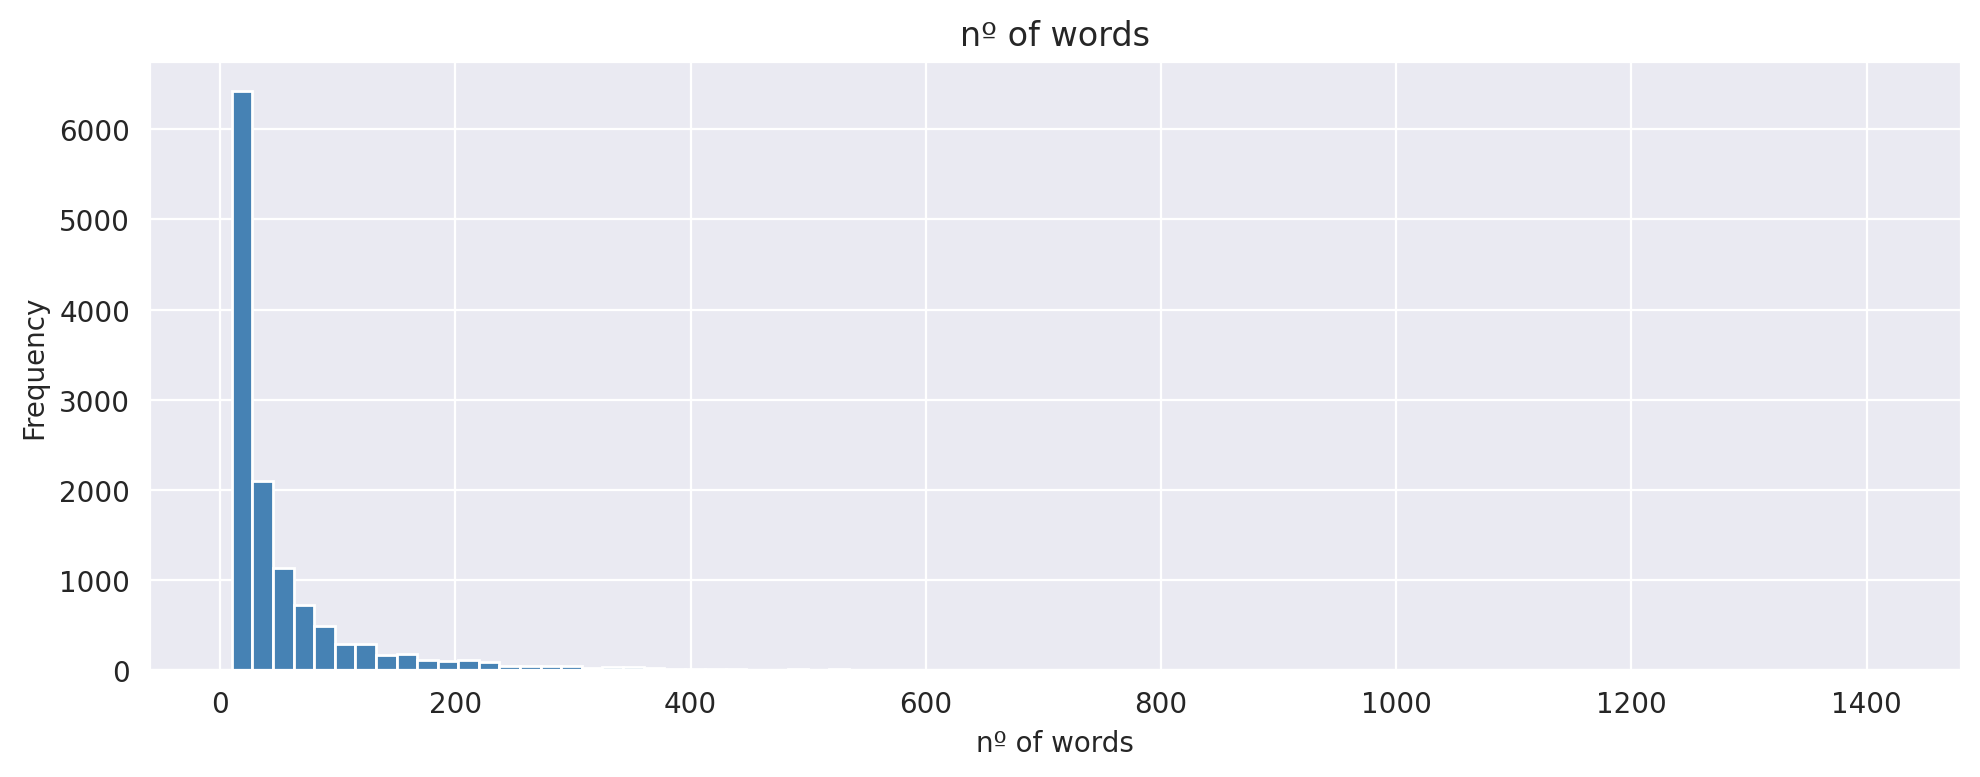

<Figure size 800x500 with 0 Axes>

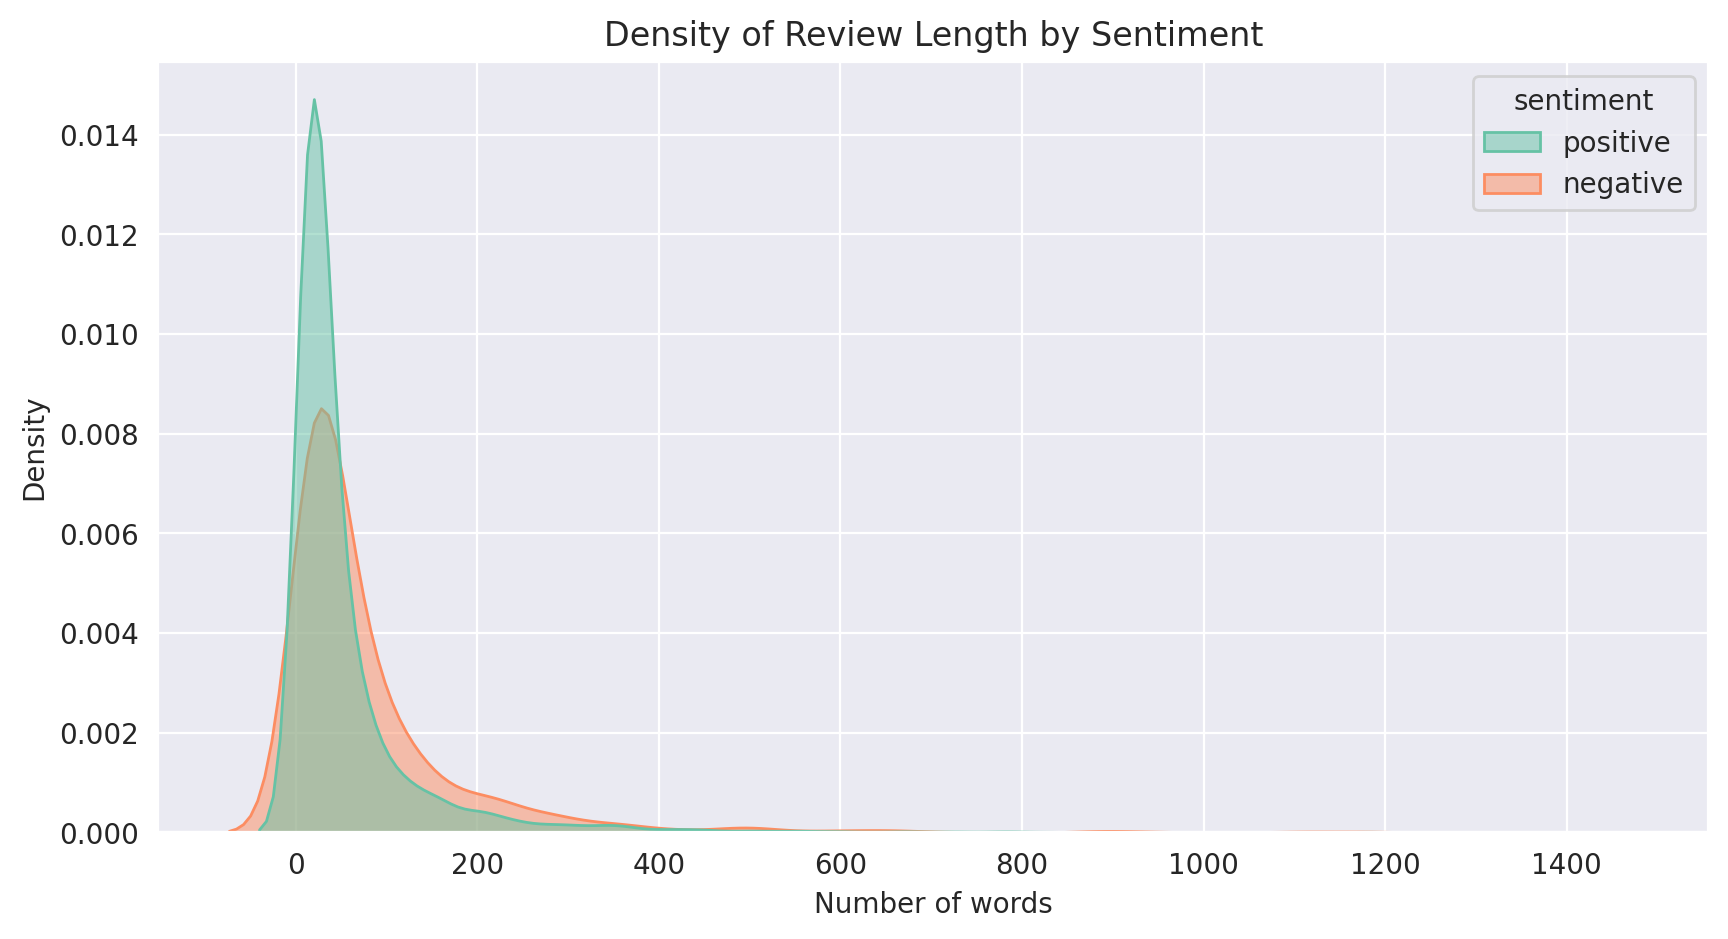

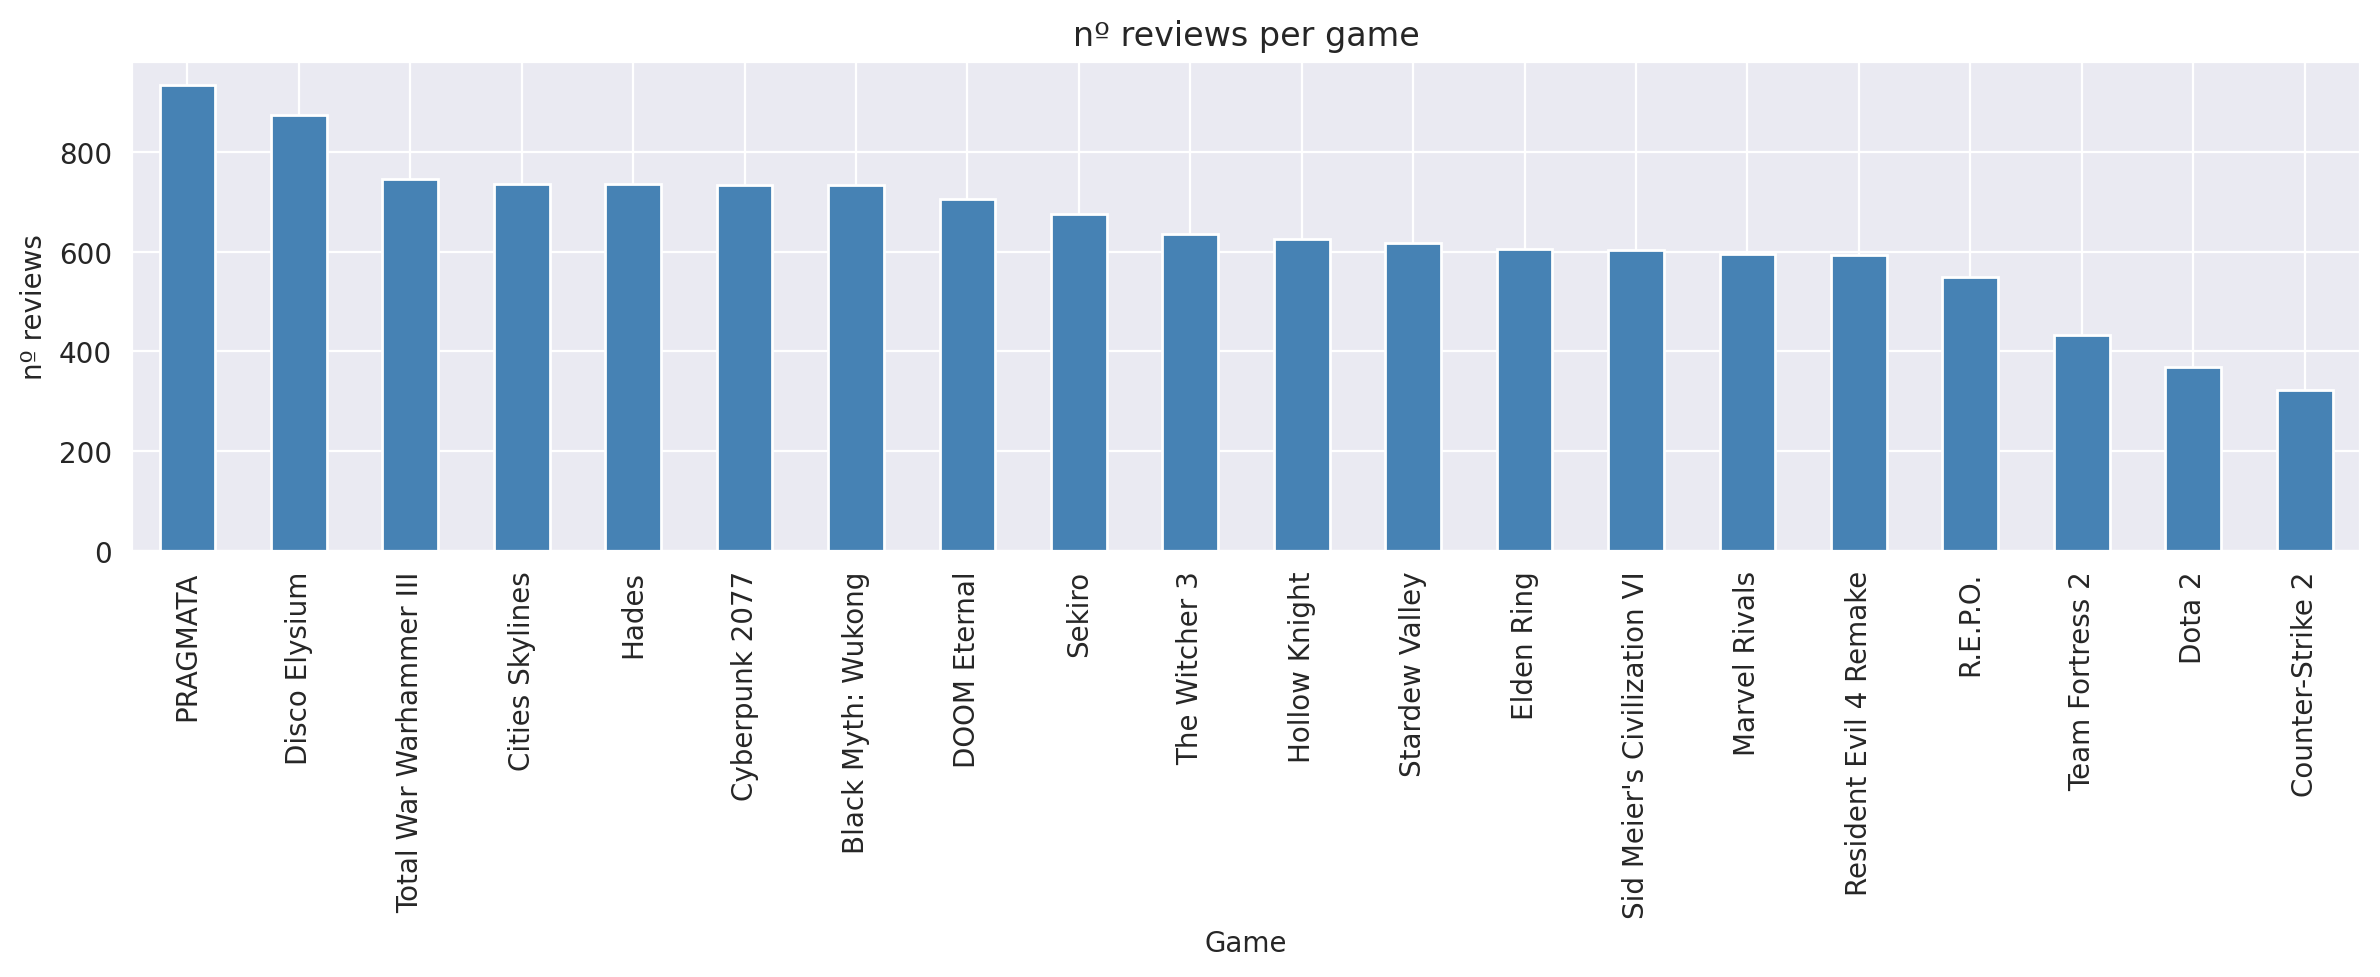


Language distribution of the reviews:
language
english    12826
Name: count, dtype: int64


In [ ]:
# Handle missing values: drop rows where review text or sentiment is NaN
df = df.dropna(subset=['review_text', 'sentiment'])

# Reviews length
df['review_len'] = df['review_text'].apply(lambda x: len(str(x).split()))

print(f"\nLength statistics (tokens) in reviews:")
print(df['review_len'].describe().round(1))

df['review_len'].plot(kind='hist', bins=80, figsize=(10, 4),
                      title='nº of words',
                      color='steelblue', edgecolor='white')
plt.xlabel('nº of words')
plt.tight_layout()
plt.show()

# Review length by Sentiment distribution
plt.figure(figsize=(8, 5))
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='review_len', hue='sentiment', common_norm=False, fill=True, palette='Set2', alpha=0.5)
plt.title('Density of Review Length by Sentiment')
plt.xlabel('Number of words')
plt.ylabel('Density')

# Videogames distribution
fig, ax = plt.subplots(figsize=(12, 5))
df['game_name'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('nº reviews per game')
ax.set_xlabel('Game'); ax.set_ylabel('nº reviews')
plt.tight_layout()
plt.show()

# Language distribution
print(f"\nLanguage distribution of the reviews:")
print(df['language'].value_counts().head(10))


After plotting a few graphs and table to analyse the content in our dataset, we reach the following initial conclusions:
- The dataset is composed around an 85% of positive reviews and a 15% of negative reviews, which is a fair representation of the real situation in the reviews of Steam. Initially this is a bad thing as the Machine Learning model will probably take the lazy path and the majority of predictions would be positive. Because of this, it is very important that during the model training we use class weights.
- Users prefer shorter reviews than really long ones, reviews over 200 words are really rare. Moreover, positive reviews are usually shorter than negative ones.
- The reviews are almost equally distributed for every game, this ensures we have diversity of genres and in consequence, diversity of users and types of fandoms that comment about those games.

### **Step 1: Pipeline implementation**

#### Text wrangling (pre-cleaning)

Raw text directly from the reviews is usually messy. The following function performs basic string cleaning before we pass the text to the NLP pipeline.
It removes HTML tags, deletes URLs, expands contractions, converts everything to lowercase, and eliminates emojis and non ASCII characters. This step ensures the NLP model doesn't get confused by useless characters.

In [ ]:
def wrangle_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    # 1. Eliminate HTML
    text = BeautifulSoup(text, "lxml").get_text()

    # 2. Eliminate URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # 3. Expand contractions
    text = contractions.fix(text)

    # 4. Eliminate emojis and not ASCII characters
    text = text.encode('ascii', 'ignore').decode('ascii')

    # 5. Transform to lower case
    text = text.lower()

    # 6. Eliminate strange characters
    text = re.sub(r'[^a-z0-9\s.,!?;:\'\"-]', ' ', text)

    # 7. Clean multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Try with a review
sample_raw = df['review_text'].iloc[0]
sample_wrangled = wrangle_text(sample_raw)

print("=== ORIGINAL ===")
print(sample_raw[:500])
print("\n=== TRAS WRANGLING ===")
print(sample_wrangled[:500])

=== ORIGINAL ===
the game is fun when you're not playing with failed abortions and "people" made from nuclear waste

=== TRAS WRANGLING ===
the game is fun when you are not playing with failed abortions and "people" made from nuclear waste


#### spaCy NLP Pipeline Setup
In the following code, we will configure the Natural Language Processing engine using `spaCy`:
- We know all the reviews are in English so it is not necessary to perform any language processing or detection
- Then, load the model (`en_core_web_md`), disable the parser and NER (Named Entity Recognition) components to speed up processing.
- Lastly add specific words that could appear in the videogames context (like "game", "steam", "play", "player") to our stopword list so they are ignored, as they appear in almost every review and don't add predictive value for sentiment analysis.

In [ ]:
nlp = spacy.load('en_core_web_md')
nlp.disable_pipe('parser')   # no dependencies tree
nlp.disable_pipe('ner')      # no NER

# Additional stopwords that could appear in context of videogames
extra_stopwords = {
    'game', 'games', 'play', 'played', 'playing', 'player', 'players',
    'steam', 'review', 'buy', 'get', 'like', 'really', 'good', 'bad',
    'just', 'also', 'even', 'much', 'many', 'lot', 'bit', 'little',
    'well', 'still', 'time', 'way', 'use', 'used', 'thing', 'things',
}

for word in extra_stopwords:
    nlp.vocab[word].is_stop = True

# POS we want to keep
VALID_POS = {'VERB', 'NOUN', 'ADJ', 'PROPN'}

print("Pipeline succesfully configures")
print(f"  Pipeline:  {nlp.pipe_names}")
print(f"  Additional stopwords: {len(extra_stopwords)}")

Pipeline succesfully configures
  Pipeline:  ['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer']
  Additional stopwords: 31


#### Preprocessing Function
The `preprocess_review` function puts everything together and in the case there are empty reviews, just ignore them. For every review, it does the following:
1. Applies the basic text wrangling.
2. Tokenizes the text and analyzes it.
3. Filters the tokens: removes stopwords, punctuation, numbers and non-english words. It only keeps words of the english alphabet that are Nouns, Verbs, Adjectives, or Proper Nouns.
4. Extracts the **lemma** (the root base form of the word)



In [ ]:
def preprocess_review(raw_text: str) -> list[str]:
    try:
        # If a review is NaN, ignore that review
        if pd.isna(raw_text):
            return []

        # 1. Wrangling
        clean = wrangle_text(str(raw_text))

        # If after the wrangling the text is empty, return empty list
        if not clean or not clean.strip():
            return []

        # We check the language of the cleaned string. If it's not English, we discard it.
        # We use the langdetect package for this function
        try:
            if detect(clean) != 'en':
                return []
        except:
            # If detection fails (e.g. string is too short/only numbers), return empty list
            return []

        # 2 & 3. spaCy, tokenization, Pos, lemmas and filtering
        doc = nlp(clean)
        tokens = []

        for token in doc:
            if not token.is_alpha:
                continue
            if token.pos_ not in VALID_POS:
                continue

            lemma = token.lemma_.lower()

            if nlp.vocab[lemma].is_stop:
                continue

            if len(lemma) < 2:
                continue

            tokens.append(lemma)

        return tokens

    except Exception as e:
        # If any steps collapse, return an empty list
        return []

#### Applying the Pipeline to the Corpus
Now we apply our `preprocess_review` function to the entire dataset. We use `progress_apply` from the `tqdm` library to display a progress bar, as heavy NLP processing can take a few minutes.
Then, we calculate how many clean tokens were extracted per review and plot the new length distribution.

In [ ]:
tqdm.pandas()

Processing reviews...


100%|██████████| 12826/12826 [02:39<00:00, 80.52it/s] 



Reviews processed: 12826
Reviews with 0 tokens (discarded): 461

Token statistics per review
count    12826.0
mean        20.6
std         39.7
min          0.0
25%          5.0
50%          9.0
75%         20.0
max        596.0
Name: n_tokens, dtype: float64


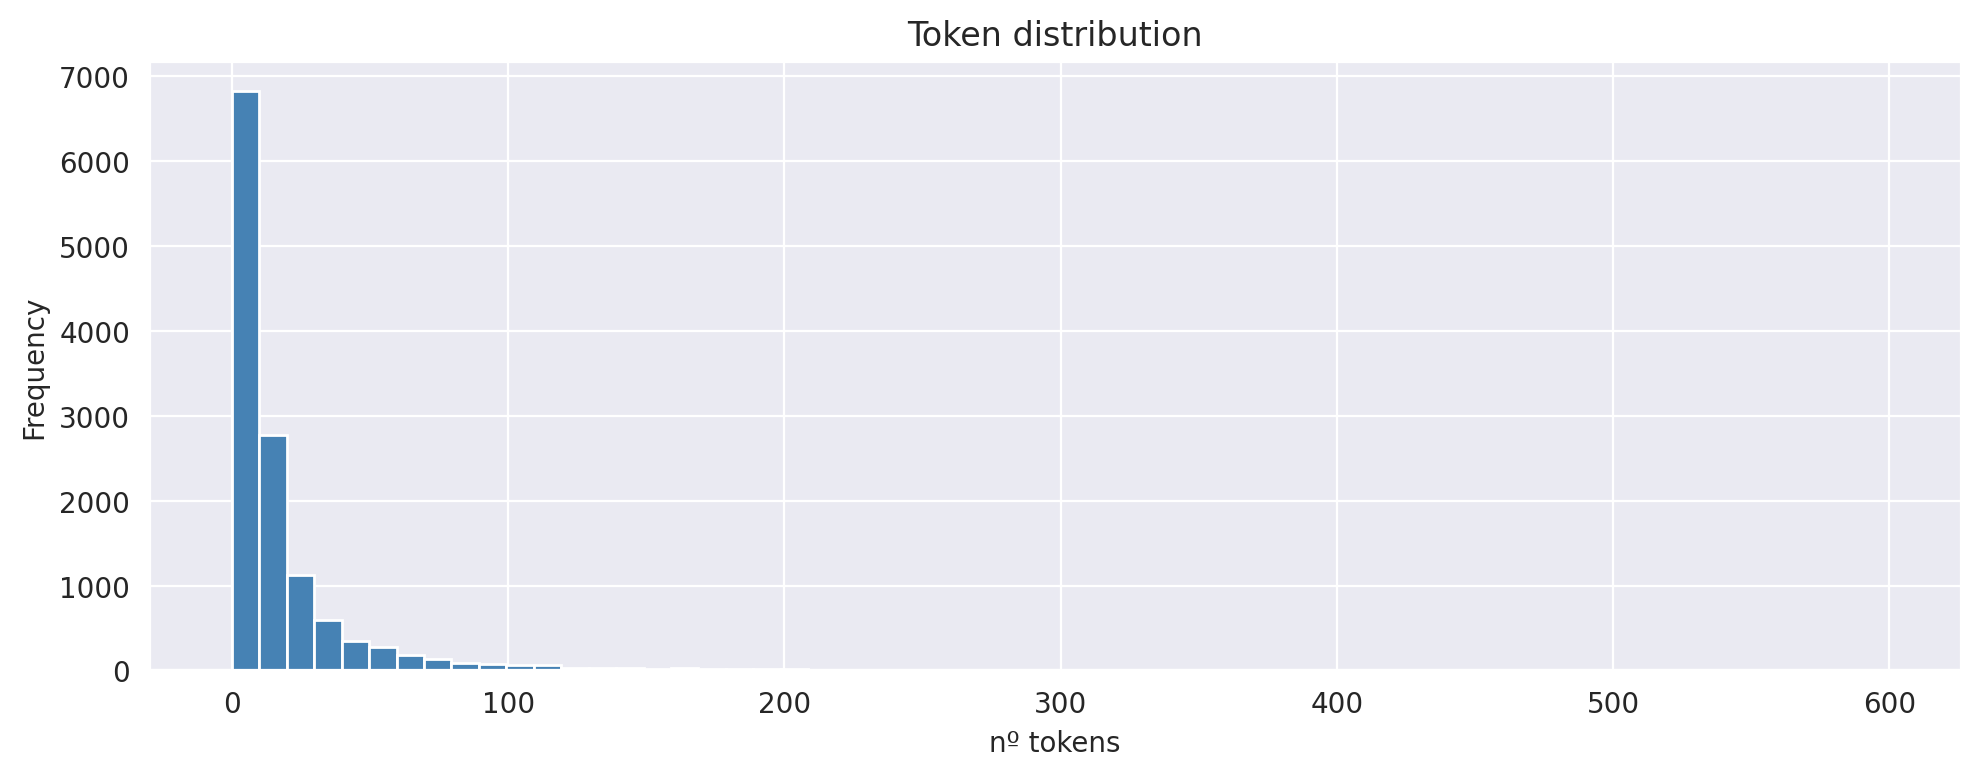


Example of processed review
Original: Valve, please fix the anti-cheat. There are cheaters in most games, but even the report system seems
Tokens (15): ['valve', 'fix', 'anti', 'cheat', 'cheater', 'report', 'system', 'useless', 'experience', 'cs', 'system', 'run', 'unoptimised', 'feature', 'predecessor']


In [ ]:
print("Processing reviews...")
df['tokens'] = df['review_text'].progress_apply(preprocess_review)

# Result statistics
df['n_tokens'] = df['tokens'].apply(len)

print(f"\nReviews processed: {len(df)}")
print(f"Reviews with 0 tokens (discarded): {(df['n_tokens'] == 0).sum()}")
print(f"\nToken statistics per review")
print(df['n_tokens'].describe().round(1))

# Token distributions per review
df['n_tokens'].plot(kind='hist', bins=60, figsize=(10, 4),
                    title='Token distribution',
                    color='steelblue', edgecolor='white')
plt.xlabel('nº tokens')
plt.tight_layout()
plt.show()

# Show the result
print("\nExample of processed review")
idx = 5
print(f"Original: {df['review_text'].iloc[idx][:100]}")
print(f"Tokens ({df['n_tokens'].iloc[idx]}): {df['tokens'].iloc[idx][:20]}")

After we processed all the reviews we see that 461 are discarded due to lack of tokens, this is a good sign as we have conserved almost all our data. The discarded reviews are probably the ones that only contained emojis, URLs or were full of stopwords.

We see that the reviews mean length now is lower than before, as we also see in the graph that now there are absolutely no reviews that contain over 200 words. In the statistics of the tokens it is noticeable how the mean is higher than the median, this shows an assymmetric distribution we confirm by looking at the graph, there are a lot short reviews against a minority of longer ones. It is also noticeable that the longest review contains 596 tokens, this just tell us we will need to build an NLP model that is able to process really long vectors.

Finally, in the example of a processed review, we see how the tokens are meaningful words (POS) and how stopwords do not appear and how lemmatization has worked successfully in plural words.

#### Save the new data

In [ ]:
# Filter reviews without tokens
df_clean = df[df['n_tokens'] > 0].reset_index(drop=True)
print(f"Reviews with tokens: {len(df_clean)} / {len(df)}")

# Save tokens in a .txt document (one review per line and tokens separated by one space)
with open('steam_reviews_lemmas.txt', 'w', encoding='utf-8') as f:
    for tokens in df_clean['tokens']:
        f.write(' '.join(tokens) + '\n')

# Save dataframe
df_clean.to_csv('steam_reviews_processed.csv', index=False)

print("Saved documents:")
print("  - steam_reviews_lemmas.txt")
print("  - steam_reviews_processed.csv")

Reviews with tokens: 12365 / 12826
Saved documents:
  - steam_reviews_lemmas.txt
  - steam_reviews_processed.csv


### **Step 2: Text vectorization**

In [ ]:
corpus = df_clean['tokens'].tolist() # list of lists of tokens

print(f"Reviews with tokens: {len(corpus)}")
print(f"Review example: {corpus[0][:15]}")

Reviews with tokens: 12365
Review example: ['fun', 'fail', 'abortion', 'people', 'nuclear', 'waste']


In [ ]:
# Build the dictionary
D = Dictionary(corpus)
print(f"Initial vocabulary: {len(D):,} terms")

# Filter extremes:
#   - min 5 documents
#   - max in 85 % of documents
D.filter_extremes(no_below=5, no_above=0.85)
print(f"Filtered vocabulary: {len(D):,} terms")

# Save the dictionary
D.save("steam_gensim_dict.bin")
D.save_as_text("steam_gensim_dict.txt")

# Top 20 most frequent terms in the dictionaries
token_doc_freq = sorted(D.dfs.items(), key=lambda x: x[1], reverse=True)
print("\nTop-20 terms:")
print([(D[tid], n) for tid, n in token_doc_freq[:20]])

Initial vocabulary: 15,971 terms
Filtered vocabulary: 4,376 terms

Top-20 terms:
[('fun', 2286), ('story', 1867), ('great', 1818), ('feel', 1636), ('love', 1556), ('gameplay', 1335), ('recommend', 1289), ('hour', 1252), ('want', 1228), ('combat', 1101), ('character', 1025), ('experience', 960), ('think', 956), ('try', 936), ('amazing', 926), ('world', 907), ('new', 890), ('run', 889), ('boss', 882), ('look', 821)]


#### Vocabulary Building and Dimensionality Reduction

To prepare our textual data for vectorization, we first constructed a vocabulary dictionary using Gensim. Initially, the corpus contained 15,971 unique terms. However, raw text data often contains a significant amount of noise in the form of misspellings, extremely rare words, or overly repetitive terms that offer little predictive value and  inflate the dimensionality of the feature space.

To address this and optimize our dataset, we applied a frequency-based filtering technique:
* **Minimum frequency (`no_below=5`):** We discarded any term appearing in fewer than 5 documents. This successfully eliminated typographical errors and highly niche words, preventing our future Machine Learning models from overfitting to rare occurrences.
* **Maximum frequency (`no_above=0.85`):** We removed terms that appeared in more than 85% of the reviews. These act as dynamic, domain-specific stopwords; since they are present almost everywhere across the corpus, they lack the discriminative power to differentiate between positive and negative sentiments.


This filtering process drastically reduced our vocabulary from 15,971 to 4,376 terms (a reduction of roughly 76%). This leaner vocabulary is highly optimized, significantly reducing computational cost while retaining the most meaningful semantic information.

Looking at the Top-20 most frequent terms extracted, we can draw three main conclusions about our dataset:
1. **Strong Sentiment Indicators:** Words like *"fun"*, *"great"*, *"love"*, *"recommend"*, and *"amazing"* heavily dominate the top rankings. This is a highly positive indicator for our classification task, as these are strong polar words that models can easily use to identify positive reviews.
2. **High Domain Relevance:** Terms such as *"story"*, *"gameplay"*, *"combat"*, *"character"*, *"world"*, and *"boss"* confirm that our preprocessing successfully preserved the core topics of the video game industry. The models will use these nouns as context to anchor the sentiment expressions.
3. **User Experience Focus:** Words like *"feel"*, *"hour"*, *"experience"*, and *"run"* reflect the typical Steam review structure, where players often discuss how the game feels to play and the amount of time they have invested in it.

#### 1. Classical approaches: BoW and TF-IDF

In [ ]:
# BoW representation
reviews_bow = [D.doc2bow(doc) for doc in corpus]

# TF-IDF model
tfidf = TfidfModel(reviews_bow, dictionary=D)

# Apply transformation to all the corpus
reviews_tfidf = tfidf[reviews_bow]

# Example
n = 0
print("Original review")
print(corpus[n][:20])
print(f"\nBoW top 20 by frequences")
bow_sorted = sorted(reviews_bow[n], key=lambda x: x[1], reverse=True)
print([(D[tid], cnt) for tid, cnt in bow_sorted[:10]])
print(f"\nTF-IDF top 10 by weights")
tfidf_sorted = sorted(reviews_tfidf[n], key=lambda x: x[1], reverse=True)
print([(D[tid], round(w, 4)) for tid, w in tfidf_sorted[:10]])

Original review
['fun', 'fail', 'abortion', 'people', 'nuclear', 'waste']

BoW top 20 by frequences
[('fail', 1), ('fun', 1), ('nuclear', 1), ('people', 1), ('waste', 1)]

TF-IDF top 10 by weights
[('nuclear', 0.7169), ('fail', 0.4439), ('waste', 0.4307), ('people', 0.2762), ('fun', 0.1648)]




The printed example perfectly illustrates the mechanics of our vectorization pipeline and the advantages of TF-IDF over a simple BoW approach:

1. **Vocabulary Filtering in Action:** The original token *"abortion"* was dropped in the BoW representation. This confirms that our `no_below=5` threshold successfully filters out rare words that act as noise.
2. **TF-IDF Weighting:** In the BoW model, all remaining terms have an equal frequency of 1. However, the TF-IDF model assigns completely different importance weights. The word *"fun"*, which we previously identified as the most frequent word in our entire corpus, receives the lowest weight because it lacks discriminative power. Conversely, the highly specific word *"nuclear"* receives the highest weight, as the model correctly identifies it as the defining feature of this specific document.

#### Conversion to matrices NumPy/SciPy for sklearn

In [ ]:
# Transform to matrixes
n_tokens = len(D)
n_docs   = len(reviews_bow)

# BoW  — sparse (more efficient with largest vocabulary)
X_bow_sparse   = corpus2csc(reviews_bow,   num_terms=n_tokens, num_docs=n_docs).T
# TF-IDF — sparse
X_tfidf_sparse = corpus2csc(reviews_tfidf, num_terms=n_tokens, num_docs=n_docs).T

print(f"BoW dimensions: {X_bow_sparse.shape}")
print(f"TF-IDF dimensions: {X_tfidf_sparse.shape}")

# Binary etiquettes
le = LabelEncoder()
Y = le.fit_transform(df_clean['sentiment'])
print(f"\nClasses distribution: {dict(zip(le.classes_, np.bincount(Y)))}")

BoW dimensions: (12365, 4376)
TF-IDF dimensions: (12365, 4376)

Classes distribution: {'negative': 1928, 'positive': 10437}


#### Analysis of vectors

Final vocabulary: 4376 terms

20 most frequent:
     token  ndocs
       fun   2286
     story   1867
     great   1818
      feel   1636
      love   1556
  gameplay   1335
 recommend   1289
      hour   1252
      want   1228
    combat   1101
 character   1025
experience    960
     think    956
       try    936
   amazing    926
     world    907
       new    890
       run    889
      boss    882
      look    821

20 less frequent:
       token  ndocs
   cigarette      5
   surrender      5
     musical      5
unreasonable      5
   exquisite      5
      banana      5
  ammunition      5
      spongy      5
    gimmicky      5
  powercreep      5
         unc      5
       goood      5
    resemble      5
      maniac      5
       fluff      5
     consist      5
        norm      5
   dismantle      5
      module      5
       widow      5


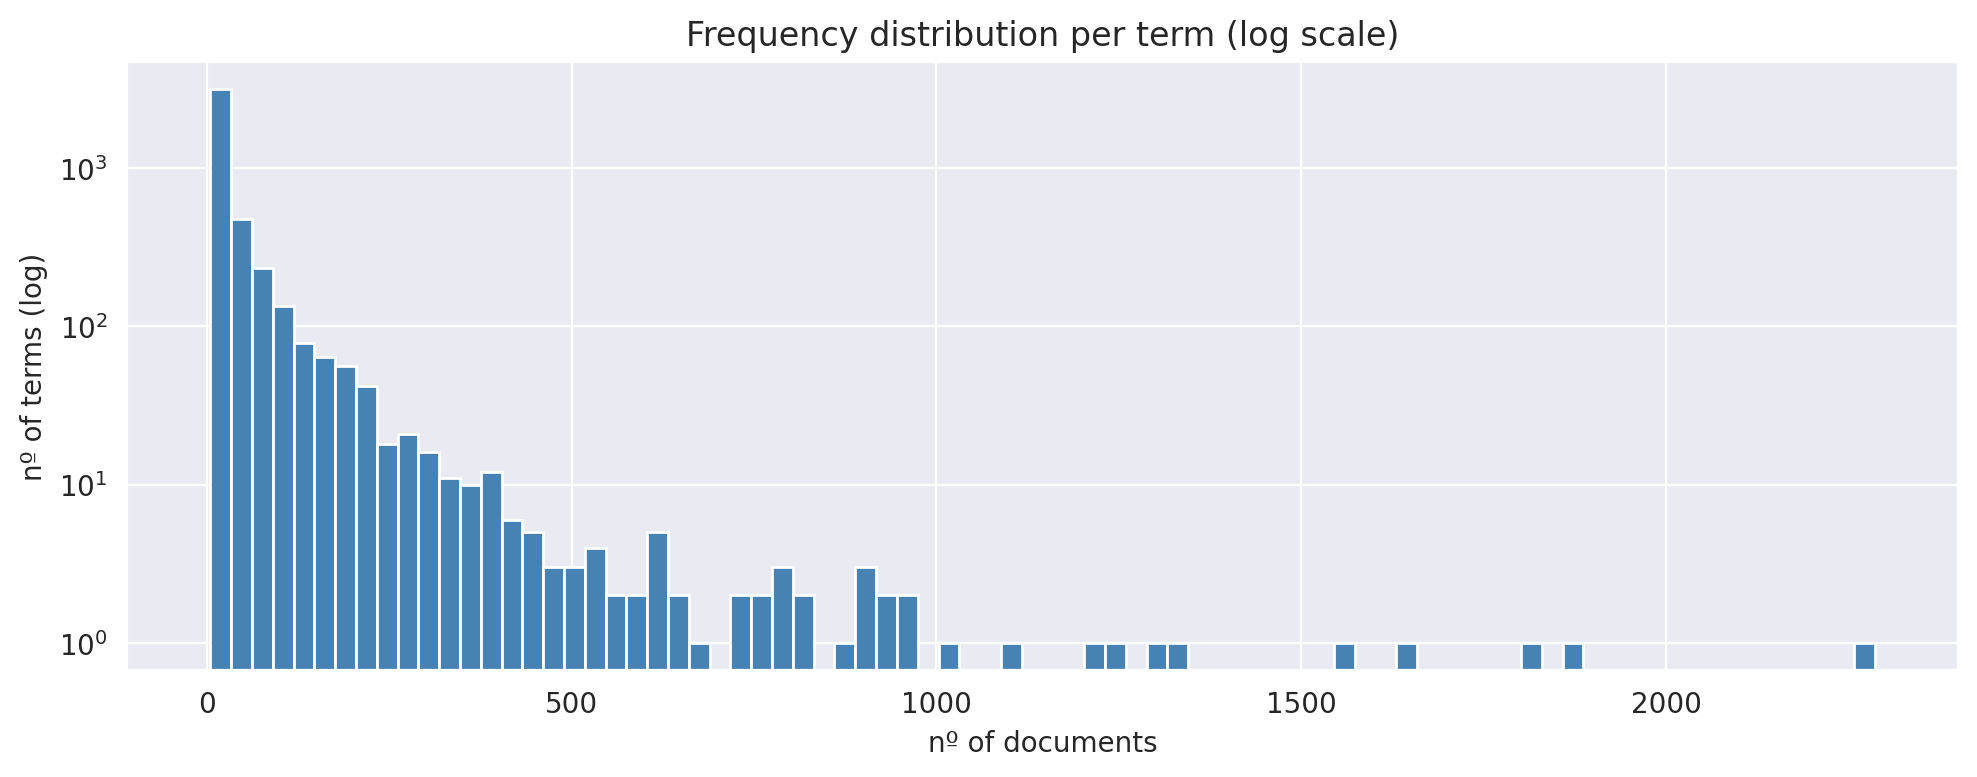

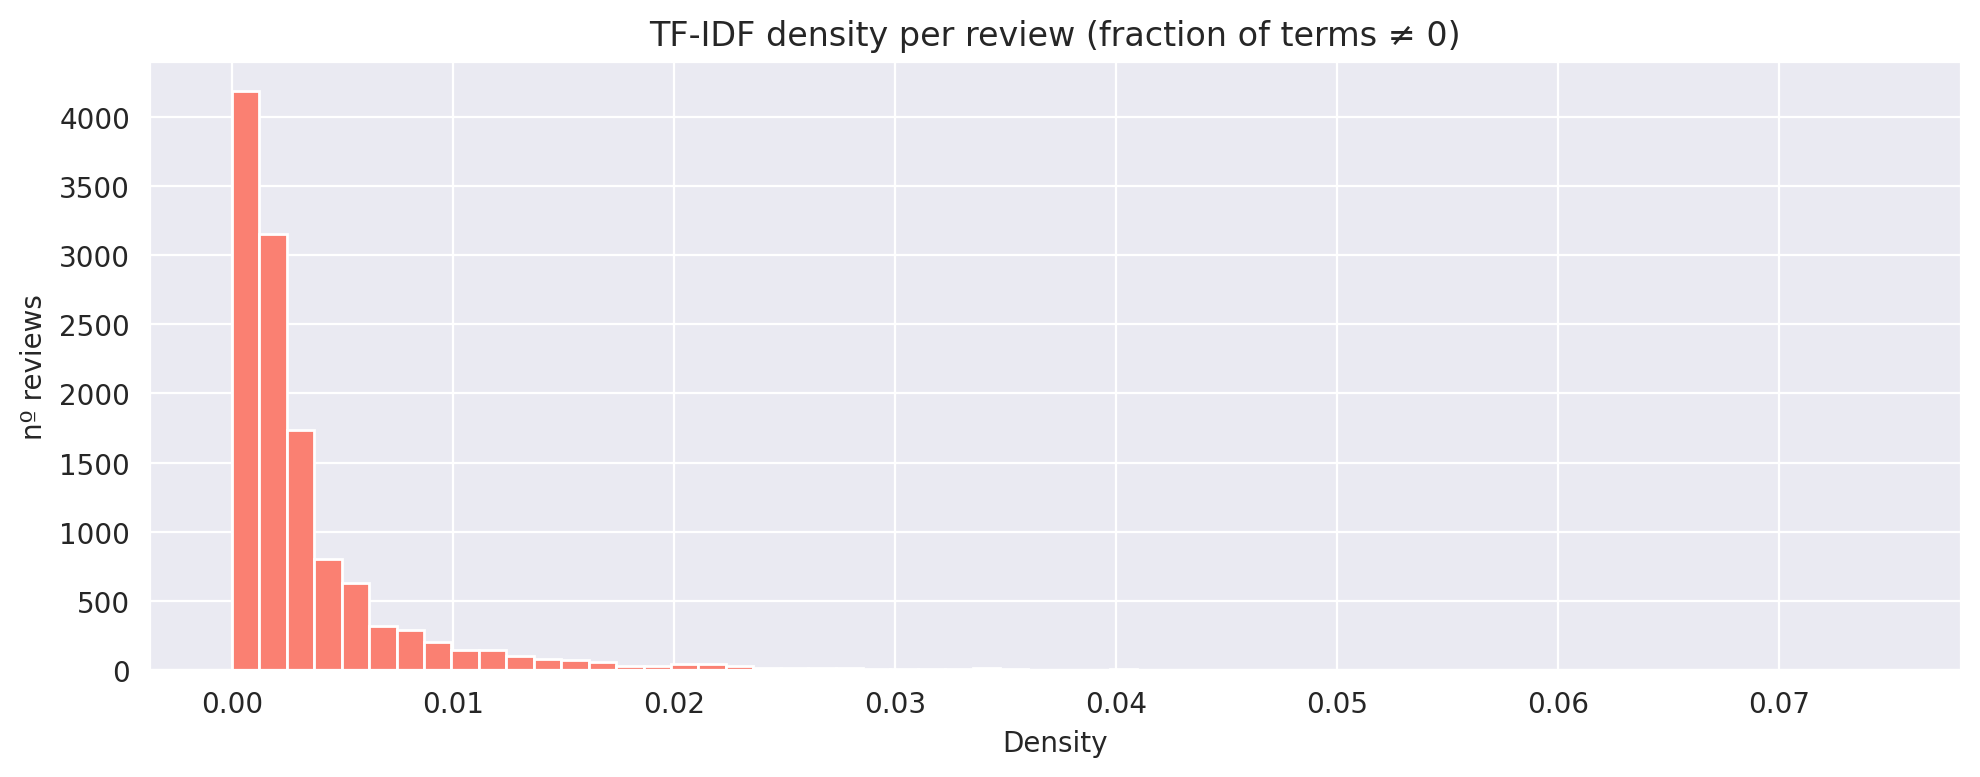


Mean density of TF-IDF vector: 0.38 %


In [ ]:
# Frequency of documents per term
df_vocab = pd.DataFrame(
    [(D[tid], n) for tid, n in D.dfs.items()],
    columns=['token', 'ndocs']
).sort_values('ndocs', ascending=False).reset_index(drop=True)

print(f"Final vocabulary: {len(df_vocab)} terms")
print("\n20 most frequent:")
print(df_vocab.head(20).to_string(index=False))
print("\n20 less frequent:")
print(df_vocab.tail(20).to_string(index=False))

# Frequency histogram
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_vocab['ndocs'], bins=80, color='steelblue', edgecolor='white', log=True)
ax.set_title('Frequency distribution per term (log scale)')
ax.set_xlabel('nº of documents')
ax.set_ylabel('nº of terms (log)')
plt.tight_layout()
plt.show()

# Density distribution of TF-IDF vectors
# (wich fraction of terms of the vocabulary has wight > 0 for review)
densidad = [len(v) / n_tokens for v in reviews_tfidf]
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(densidad, bins=60, color='salmon', edgecolor='white')
ax.set_title('TF-IDF density per review (fraction of terms ≠ 0)')
ax.set_xlabel('Density')
ax.set_ylabel('nº reviews')
plt.tight_layout()
plt.show()

print(f"\nMean density of TF-IDF vector: {np.mean(densidad)*100:.2f} %")


The final vocabulary consists of 4,376 highly relevant terms. The frequency distribution demonstrates that our boundaries successfully retained domain-specific keywords while dropping noisy extremes.

Crucially, the density analysis reveals that our TF-IDF matrix has a mean density of just **0.38%**. This means over 99.6% of the matrix consists of zeros, mathematically validating our decision to use Compressed Sparse Column matrices. This approach drastically optimizes memory consumption and accelerates the training time for the upcoming Machine Learning algorithms.

#### 2. Embedding-based approaches: Word2Vec

For this step, we decided to train our own **Word2Vec** model from scratch instead of using GloVe or FastText.

Steam reviews are full of gamer slang. Words like *"boss"*, *"run"*, *"bug"*, or *"drop"* mean very different things in gaming compared to everyday English. If we used a pre-trained GloVe model (which learns from standard texts like Wikipedia), it wouldn't understand this slang. By training our own Word2Vec, the model learns exactly how Steam users talk. FastText is an amazing tool for handling text with a lot of typos because it breaks words into smaller chunks. However, since we already did a very strict cleaning step and removed words that appear less than 5 times, our text barely has any typos left. Because our data is already so clean, Word2Vec is faster, simpler, and perfectly suited for our needs.

In [ ]:
print("Training Word2Vec model...")
cores = multiprocessing.cpu_count()

model_w2v = Word2Vec(
    sentences=corpus,
    vector_size=200,    # 200 dimensions (better semantic precision)
    window=5,
    min_count=5,        # Kept at 5 since we already filtered the vocabulary
    sg=1,               # Skip-gram approach
    seed=42,            # Seed for reproducibility
    workers=cores
)

# Efficient Memory Management (KeyedVectors)
# Save only the vectors (much lighter than the full model)
word_vectors = model_w2v.wv
word_vectors.save("steam_reviews.wordvectors")

# Free up RAM by deleting the full model
del model_w2v
gc.collect()

# Load the vectors back in read-only mode (lightning-fast)
wv = KeyedVectors.load("steam_reviews.wordvectors", mmap='r')

print(f"Vocabulary saved. Size: {len(wv)} words.")

Training Word2Vec model...
Vocabulary saved. Size: 4550 words.


Before visualizing the entire vector space, we perform a quick sanity check. By querying the model for the most similar terms to specific gaming keywords like *"bug"* or *"boss"*, we can verify if the embeddings have successfully captured the domain's jargon.

In [ ]:
# Similarity Tests (Sanity Check)
print("\n--- Words similar to 'BUG' ---")
print(wv.most_similar(positive="bug", topn=5))

print("\n--- Words similar to 'BOSS' ---")
print(wv.most_similar(positive="boss", topn=5))


--- Words similar to 'BUG' ---
[('minor', 0.9375317096710205), ('author', 0.8871837854385376), ('ark', 0.8672285676002502), ('terrarium', 0.8522371053695679), ('hear', 0.8390699028968811)]

--- Words similar to 'BOSS' ---
[('mini', 0.7424231767654419), ('defeat', 0.7392494082450867), ('chapter', 0.7391707897186279), ('fight', 0.7332324385643005), ('tough', 0.7265638709068298)]


To better understand the relationships learned by our model, we apply **t-SNE** (t-distributed Stochastic Neighbor Embedding). This algorithm reduces our 200-dimensional vectors into a 2D space, attempting to preserve the original semantic distances. We will plot the 300 most frequent words to observe how similar concepts cluster together.

Generating t-SNE plot...


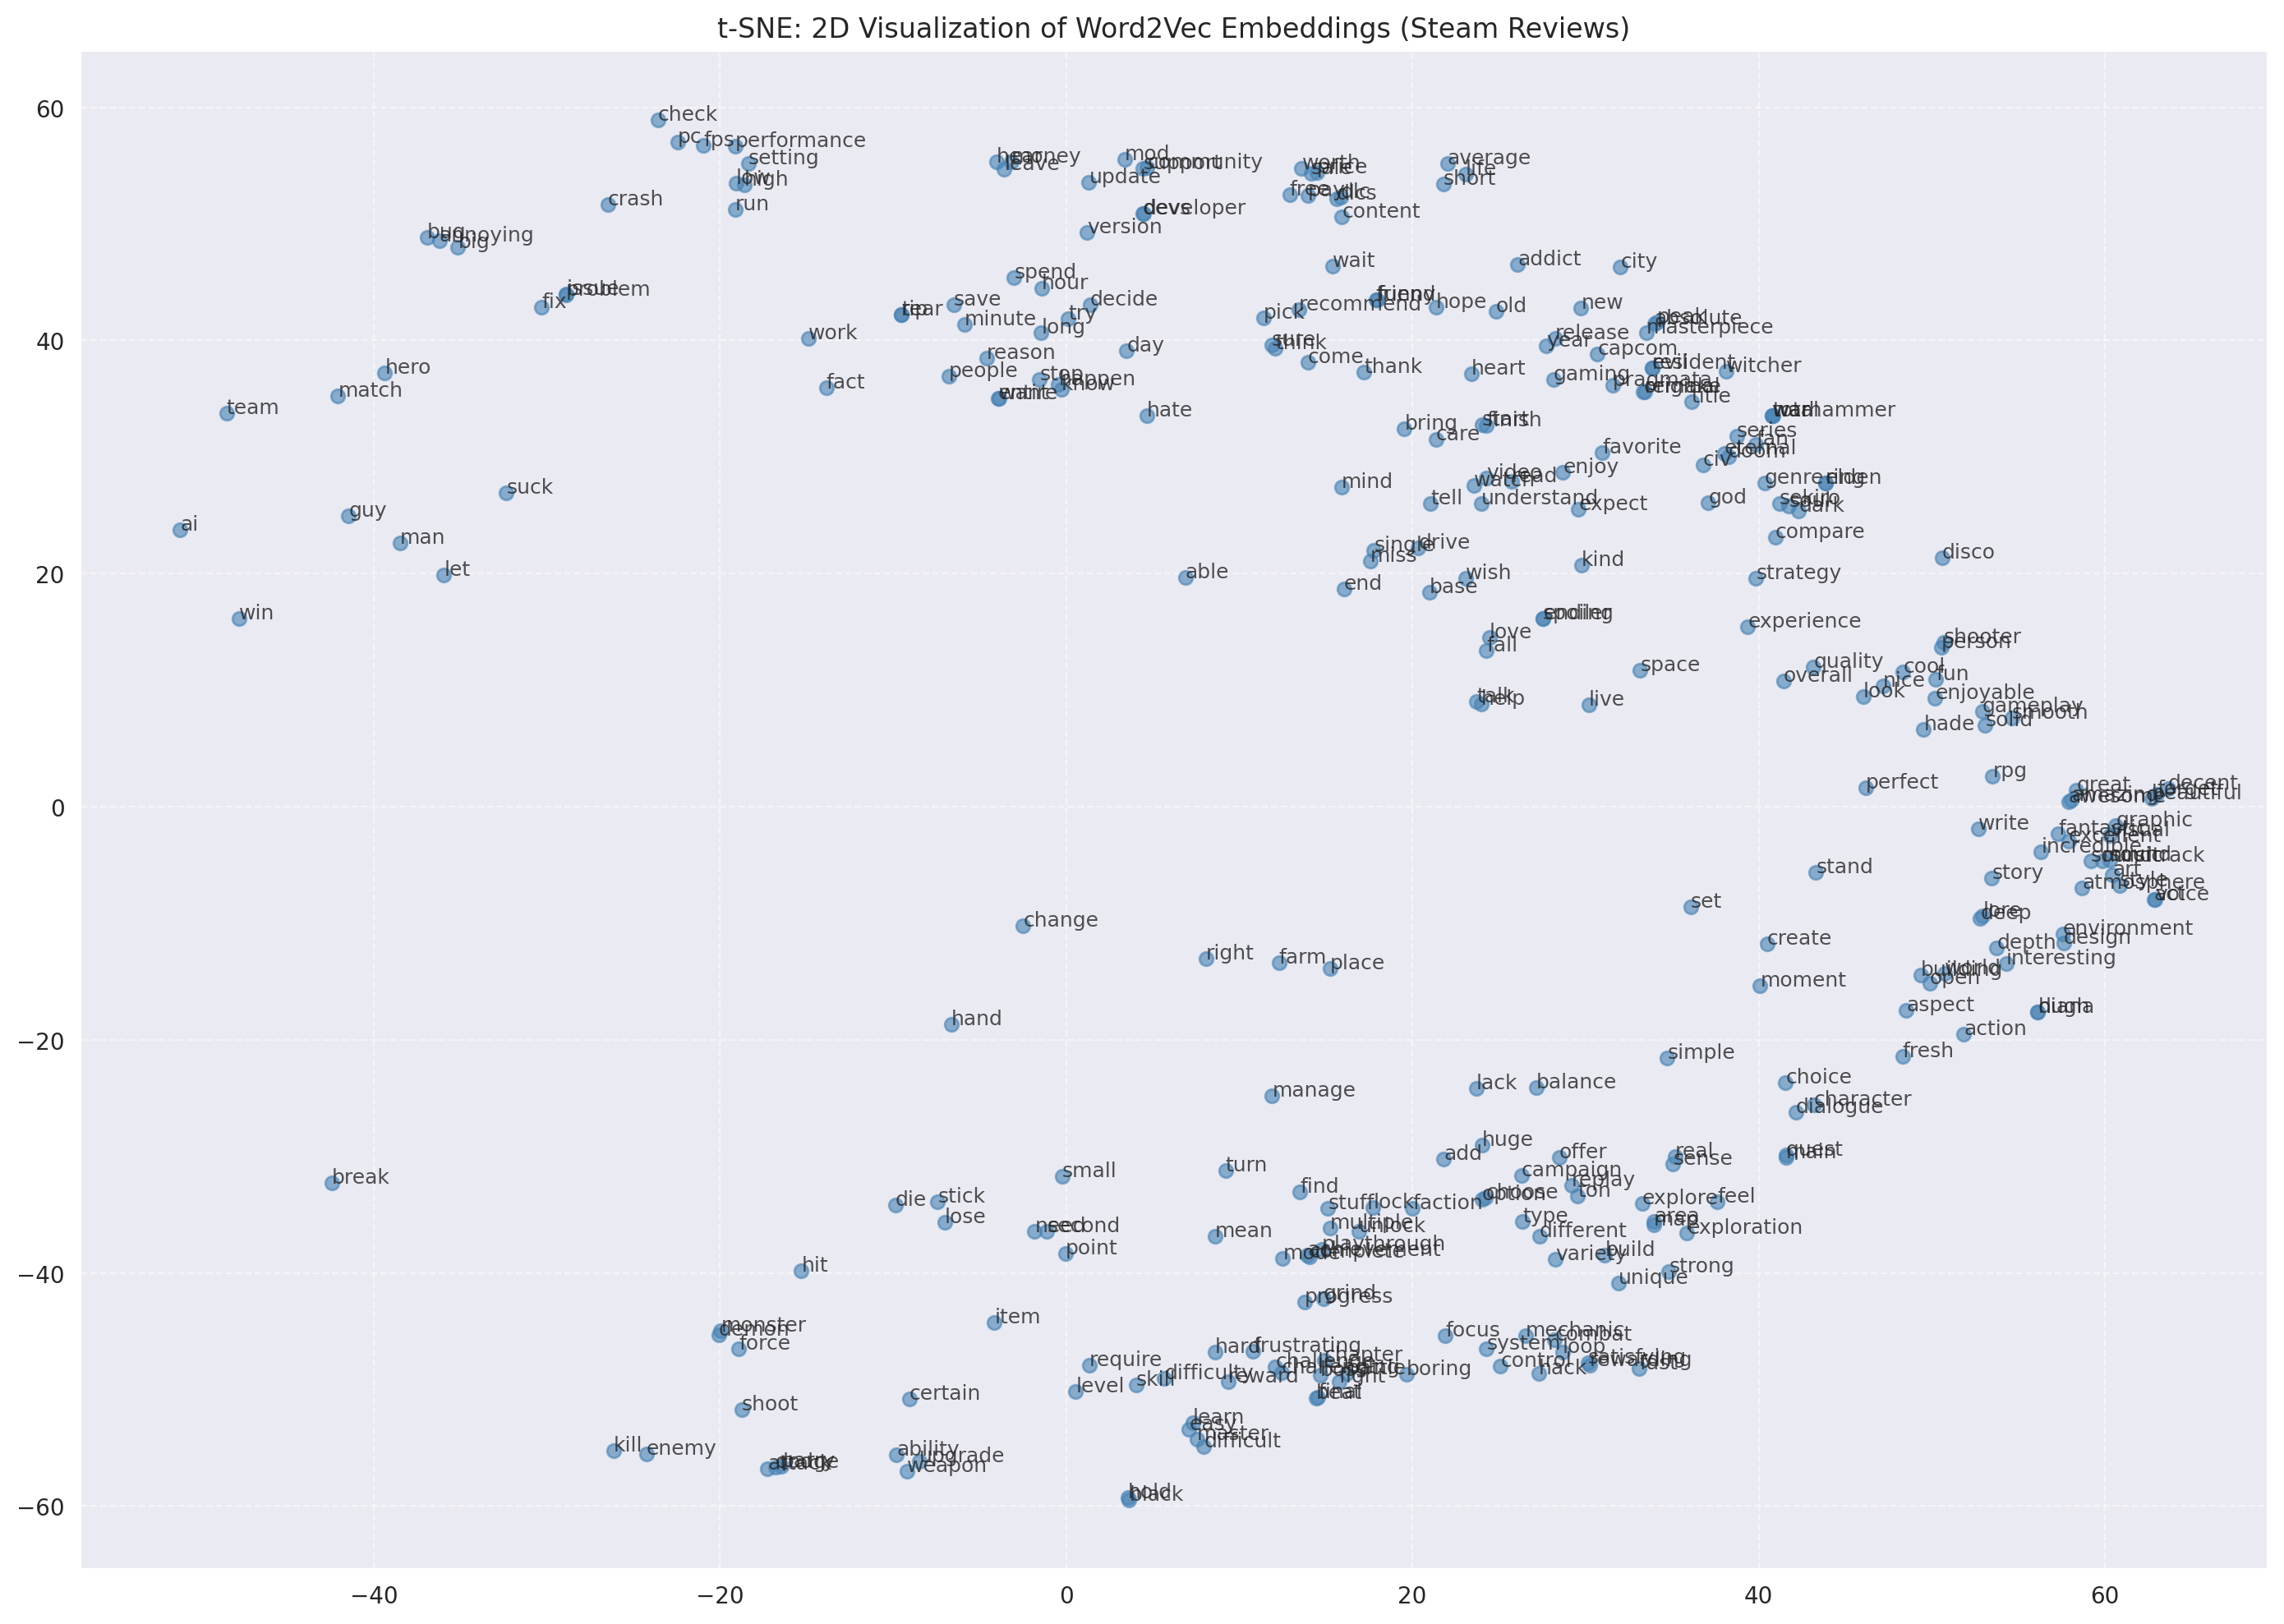

6531

In [ ]:
print("Generating t-SNE plot...")

tsne = TSNE(init='random', random_state=42)
embed_tsne = tsne.fit_transform(wv.vectors)

# Plot only the top 300 most frequent words to avoid visual clutter
fig, ax = plt.subplots(figsize=(14, 10))
for idx, word in enumerate(list(wv.key_to_index.keys())[:300]):
    plt.scatter(*embed_tsne[idx, :], color='steelblue', alpha=0.6)
    plt.annotate(word, (embed_tsne[idx, 0], embed_tsne[idx, 1]), alpha=0.8, fontsize=9)

plt.title("t-SNE: 2D Visualization of Word2Vec Embeddings (Steam Reviews)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Clean plotting variables from memory
del embed_tsne
gc.collect()


The model successfully captured the gaming domain, forming highly coherent semantic clusters:
* **Technical Issues:** Words like *'bug'*, *'annoying'*, *'crash'*, *'issue'*, *'fps'*, and *'performance'* are clustered tightly together (top-left). This confirms that the model understands the functional vocabulary of technical problems and PC optimization.
* **Franchises:** Interestingly, the model clearly groups major gaming franchises and concepts together (e.g., *'masterpiece'*, *'witcher'*, *'cyberpunk'*, *'capcom'*, *'resident_evil'*, *'sekiro'*, *'elden_ring'*). This demonstrates that our Word2Vec has learned from real user experiences within the Steam ecosystem, linking these specific heavy-hitting titles into a distinct semantic space.
* **Combat Vocabulary:** The grouping of *'enemy'*, *'kill'*, *'shoot'*, *'weapon'*, and *'monster'* (bottom-left) further proves the model's ability to isolate specific gameplay mechanics.


The t-SNE plot provides a global view of the learned vocabulary:
* **Clustering**: We can observe clear semantic islands. Words with positive sentiment tend to group together, while technical descriptors and action verbs form separate clusters.
* **Dense vs. Sparse Representation**: Unlike the TF-IDF approach, where words are independent dimensions, Word2Vec has successfully compressed the relationships into a continuous vector space. This allows the model to "understand" that two reviews might be talking about the same concept even if they use different synonyms.

In conclusion, this **Embedding-based approach** provides a much richer context than frequency-based methods, as it captures the "gamer" language behind the words rather than just their occurrence.

#### 3. Topic modeling-based representation: Theme extraction and vector representation using the LDA algorithm

In this section, we explore a different approach to text representation based on **Topic Modeling**. Specifically, we use **Latent Dirichlet Allocation (LDA)**, a probabilistic model that assumes each document (review) is a mixture of a small number of latent topics, and that each word's presence is attributable to one of the document's topics.

LDA helps us understand the thematic structure of our dataset. We can represent each review as a vector of topic probabilities. This means each document will be defined by how much it belongs to each identified theme, providing a high-level structural feature set for our future classification tasks.

First of all, we perform **N-gram detection** to identify common multi-word phrases in our corpus. This ensures that terms consisting of two or more words are treated as a single semantic unit, rather than being split into isolated tokens. Doing this significantly improves the quality and interpretability of the topics discovered by the LDA model. We will use `Gensim`'s `Phrases` module to automatically find and replace these word combinations based on their statistical co-occurrence.

In [ ]:
print("Detecting N-grams in the corpus...")

# 1. Initialize the N-gram detector
# min_count: minimum number of occurrences required for a token pair
# threshold: score threshold for forming the phrases (higher = more selective)
phrases = Phrases(corpus, min_count=5, threshold=20)

# 2. Export the phrases into a Phraser for better efficiency and memory usage
ngram_model = Phraser(phrases)

# 3. Apply the chosen N-gram model to the corpus
corpus_with_ngrams = [ngram_model[doc] for doc in corpus]

# --- VERIFICATION ---
ngram_counts = Counter()
for doc in corpus_with_ngrams:
    for token in doc:
        # N-grams are joined by an underscore '_'
        if '_' in token:
            ngram_counts[token] += 1

print(f"Total unique N-grams detected: {len(ngram_counts)}")
print("-" * 40)
print("Top 20 most frequent N-grams in the Steam reviews:")

# Print the top 20 N-grams to verify they make sense in a gaming context
for ngram, count in ngram_counts.most_common(20):
    print(f" - {ngram}: {count} occurrences")

Detecting N-grams in the corpus...
Total unique N-grams detected: 656
----------------------------------------
Top 20 most frequent N-grams in the Steam reviews:
 - elden_ring: 290 occurrences
 - boss_fight: 274 occurrences
 - total_war: 246 occurrences
 - open_world: 223 occurrences
 - resident_evil: 219 occurrences
 - disco_elysium: 164 occurrences
 - voice_act: 162 occurrences
 - dark_soul: 154 occurrences
 - doom_eternal: 148 occurrences
 - addict_gambling: 145 occurrences
 - rip_tear: 140 occurrences
 - gameplay_loop: 129 occurrences
 - combat_system: 128 occurrences
 - hollow_knight: 128 occurrences
 - level_design: 126 occurrences
 - farm_farm: 112 occurrences
 - art_style: 108 occurrences
 - city_skyline: 98 occurrences
 - black_myth: 92 occurrences
 - worth_price: 91 occurrences


The N-gram detection was highly successful, identifying crucial domain-specific terminology within our corpus. Looking at the most frequent pairs, the model correctly grouped:
* **Specific game titles:** *elden_ring, resident_evil, disco_elysium, dark_soul*.
* **Gaming mechanics and features:** *boss_fight, open_world, level_design, combat_system*.

By treating these terms as single semantic units rather than isolated words, our LDA model will not dilute their meaning. It will accurately recognize them as distinct gaming concepts, which will lead to much more coherent and easily interpretable topics.



After this we proceed to train the LDA model. We will use the `tomotopy` library, which provides a highly optimized, multithreaded implementation of LDA.

We initialize the model with `k=10` topics as a starting point. We also apply internal filtering during the model initialization:
* `min_df=5`: Ignores words that appear in fewer than 5 reviews (removes rare outliers).
* `rm_top=20`: Removes the 20 most frequent words across the corpus. This is a very useful parameter in `tomotopy` to eliminate dataset-specific words (like "game" or "play") that might have slipped through our initial stopword removal, allowing the true semantic topics to emerge clearly.

In [ ]:
print("Initializing LDA Model...")
num_topics = 10

# 1. Initialize the LDA model
# We use min_df to filter extremely rare words, and rm_top to filter the most common ones
lda_model = tp.LDAModel(k=num_topics, min_df=5, rm_top=20, seed=42)

# 2. Add our documents (the corpus with n-grams) to the model
for doc in corpus_with_ngrams:
    lda_model.add_doc(doc)

print(f"Adding documents completed. Total documents: {len(lda_model.docs)}")
print("Training LDA Model...")

# 3. Train the model
# We set iter=1000 iterations for a good convergence.
lda_model.train(1000)

print("Training completed successfully!")
print("-" * 60)
print(f"Discovered {lda_model.k} latent topics. Top 10 words per topic:")
print("-" * 60)

# 4. Extract and print the top words for each topic to interpret them
for k in range(lda_model.k):
    # get_topic_words returns a list of (word, probability) tuples
    top_words = lda_model.get_topic_words(k, top_n=10)
    words = [word for word, prob in top_words]
    print(f"Topic #{k}: {', '.join(words)}")

Initializing LDA Model...
Adding documents completed. Total documents: 12365
Training LDA Model...


/usr/local/lib/python3.12/dist-packages/tomotopy/models.py:637: RuntimeWarning: The training result may differ even with fixed seed if `workers` != 1.
  return self._train(iterations, workers, parallel, freeze_topics, callback_interval, callback)


Training completed successfully!
------------------------------------------------------------
Discovered 10 latent topics. Top 10 words per topic:
------------------------------------------------------------
Topic #0: graphic, music, capcom, unique, beautiful, enjoy, mechanic, different, interesting, hade
Topic #1: soul, hard, elden_ring, beat, sekiro, fight, learn, challenge, boss_fight, chapter
Topic #2: faction, total_war, warhammer, battle, unit, campaign, army, ai, strategy, need
Topic #3: enemy, doom, weapon, fight, map, level, design, point, mechanic, need
Topic #4: original, remake, resident_evil, leon, rip_tear, ashley, og, horror, knife, ada
Topic #5: people, spoiler, choice, dialogue, disco_elysium, work, find, read, point, life
Topic #6: quest, witcher, cyberpunk, main, dlc, open_world, rpg, ending, choice, mission
Topic #7: dlc, mod, city, pc, year, need, work, civ, worth, fix
Topic #8: friend, team, match, people, hero, rank, community, dota, update, toxic
Topic #9: know,

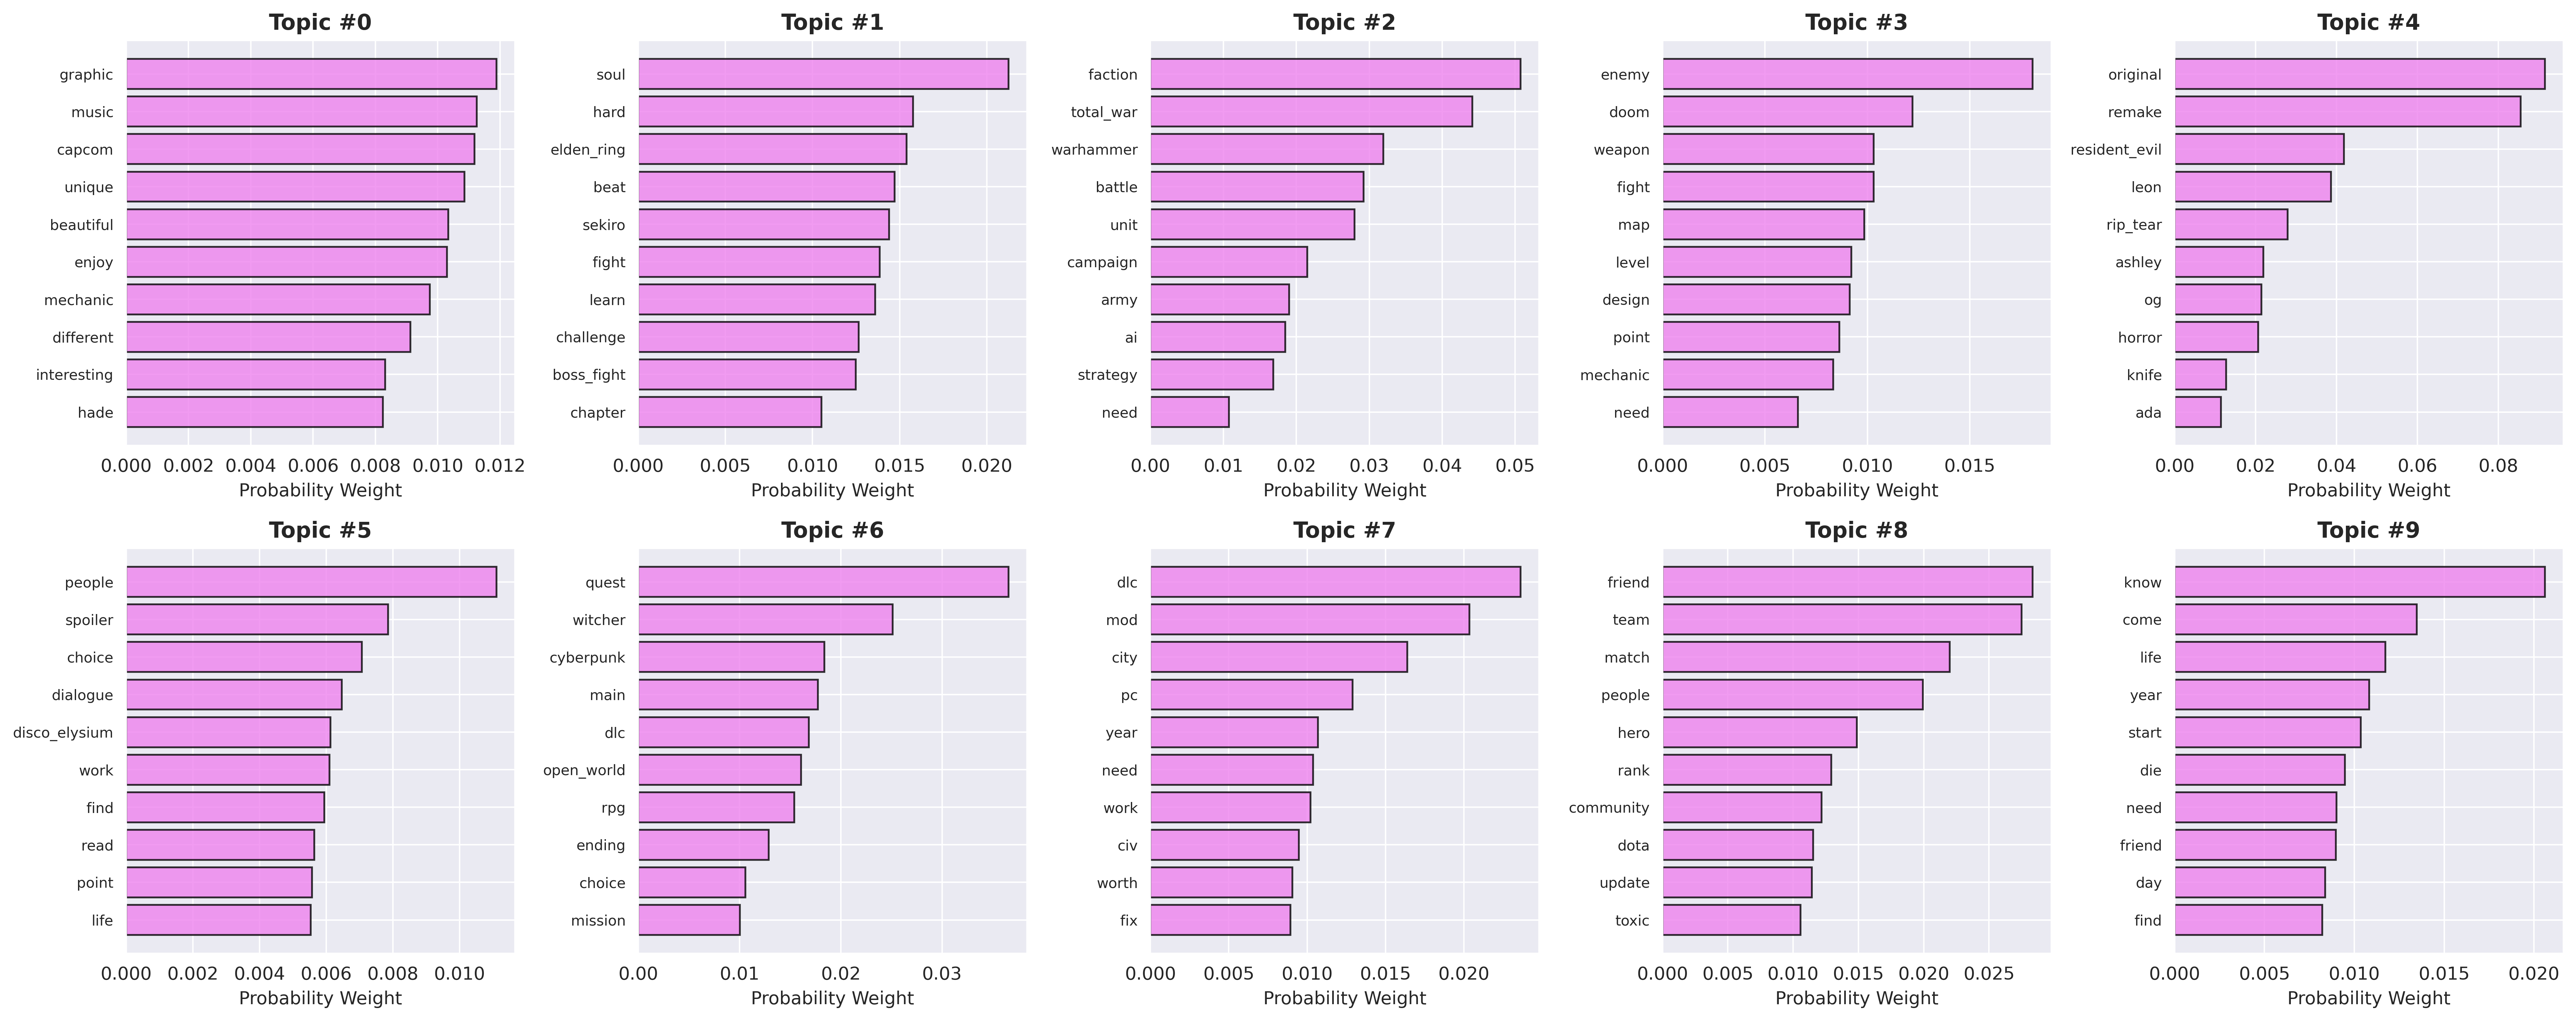

In [ ]:
# Set up the figure with 2 rows and 5 columns for our 10 topics
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=False, dpi=200)
axes = axes.flatten()

for k in range(lda_model.k):
    # Get the top 10 words and their probabilities (weights)
    top_words = lda_model.get_topic_words(k, top_n=10)
    words = [word for word, prob in top_words]
    weights = [prob for word, prob in top_words]

    # Reverse the lists so the highest probability word is at the top of the chart
    words.reverse()
    weights.reverse()

    # Plot the horizontal bar chart
    ax = axes[k]
    ax.barh(words, weights, color='violet', edgecolor='black', alpha=0.8)
    ax.set_title(f'Topic #{k}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Probability Weight', fontsize=10)
    ax.tick_params(axis='y', labelsize=8)

# Adjust layout so subplots don't overlap
plt.tight_layout()
plt.show()

The horizontal bar charts above display the top words and their probability weights for our 10 topics. The LDA model successfully clustered the reviews into highly distinct and recognizable gaming categories:

* **Topic 0 (Art, music and uniqueness):** *graphic, capcom, unique* - Praise for graphics, music, beautiful aesthetics, and unique mechanics (with notable mentions of Capcom titles).
* **Topic 1 (Souls-likes):** *soul, hard, elden_ring* - Reviews about difficult/challenging games like Elden Ring and Sekiro, focusing on learning curves and boss fights.
* **Topic 2 (Total War strategy):** *faction, total_war, warhammer* - Managing Total War: Warhammer factions, armies, campaigns, and strategy.
* **Topic 3 (DOOM combat):** *enemy, doom, weapon* - DOOM combat flow, weapons, enemies, level design, and map mechanics.
* **Topic 4 (Resident Evil remakes):** *original, remake, resident_evil* - Comparison of Resident Evil originals and remakes, mentioning specific characters (Leon, Ashley) and horror elements.
* **Topic 5 (Disco Elysium choices):** *spoiler, choice, dialogue* - Disco Elysium dialogue, heavy reading, player choices, spoilers, and life themes.
* **Topic 6 (Open-world RPGs):** *quest, witcher, cyberpunk* - Open-world RPG quests, choices, endings, and exploration (featuring The Witcher and Cyberpunk's Night City).
* **Topic 7 (Updates, mods and DLC):** *dlc, mod, update* - DLCs, mods, game updates, PC performance, and city-building elements (like Civ).
* **Topic 8 (Competitive teamplay and toxicity):** *team, match, toxic* - Dota team matches, ranks, hero picks, and community toxicity.
* **Topic 9 (Personal experiences in gaming):** *know, friend, life* - Personal stories about friends, life changes, and gaming experiences over the years.

This clear separation confirms that the vector representation we extract from this model will be highly informative for our classification task.

Although our current topics are very coherent, we could implement the following strategies to further refine their token description:
* **Strict Language Filtering: (DONE)** Since Topic 5 revealed the presence of Spanish and Portuguese reviews, we could use a library like `langdetect` during the initial SpaCy preprocessing step to drop any review that is not 100% English.
* **Domain-Specific Stopword Removal:** We could manually expand our stopword list with generic gaming terms (e.g., *game, play, player*) if they start dominating the topics. Fortunately, `tomotopy`'s `rm_top` parameter already handles much of this by removing the most globally frequent words.
* **Hyperparameter Tuning:** We could run a coherence analysis (e.g., calculating the $C_v$ coherence score) across different values of $k$ (e.g., $k=5, 10, 15$) to find the mathematically optimal number of topics, ensuring we are not artificially splitting or merging semantic concepts.

In [ ]:
print("Extracting data from Tomotopy for pyLDAvis...")

# 1. Extract Topic-Term Distributions (Probability of each word in each topic)
topic_term_dists = np.stack([lda_model.get_topic_word_dist(k) for k in range(lda_model.k)])

# 2. Extract Document-Topic Distributions (Probability of each topic in each document)
doc_topic_dists = np.stack([doc.get_topic_dist() for doc in lda_model.docs])

# 3. Extract Document Lengths (Number of words per document)
doc_lengths = np.array([len(doc.words) for doc in lda_model.docs])

# 4. Extract Vocabulary and Term Frequencies
vocab = list(lda_model.used_vocabs)
term_frequency = lda_model.used_vocab_freq

print("Generating interactive visualization...")

# 5. Prepare the visualization data
vis_data = pyLDAvis.prepare(
    topic_term_dists,
    doc_topic_dists,
    doc_lengths,
    vocab,
    term_frequency,
    sort_topics=False # We keep it False so Topic 0 here matches Topic 0 from our previous print
)

# 6. Display the interactive chart
pyLDAvis.enable_notebook()
pyLDAvis.display(vis_data)
pyLDAvis.save_html(vis_data, 'mapa.html') # In case it does not render

Extracting data from Tomotopy for pyLDAvis...
Generating interactive visualization...


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.219710 -0.061833       1        1  13.707741
1      0.173342 -0.089667       2        1   9.302480
2     -0.311213 -0.283632       3        1   2.541883
3      0.051778  0.092717       4        1  18.029942
4     -0.082903 -0.098236       5        1   1.926643
5      0.103644  0.091638       6        1  13.409982
6      0.153328 -0.159186       7        1   4.546585
7     -0.090448  0.071077       8        1  12.608310
8     -0.218937  0.233373       9        1   4.521814
9      0.001700  0.203748      10        1  19.404621, topic_info=        Term        Freq        Total Category  logprob  loglift
47  original  529.000000   529.000000  Default  30.0000  30.0000
8        dlc  998.000000   998.000000  Default  29.0000  29.0000
19    friend  758.000000   758.000000  Default  28.0000  28.0000
71    remake  413.000000   413.000000  Default  27.0000  27.0000
62     quest  467.000000   467.000000  Default  26.0000  26.0000
..       ...         ...          ...      ...      ...      ...
11       end  331.583709   961.576573  Topic10  -4.9885   0.5750
52  favorite  259.614818   520.193028  Topic10  -5.2332   0.9447
2      enjoy  339.294664  1162.620763  Topic10  -4.9655   0.4081
38      lose  267.325773   573.557649  Topic10  -5.2039   0.8763
31    finish  267.325773   652.248011  Topic10  -5.2039   0.7477

[648 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
166       1  0.050585       ability
166       2  0.144529       ability
166       4  0.805749       ability
259       1  0.136164      absolute
259      10  0.863938      absolute
...     ...       ...           ...
9         8  0.336727          year
9        10  0.525015          year
2655      5  1.014377  yellow_paint
749       6  0.996208            za
1076      1  1.000834       zagreus

[1050 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

The interactive pyLDAvis map is a crucial tool for diagnosing our LDA model's performance. By projecting the high-dimensional topic distributions into a 2D space, the current map confirms a robust and well-defined semantic structure:

* **Spatial Distribution and Distinctiveness:** The Intertopic Distance Map shows excellent separation between gaming genres. For instance, **Topic 1** (Souls-like: *elden_ring, sekiro, boss*) is clearly isolated, proving it possesses a highly specialized vocabulary. Furthermore, Strategy games (**Topic 2**: *warhammer, battle*) and Competitive eSports (**Topic 8**: *dota, rank, toxic*) are plotted far apart, demonstrating that the model accurately distinguishes between tactical mechanics and competitive multiplayer environments.
* **Corpus Balance (Prevalence):** The size of the bubbles represents the proportion of documents belonging to each topic. The distribution is remarkably balanced; no single topic heavily overshadows the rest. This equilibrium is critical for **Task 2**, ensuring our Machine Learning classifiers will not be biased toward a single dominant theme.
* **Thematic Clustering:** Story-rich RPGs (**Topic 6**: *cyberpunk, witcher*) and Narrative/Dialogue games (**Topic 5**: *disco_elysium, dialogue*) are positioned near each other without overlapping. This indicates the model successfully recognizes their shared "narrative" foundation while maintaining their distinct game identities.

In conclusion, the clear visual separation and the purity of the keywords in each cluster perfectly validate that our choice of $k=10$ is optimal. The model provides a reliable, high-quality feature matrix for the downstream predictive modeling.

While our initial model with $k=10$ topics yielded highly interpretable results, best practices in Topic Modeling require a mathematical justification for this choice.

To find the optimal number of topics ($k$), we will train multiple LDA models with varying values of $k$ ($k \in [5, 10, 15, 20, 25, 50]$). We will evaluate these models using two complementary metrics:

1. **$C_v$ Coherence Score:** Measures the semantic similarity between the top words in each topic based on their co-occurrence. We look for the peak of the curve, representing the ideal balance between topic granularity and human interpretability.
2. **Topic Stability (Jaccard Similarity):** Measures the overlap of top words between consecutive models. If the similarity plateaus or drops as $k$ increases, it indicates that new topics are merely redundant, fragmented versions of existing ones.

Starting hyperparameter tuning and stability analysis for LDA...
--------------------------------------------------
Training LDA model with k=5...


/usr/local/lib/python3.12/dist-packages/tomotopy/models.py:637: RuntimeWarning: The training result may differ even with fixed seed if `workers` != 1.
  return self._train(iterations, workers, parallel, freeze_topics, callback_interval, callback)


 -> Coherence Score (C_v) for k=5: 0.4872
Training LDA model with k=10...
 -> Coherence Score (C_v) for k=10: 0.5966
Training LDA model with k=15...
 -> Coherence Score (C_v) for k=15: 0.6189
Training LDA model with k=20...
 -> Coherence Score (C_v) for k=20: 0.6206
Training LDA model with k=25...
 -> Coherence Score (C_v) for k=25: 0.6493
Training LDA model with k=50...
 -> Coherence Score (C_v) for k=50: 0.6226
--------------------------------------------------
Training completed! Calculating Jaccard similarities...
Calculations finished! Generating plots...


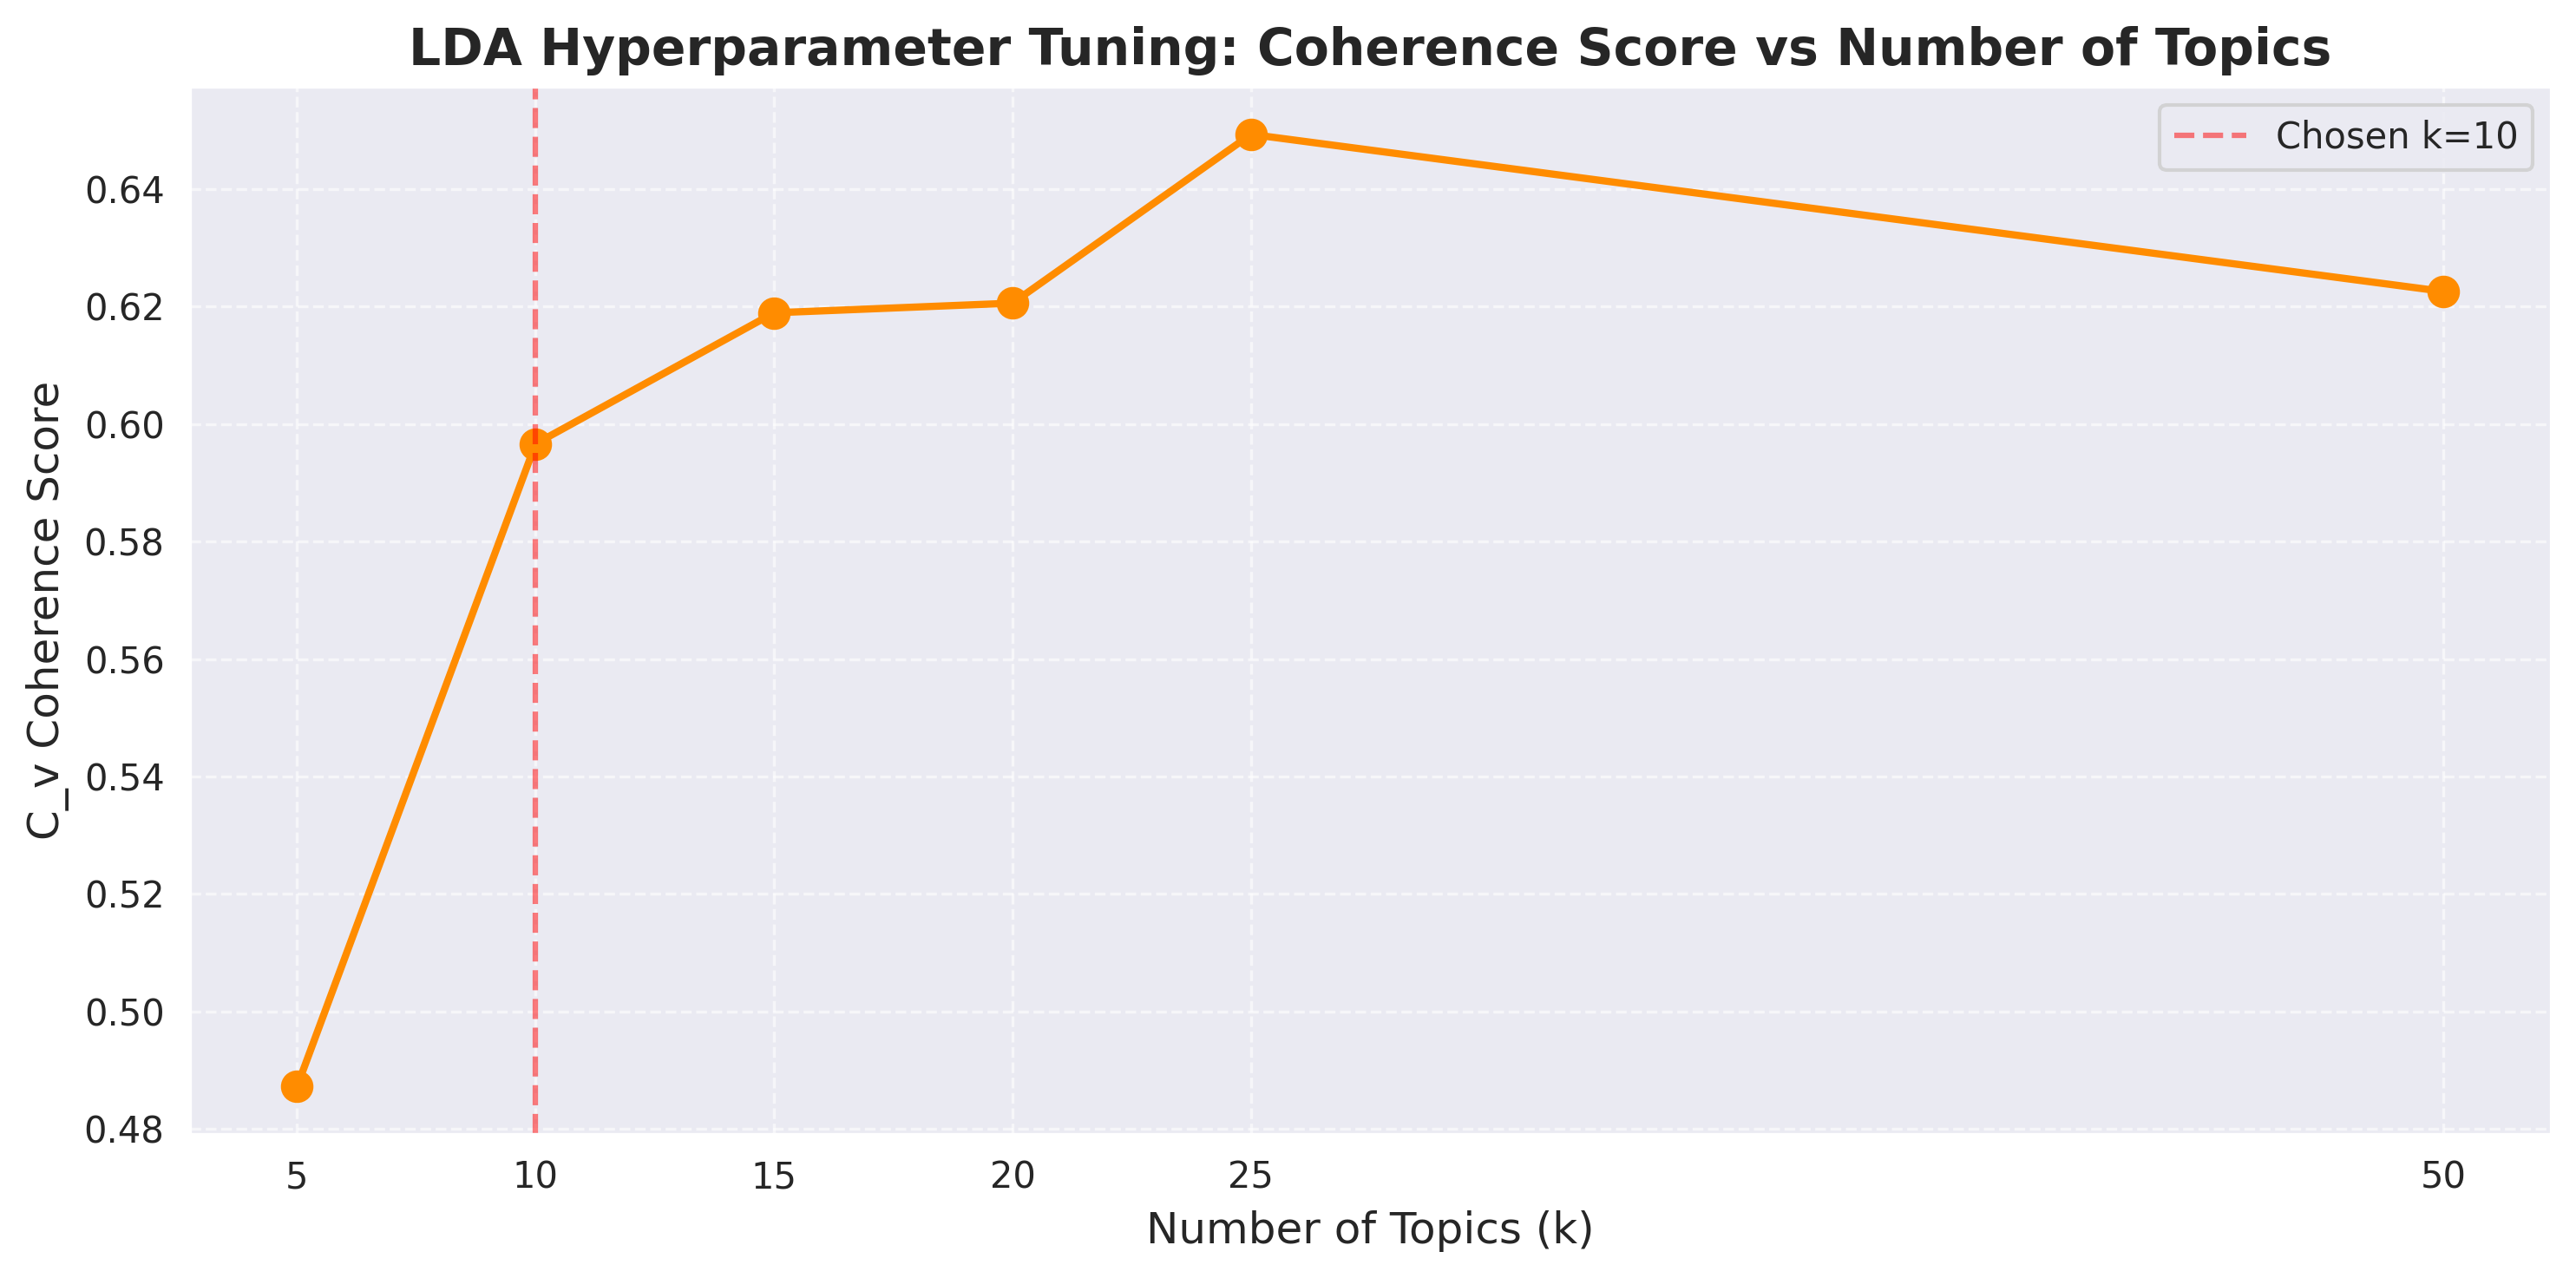

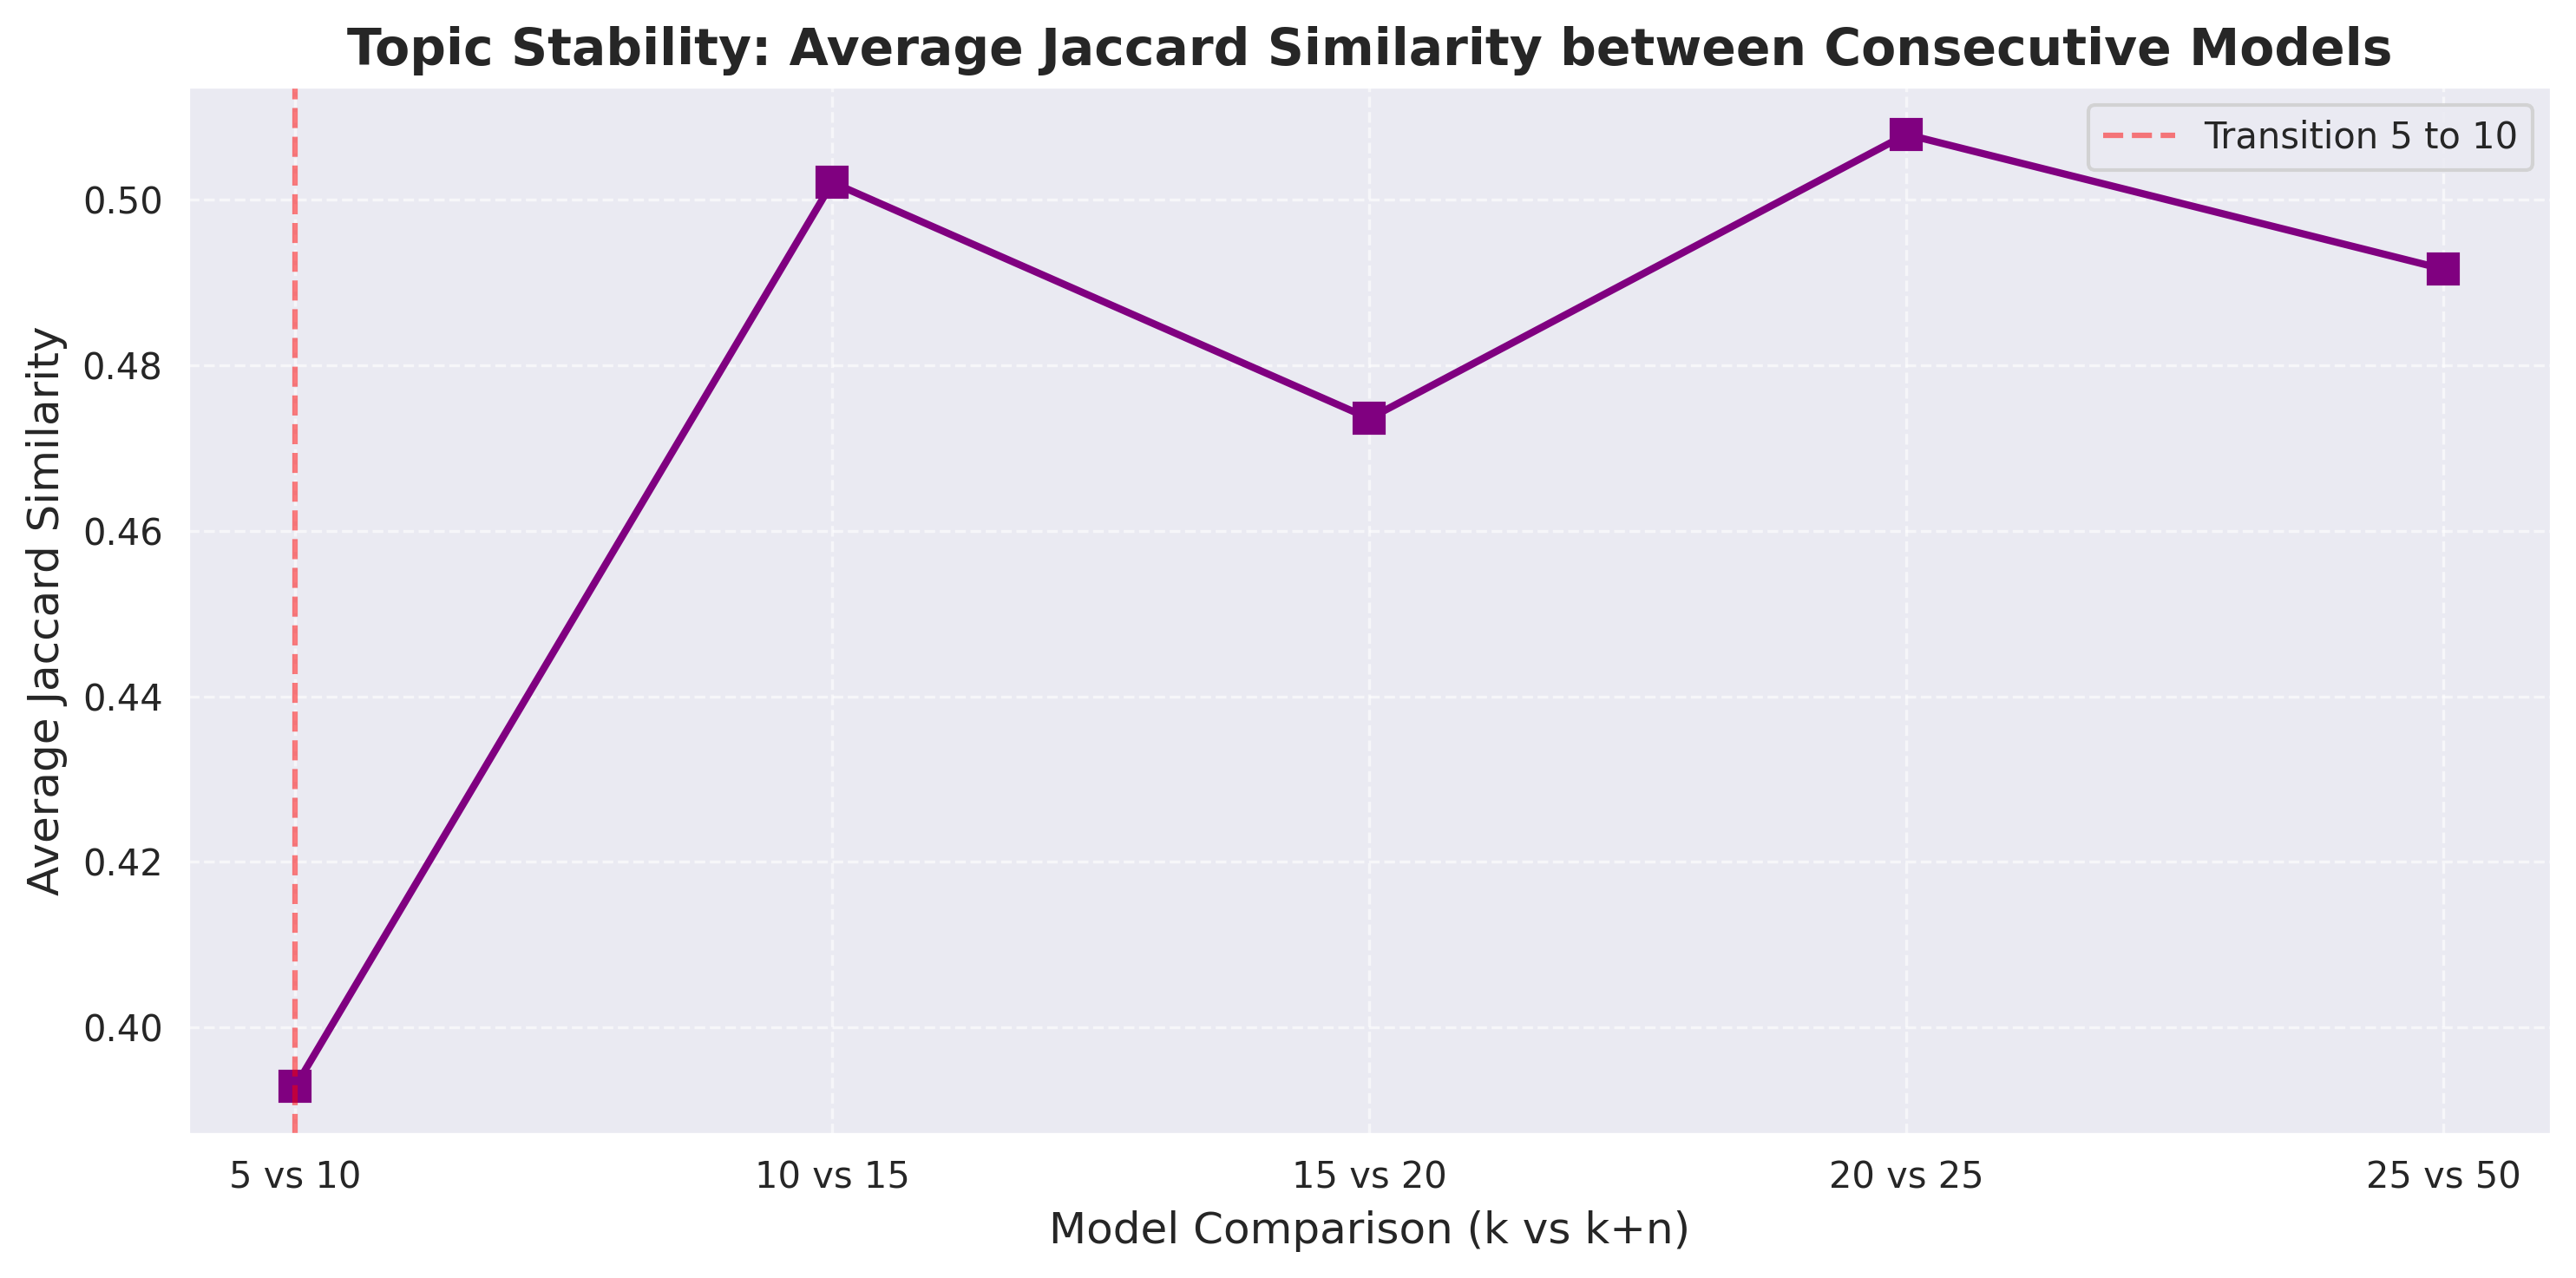

In [ ]:
# Define the Jaccard similarity function to compare topic overlaps
def jaccard_similarity(list1, list2):
    set1, set2 = set(list1), set(list2)
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union != 0 else 0

# Define the candidate values for k (number of topics)
k_values = [5, 10, 15, 20, 25, 50]
coherence_scores = []
top_words_per_model = {} # Dictionary to store top words for stability analysis

print("Starting hyperparameter tuning and stability analysis for LDA...")
print("-" * 50)

for k in k_values:
    print(f"Training LDA model with k={k}...")

    # Initialize the model (using 500 iterations to speed up the tuning process)
    temp_model = tp.LDAModel(k=k, min_df=5, rm_top=20, seed=42)

    # Add documents (using the variable we created in the N-grams step)
    for doc in corpus_with_ngrams:
        temp_model.add_doc(doc)

    # Train the model
    temp_model.train(500)

    # Calculate the c_v coherence score
    coh = tp.coherence.Coherence(temp_model, coherence='c_v')
    score = coh.get_score()
    coherence_scores.append(score)

    print(f" -> Coherence Score (C_v) for k={k}: {score:.4f}")

    # Extract the top 15 words for each topic to use later in Jaccard similarity
    topics_words = []
    for i in range(k):
        words = [word for word, prob in temp_model.get_topic_words(i, top_n=15)]
        topics_words.append(words)

    # Store the extracted words for this specific k
    top_words_per_model[k] = topics_words

print("-" * 50)
print("Training completed! Calculating Jaccard similarities...")

# Calculate Jaccard similarity between consecutive models
average_similarities = []
comparisons = []

for i in range(len(k_values) - 1):
    k_current = k_values[i]
    k_next = k_values[i + 1]
    comparisons.append(f"{k_current} vs {k_next}")

    current_topics = top_words_per_model[k_current]
    next_topics = top_words_per_model[k_next]

    max_sims_for_current_model = []

    # For each topic in the current model, find the maximum similarity in the next model
    for topic_words in current_topics:
        sims = [jaccard_similarity(topic_words, next_topic_words) for next_topic_words in next_topics]
        max_sims_for_current_model.append(max(sims))

    # Calculate the average of the maximum similarities
    average_similarities.append(np.mean(max_sims_for_current_model))

print("Calculations finished! Generating plots...")

# Plot 1: Coherence Scores
plt.figure(figsize=(10, 5), dpi=150)
plt.plot(k_values, coherence_scores, marker='o', linestyle='-', color='darkorange', linewidth=2, markersize=8)
plt.title('LDA Hyperparameter Tuning: Coherence Score vs Number of Topics', fontsize=14, fontweight='bold')
plt.xlabel('Number of Topics (k)', fontsize=12)
plt.ylabel('C_v Coherence Score', fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(x=10, color='red', linestyle='--', alpha=0.5, label='Chosen k=10')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Topic Stability (Jaccard Similarity)
plt.figure(figsize=(10, 5), dpi=150)
plt.plot(comparisons, average_similarities, marker='s', linestyle='-', color='purple', linewidth=2, markersize=8)
plt.title('Topic Stability: Average Jaccard Similarity between Consecutive Models', fontsize=14, fontweight='bold')
plt.xlabel('Model Comparison (k vs k+n)', fontsize=12)
plt.ylabel('Average Jaccard Similarity', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Transition 5 to 10')
plt.legend()
plt.tight_layout()
plt.show()

The hyperparameter tuning and stability analysis provide a strong mathematical justification for our choice of $k=10$ topics.
* **Coherence Curve Analysis:** The $C_v$ coherence score demonstrates a distinct and sharp peak exactly at $k=10$. This indicates that the top words within each topic share the highest semantic similarity and real-world co-occurrence. For $k > 10$, the coherence drops significantly, suggesting that forcing the model to find more topics results in less interpretable and noisier word groupings.
* **Topic Stability and Redundancy:** The Jaccard similarity plot clearly visualizes at what point additional topics become redundant. In the transition from $k=5$ to $k=10$, the Jaccard similarity is low, meaning the model is successfully discovering genuinely new and distinct semantic spaces. However, when transitioning from $k=10$ to $k=15$ and beyond, the similarity increases. This means that the additional topics are not capturing new concepts, they are merely redundant fragments or slightly altered copies of the core 10 topics.

**Conclusion:** Both metrics align perfectly. The coherence curve reflects the same behavior as the stability plot; expanding beyond 10 topics introduces redundancy without improving semantic quality. Therefore, $k=10$ is mathematically validated as the optimal hyperparameter.

Before extracting our final feature matrix, we will perform two brief analyses to demonstrate the practical utility of our $k=10$ LDA model.

First, we will calculate the **Semantic Similarity** (Cosine Similarity) between two specific reviews using their topic distributions. This illustrates how topic modeling translates semantic meaning into mathematical proximity.

Second, to better understand our dataset at a macro level, we will calculate the **Dominant Topic** for each document and visualize the overall distribution of topics across the entire corpus.

--- SEMANTIC SIMILARITY ---
Cosine Similarity between Review 0 and Review 1: 0.6114
Review 0 Top Topic: 8
Review 1 Top Topic: 1
--------------------------------------------------
Actual Text Snippets:
Review 0: "the game is fun when you're not playing with failed abortions and "people" made from nuclear waste"
Review 1: "i like this game very much but its also hard and challanging and that makes the game fun"
--------------------------------------------------
--- DOMINANT TOPIC DISTRIBUTION ---


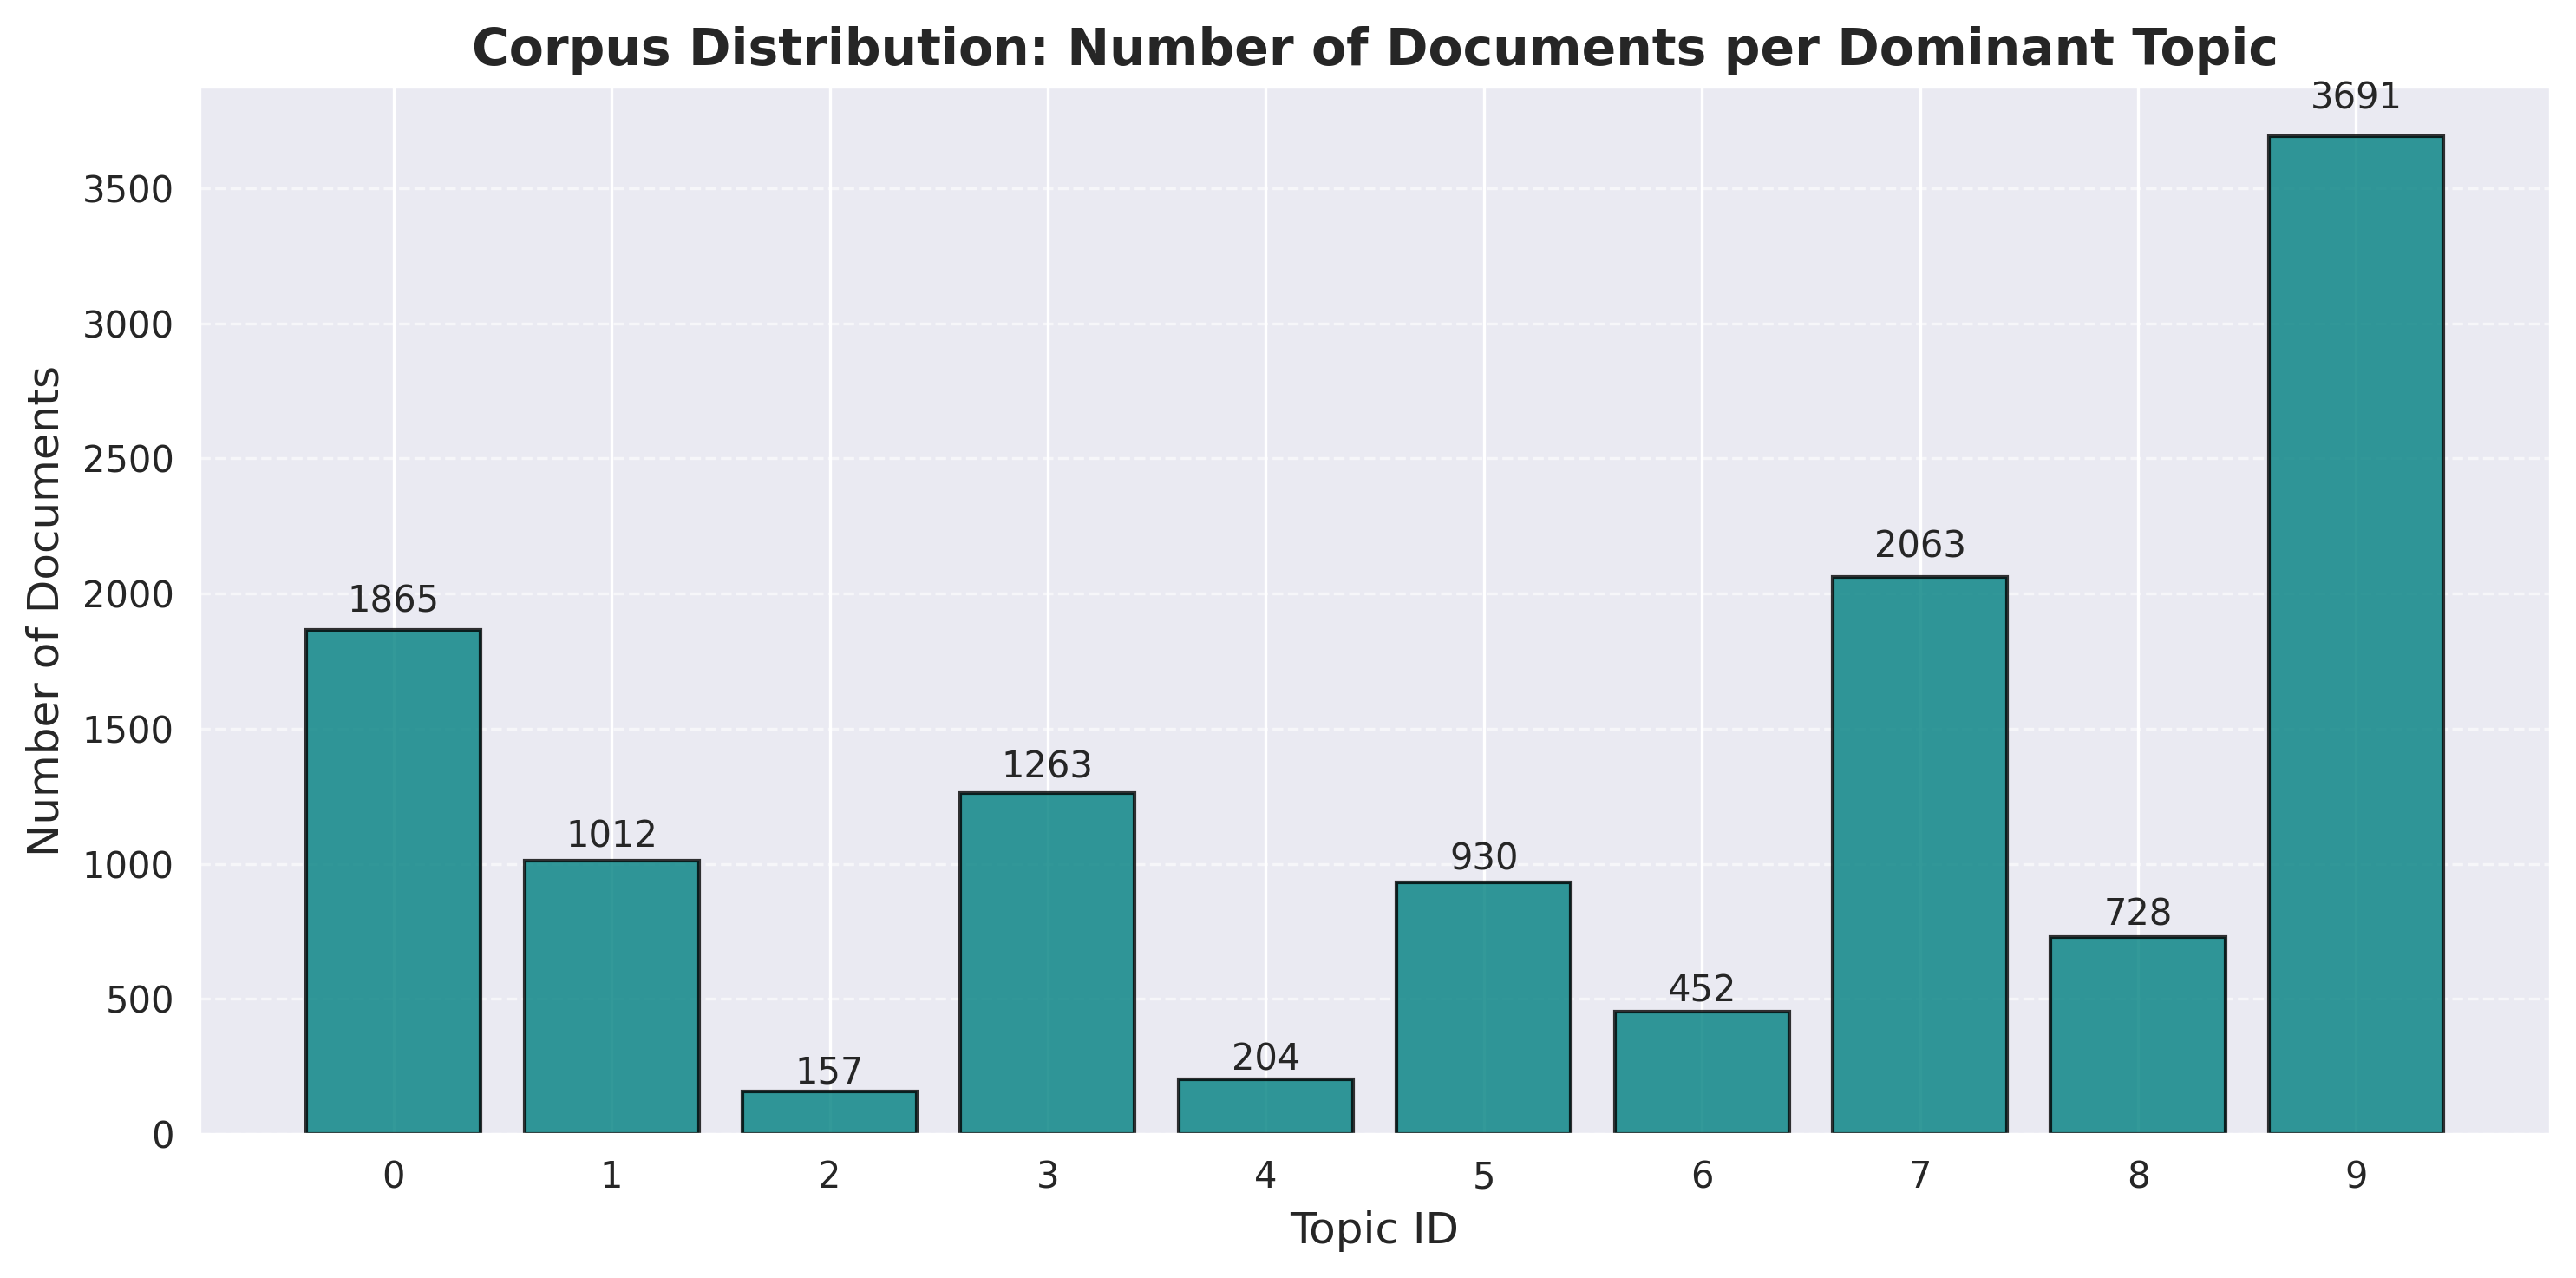

In [ ]:
# 1. SEMANTIC SIMILARITY CALCULATION
print("--- SEMANTIC SIMILARITY ---")

# Instead of using lda_model.docs, we create the documents on the fly from the corpus
doc_0_infer = lda_model.make_doc(corpus_with_ngrams[0])
doc_1_infer = lda_model.make_doc(corpus_with_ngrams[1])

# Infer their topic distribution using the already trained model
dist_0, _ = lda_model.infer(doc_0_infer)
dist_1, _ = lda_model.infer(doc_1_infer)

# Prepare the vectors for sklearn's cosine_similarity function
vec_0 = np.array(dist_0).reshape(1, -1)
vec_1 = np.array(dist_1).reshape(1, -1)

# Calculate the cosine similarity
sim = cosine_similarity(vec_0, vec_1)[0][0]

print(f"Cosine Similarity between Review 0 and Review 1: {sim:.4f}")
print(f"Review 0 Top Topic: {np.argmax(vec_0)}")
print(f"Review 1 Top Topic: {np.argmax(vec_1)}")
print("-" * 50)

print("Actual Text Snippets:")
print(f"Review 0: \"{df['review_text'].iloc[0]}\"")
print(f"Review 1: \"{df['review_text'].iloc[1]}\"")
print("-" * 50)

# 2. DOMINANT TOPIC DISTRIBUTION
print("--- DOMINANT TOPIC DISTRIBUTION ---")

dominant_topics = []

# Iterate over the original corpus to avoid relying on the model's corrupted cache
for text_tokens in corpus_with_ngrams:
    doc_infer = lda_model.make_doc(text_tokens)
    dist, _ = lda_model.infer(doc_infer)
    dominant_topics.append(np.argmax(dist))

# Count the number of documents assigned to each topic
topic_counts = pd.Series(dominant_topics).value_counts().sort_index()

# Draw the bar chart
plt.figure(figsize=(10, 5), dpi=150)
bars = plt.bar(topic_counts.index.astype(str), topic_counts.values, color='teal', edgecolor='black', alpha=0.8)

plt.title('Corpus Distribution: Number of Documents per Dominant Topic', fontsize=14, fontweight='bold')
plt.xlabel('Topic ID', fontsize=12)
plt.ylabel('Number of Documents', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add the exact count numbers on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), int(yval), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

The semantic analysis validates our model's ability to differentiate document meanings mathematically.
* **Cosine Similarity:** The similarity score between Review 0 and Review 1 is approximately 0.6114. This moderate score indicates that while they share some general vocabulary (like "game" and "fun"), their core semantic themes diverge.
* **Topic Assignment & Raw Text:** This divergence is clearly explained by their dominant topics and confirmed by reading the actual text. Review 0 (Topic 8) expresses harsh frustration with other players in the community, whereas Review 1 (Topic 1) focuses on praising the game's challenging mechanics. The model successfully captures this real-world semantic distinction.

Furthermore, the **Dominant Topic Distribution** chart provides a macro-level view of our dataset. The distribution shows distinct thematic preferences within the corpus. Topic 9 and Topic 7 are by far the most heavily represented, indicating that personal experiences and discussions about updates/DLCs dominate the user reviews. Conversely, highly specific franchise topics like Topic 2 and Topic 4 are the least dominant. While the corpus is not perfectly even, this diverse distribution accurately reflects real-world gaming discourse, providing a realistic and rich feature matrix for the downstream Machine Learning classification tasks.

With our optimal model established and its semantic properties validated, we now perform the final vectorization of our corpus. We will transform every document into a $k$-dimensional feature vector, where each feature represents the probability of the document belonging to a specific topic.

This numerical matrix, `X_topics`, captures the latent semantic meaning of each review and will serve as the primary input for the Machine Learning classification models in Task 2.

In [ ]:
# Create an empty list to store the probability vectors
topic_distributions = []

# We iterate over the original corpus and infer the distribution to avoid memory cache errors
for text_tokens in corpus_with_ngrams:
    # Create the document on the fly
    doc_infer = lda_model.make_doc(text_tokens)
    # Infer its topic probability distribution
    dist, _ = lda_model.infer(doc_infer)
    topic_distributions.append(dist)

# Convert the list into a solid NumPy array for Machine Learning compatibility
X_topics = np.array(topic_distributions)

print(f"Topic-based feature matrix shape: {X_topics.shape}")
print("-" * 50)

# Convert the NumPy array into a structured Pandas DataFrame
topic_column_names = [f"Topic_{i}" for i in range(X_topics.shape[1])]
X_topics_df = pd.DataFrame(X_topics, columns=topic_column_names)

print("First 5 rows of the final X_topics feature matrix:")
display(X_topics_df.head())

# Save the feature matrix to avoid retraining in the future
X_topics_df.to_csv('X_topics_features.csv', index=False)
print("-" * 50)
print("Topic feature matrix successfully saved to 'X_topics_features.csv'")

Topic-based feature matrix shape: (12365, 10)
--------------------------------------------------
First 5 rows of the final X_topics feature matrix:


,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9
0,0.055884,0.182126,0.005337,0.052699,0.007035,0.044153,0.017403,0.207105,0.318862,0.109396
1,0.079538,0.470845,0.007597,0.075005,0.010012,0.062841,0.024768,0.083133,0.030561,0.155700
2,0.043074,0.025768,0.004114,0.040620,0.005422,0.034032,0.013414,0.618075,0.016551,0.198931
3,0.027383,0.016381,0.002615,0.390116,0.003447,0.094493,0.008527,0.028620,0.301956,0.126462
4,0.038645,0.023118,0.003691,0.036443,0.004865,0.030533,0.012034,0.040392,0.631803,0.178476


--------------------------------------------------
Topic feature matrix successfully saved to 'X_topics_features.csv'


#### 4. Contextual embeddings:


Unlike classical or static word embeddings (BoW, Word2Vec), **contextual embeddings** represent each token differently depending on the surrounding context. We use **`all-MiniLM-L6-v2`**, a lightweight but powerful BERT-based Sentence Transformer that maps full sentences to dense 384-dimensional vectors capturing semantic meaning.

**Why this model?**
- Trained specifically for semantic similarity tasks via contrastive learning.
- Much faster than full BERT while retaining strong representation quality.
- Produces a single fixed-size vector per document — ideal for downstream ML.

The pipeline is:
1. Load the pre-trained model.
2. Encode all reviews into a `(N, 384)` matrix `X_bert`.
3. Validate the embeddings with cosine similarity checks.
4. Visualise the embedding space with PCA.
5. Save the feature matrix for Task 2.

**Why Contextual Embeddings?**

The three previous vectorization strategies all share a fundamental limitation: they assign
a **fixed representation** to each word or document, regardless of context.

- **BoW / TF-IDF** — purely statistical, no semantic meaning.
- **Word2Vec** — each word has one vector, so "bug" in *"the game has a bug"* and
  *"the bug was fixed"* would get the **exact same embedding**, even though the
  nuance may differ.
- **LDA** — treats documents as mixtures of topics, but ignores word order and
  fine-grained meaning.

**Transformer-based models** (BERT and its variants) solve this by computing embeddings
dynamically — the representation of each token depends on all the other tokens in the
sentence via a **self-attention mechanism**. This makes them especially powerful for
sentiment-rich text like Steam reviews, where the same word can carry very different
meanings depending on context (e.g., *"this game is sick"* — positive slang vs. literal).

In [ ]:
# Reproducibility
np.random.seed(42)

# Device detection
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Load the pre-trained Sentence Transformer
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
bert_model = SentenceTransformer(MODEL_NAME, device=device)
print(f"Model loaded: {MODEL_NAME}")
print(f"Embedding dimension: {bert_model.get_sentence_embedding_dimension()}")

# Use the cleaned review texts (same column used throughout the project)
texts = df_clean["review_text"].tolist()   # adjust to your actual column name if needed
print(f"\nTotal reviews to encode: {len(texts)}")
print(f"Sample text [0]: {texts[0][:120]}...")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded: sentence-transformers/all-MiniLM-L6-v2
Embedding dimension: 384

Total reviews to encode: 12365
Sample text [0]: the game is fun when you're not playing with failed abortions and "people" made from nuclear waste...


**Model: `all-MiniLM-L6-v2`**

We use **`sentence-transformers/all-MiniLM-L6-v2`**, a distilled version of BERT
fine-tuned specifically for **semantic sentence similarity** via contrastive learning
(Sentence-BERT framework, Reimers & Gurevych, 2019).

Key properties:
- **Architecture**: 6-layer MiniLM transformer, distilled from a 12-layer BERT-base.
- **Output**: A single fixed-size **384-dimensional** dense vector per document.
- **Training objective**: Minimises cosine distance between semantically similar
  sentence pairs (using natural language inference and paraphrase datasets).
- **Why not full BERT?** Full BERT (`bert-base-uncased`) produces 768-dimensional
  vectors and is ~3× slower. MiniLM retains ~95% of the performance at a fraction
  of the computational cost — ideal for encoding 12,000+ reviews.
- **`normalize_embeddings=True`**: L2-normalises every output vector, so
  cosine similarity equals the dot product, making downstream distance comparisons
  faster and numerically stable.

In [ ]:
print("Encoding reviews with BERT...")

X_bert = bert_model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    device=device,
    normalize_embeddings=True,   # L2-normalise → cosine similarity = dot product
)

print(f"\nContextual embedding matrix shape: {X_bert.shape}")
print(f"  → {X_bert.shape[0]} documents × {X_bert.shape[1]} dimensions")
print(f"Vector norm (should be ~1.0 after normalisation): {np.linalg.norm(X_bert[0]):.4f}")

Encoding reviews with BERT...


Batches:   0%|          | 0/194 [00:00<?, ?it/s]


Contextual embedding matrix shape: (12365, 384)
  → 12365 documents × 384 dimensions
Vector norm (should be ~1.0 after normalisation): 1.0000


Embedding Validation

Before using the embeddings in Task 2, we validate that the model has captured meaningful semantic structure by:
- Computing **cosine similarity** between handpicked review pairs (same/different sentiment).
- Inspecting the **distribution of pairwise similarities** across a random sample.
- Visualising the full embedding space with **PCA** coloured by sentiment and by game.

In [ ]:
# ── 1. Handpicked pair: two POSITIVE reviews ─────────────────────────────────
pos_idx = df_clean[df_clean["sentiment"] == "positive"].index[:2].tolist()
# ── 2. Cross-sentiment pair: one POSITIVE, one NEGATIVE ─────────────────────
neg_idx = df_clean[df_clean["sentiment"] == "negative"].index[0]

pairs = {
    "Positive ↔ Positive (same sentiment)": (pos_idx[0], pos_idx[1]),
    "Positive ↔ Negative (opposite sentiment)": (pos_idx[0], neg_idx),
}

print("=" * 65)
print("COSINE SIMILARITY BETWEEN REVIEW PAIRS")
print("=" * 65)
for label, (i, j) in pairs.items():
    sim = cosine_similarity(X_bert[i:i+1], X_bert[j:j+1])[0, 0]
    print(f"\n{label}")
    print(f"  Review A (idx={i}): {df_clean['review_text'].iloc[i][:100]}...")
    print(f"  Review B (idx={j}): {df_clean['review_text'].iloc[j][:100]}...")
    print(f"  Cosine Similarity: {sim:.4f}")

# ── 3. Distribution of similarities on a random sample ───────────────────────
print("\n" + "=" * 65)
SAMPLE = 500
idx_sample = np.random.choice(len(X_bert), size=SAMPLE, replace=False)
sim_matrix = cosine_similarity(X_bert[idx_sample])

# Extract upper triangle (exclude diagonal)
upper = sim_matrix[np.triu_indices(SAMPLE, k=1)]

print(f"Pairwise similarity stats (random {SAMPLE}-doc sample):")
print(f"  Mean: {upper.mean():.4f}")
print(f"  Std : {upper.std():.4f}")
print(f"  Min : {upper.min():.4f}")
print(f"  Max : {upper.max():.4f}")

COSINE SIMILARITY BETWEEN REVIEW PAIRS

Positive ↔ Positive (same sentiment)
  Review A (idx=0): the game is fun when you're not playing with failed abortions and "people" made from nuclear waste...
  Review B (idx=1): i like this game very much but its also hard and challanging and that makes the game fun...
  Cosine Similarity: 0.4155

Positive ↔ Negative (opposite sentiment)
  Review A (idx=0): the game is fun when you're not playing with failed abortions and "people" made from nuclear waste...
  Review B (idx=3): I play with no prime. 4 teamates leave game. all teamates have red crosshairs and are ♥♥♥♥ i cant co...
  Cosine Similarity: 0.2642

Pairwise similarity stats (random 500-doc sample):
  Mean: 0.2715
  Std : 0.1330
  Min : -0.1881
  Max : 0.8494


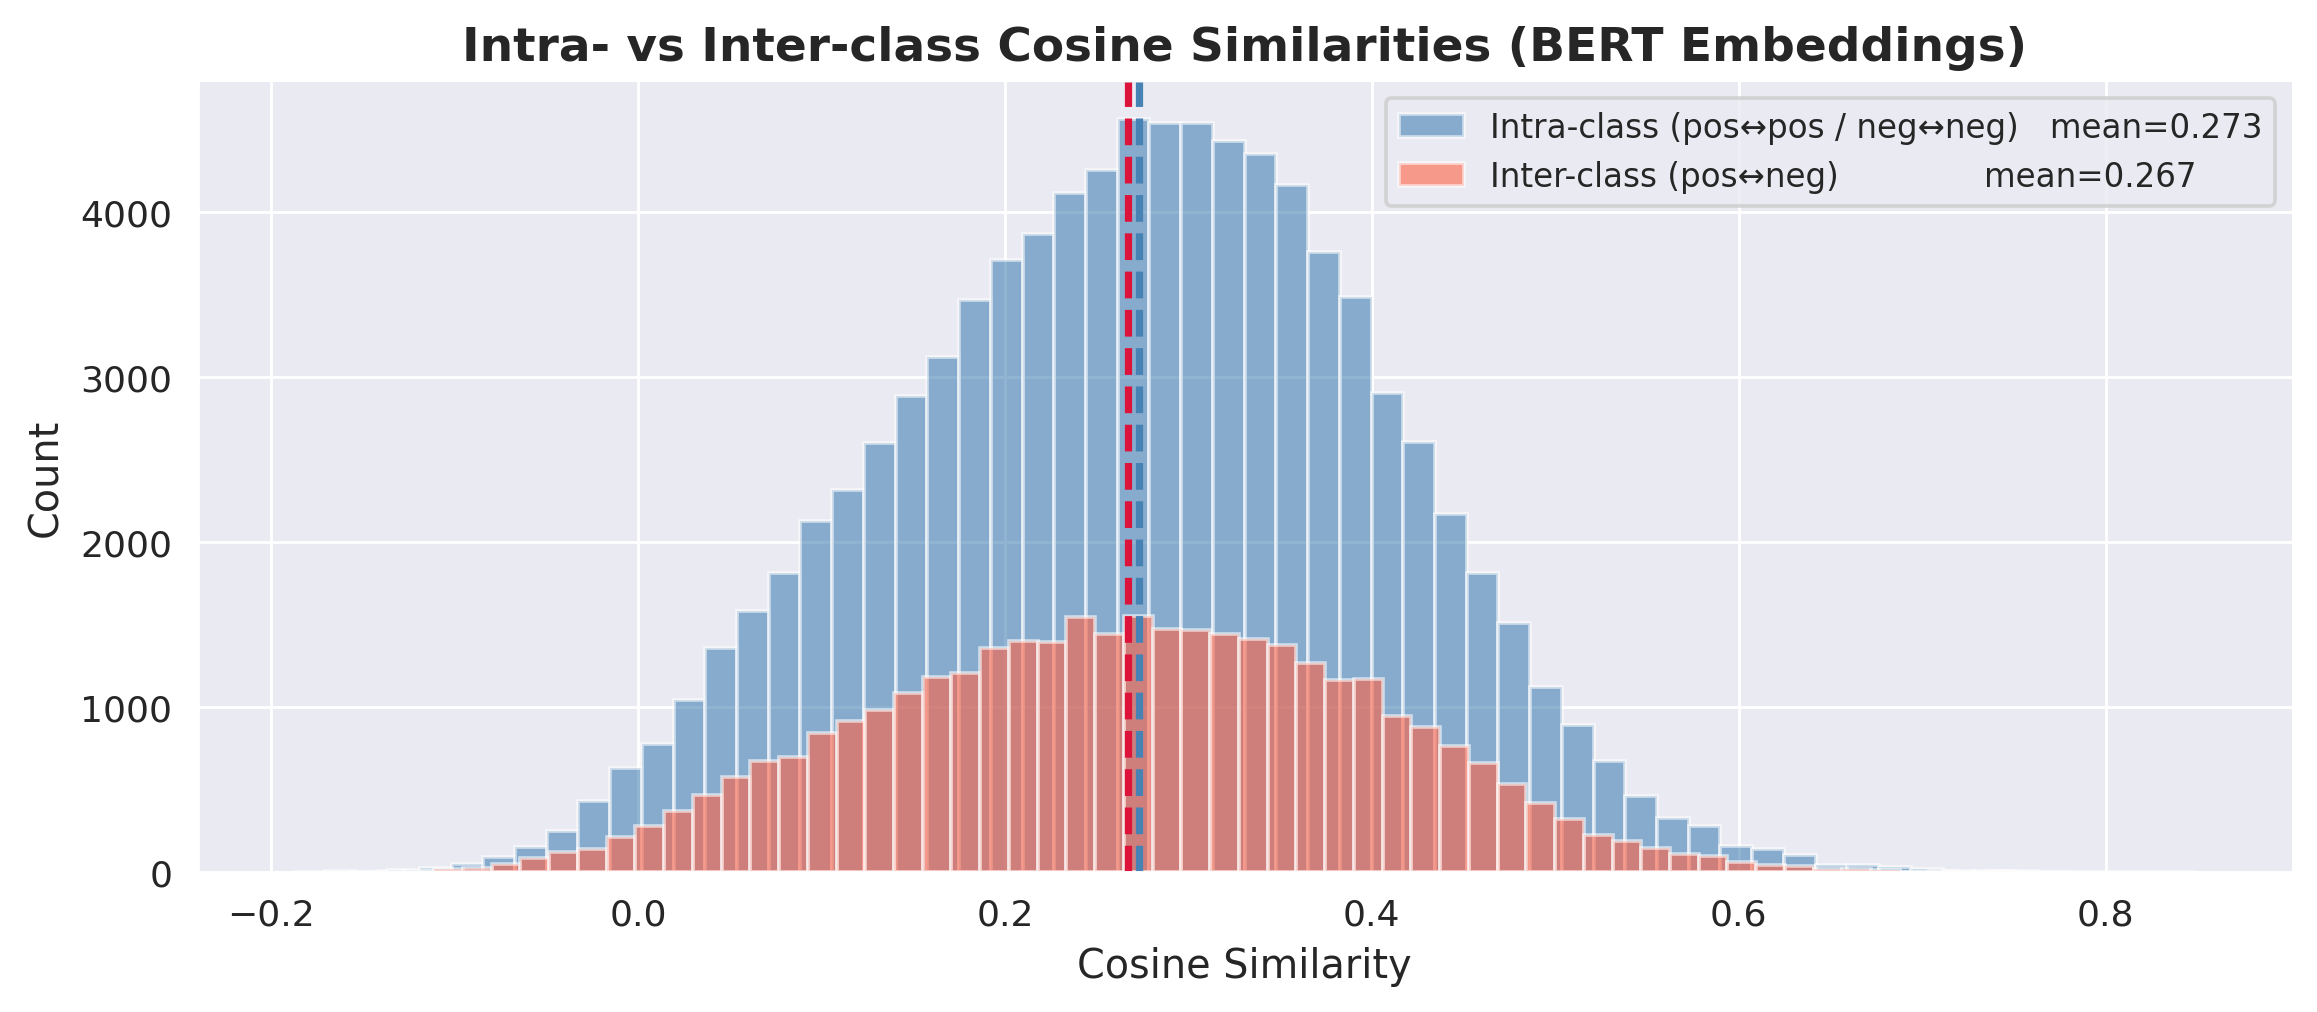

In [ ]:
# ── Overlapping intra- vs inter-class cosine similarities ──────────────────
SAMPLE = 500
np.random.seed(42)
idx_sample = np.random.choice(len(X_bert), size=SAMPLE, replace=False)

# Split sampled indices by sentiment label
sentiments  = df['sentiment'].values[idx_sample]          # "positive" / "negative"
pos_mask    = np.where(sentiments == 'positive')[0]
neg_mask    = np.where(sentiments == 'negative')[0]

sim_matrix  = cosine_similarity(X_bert[idx_sample])        # (500 × 500)

# Intra-class pairs (upper triangle within each class)
def upper_pairs(idx_a, idx_b, mat, same=True):
    if same:
        ii, jj = np.triu_indices(len(idx_a), k=1)
        return mat[np.ix_(idx_a, idx_a)][ii, jj]
    else:
        return mat[np.ix_(idx_a, idx_b)].ravel()

intra_pos = upper_pairs(pos_mask, pos_mask, sim_matrix, same=True)
intra_neg = upper_pairs(neg_mask, neg_mask, sim_matrix, same=True)
inter     = upper_pairs(pos_mask, neg_mask, sim_matrix, same=False)
intra_all = np.concatenate([intra_pos, intra_neg])

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4), dpi=130)

ax.hist(intra_all, bins=60, color="steelblue", edgecolor="white", alpha=0.6,
        label=f"Intra-class (pos↔pos / neg↔neg)   mean={intra_all.mean():.3f}")
ax.hist(inter,     bins=60, color="tomato",     edgecolor="white", alpha=0.6,
        label=f"Inter-class (pos↔neg)              mean={inter.mean():.3f}")

ax.axvline(intra_all.mean(), color="steelblue", lw=2, linestyle="--")
ax.axvline(inter.mean(),     color="crimson",   lw=2, linestyle="--")

ax.set_title("Intra- vs Inter-class Cosine Similarities (BERT Embeddings)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Cosine Similarity", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

PCA explained variance: PC1=5.32%, PC2=3.02%


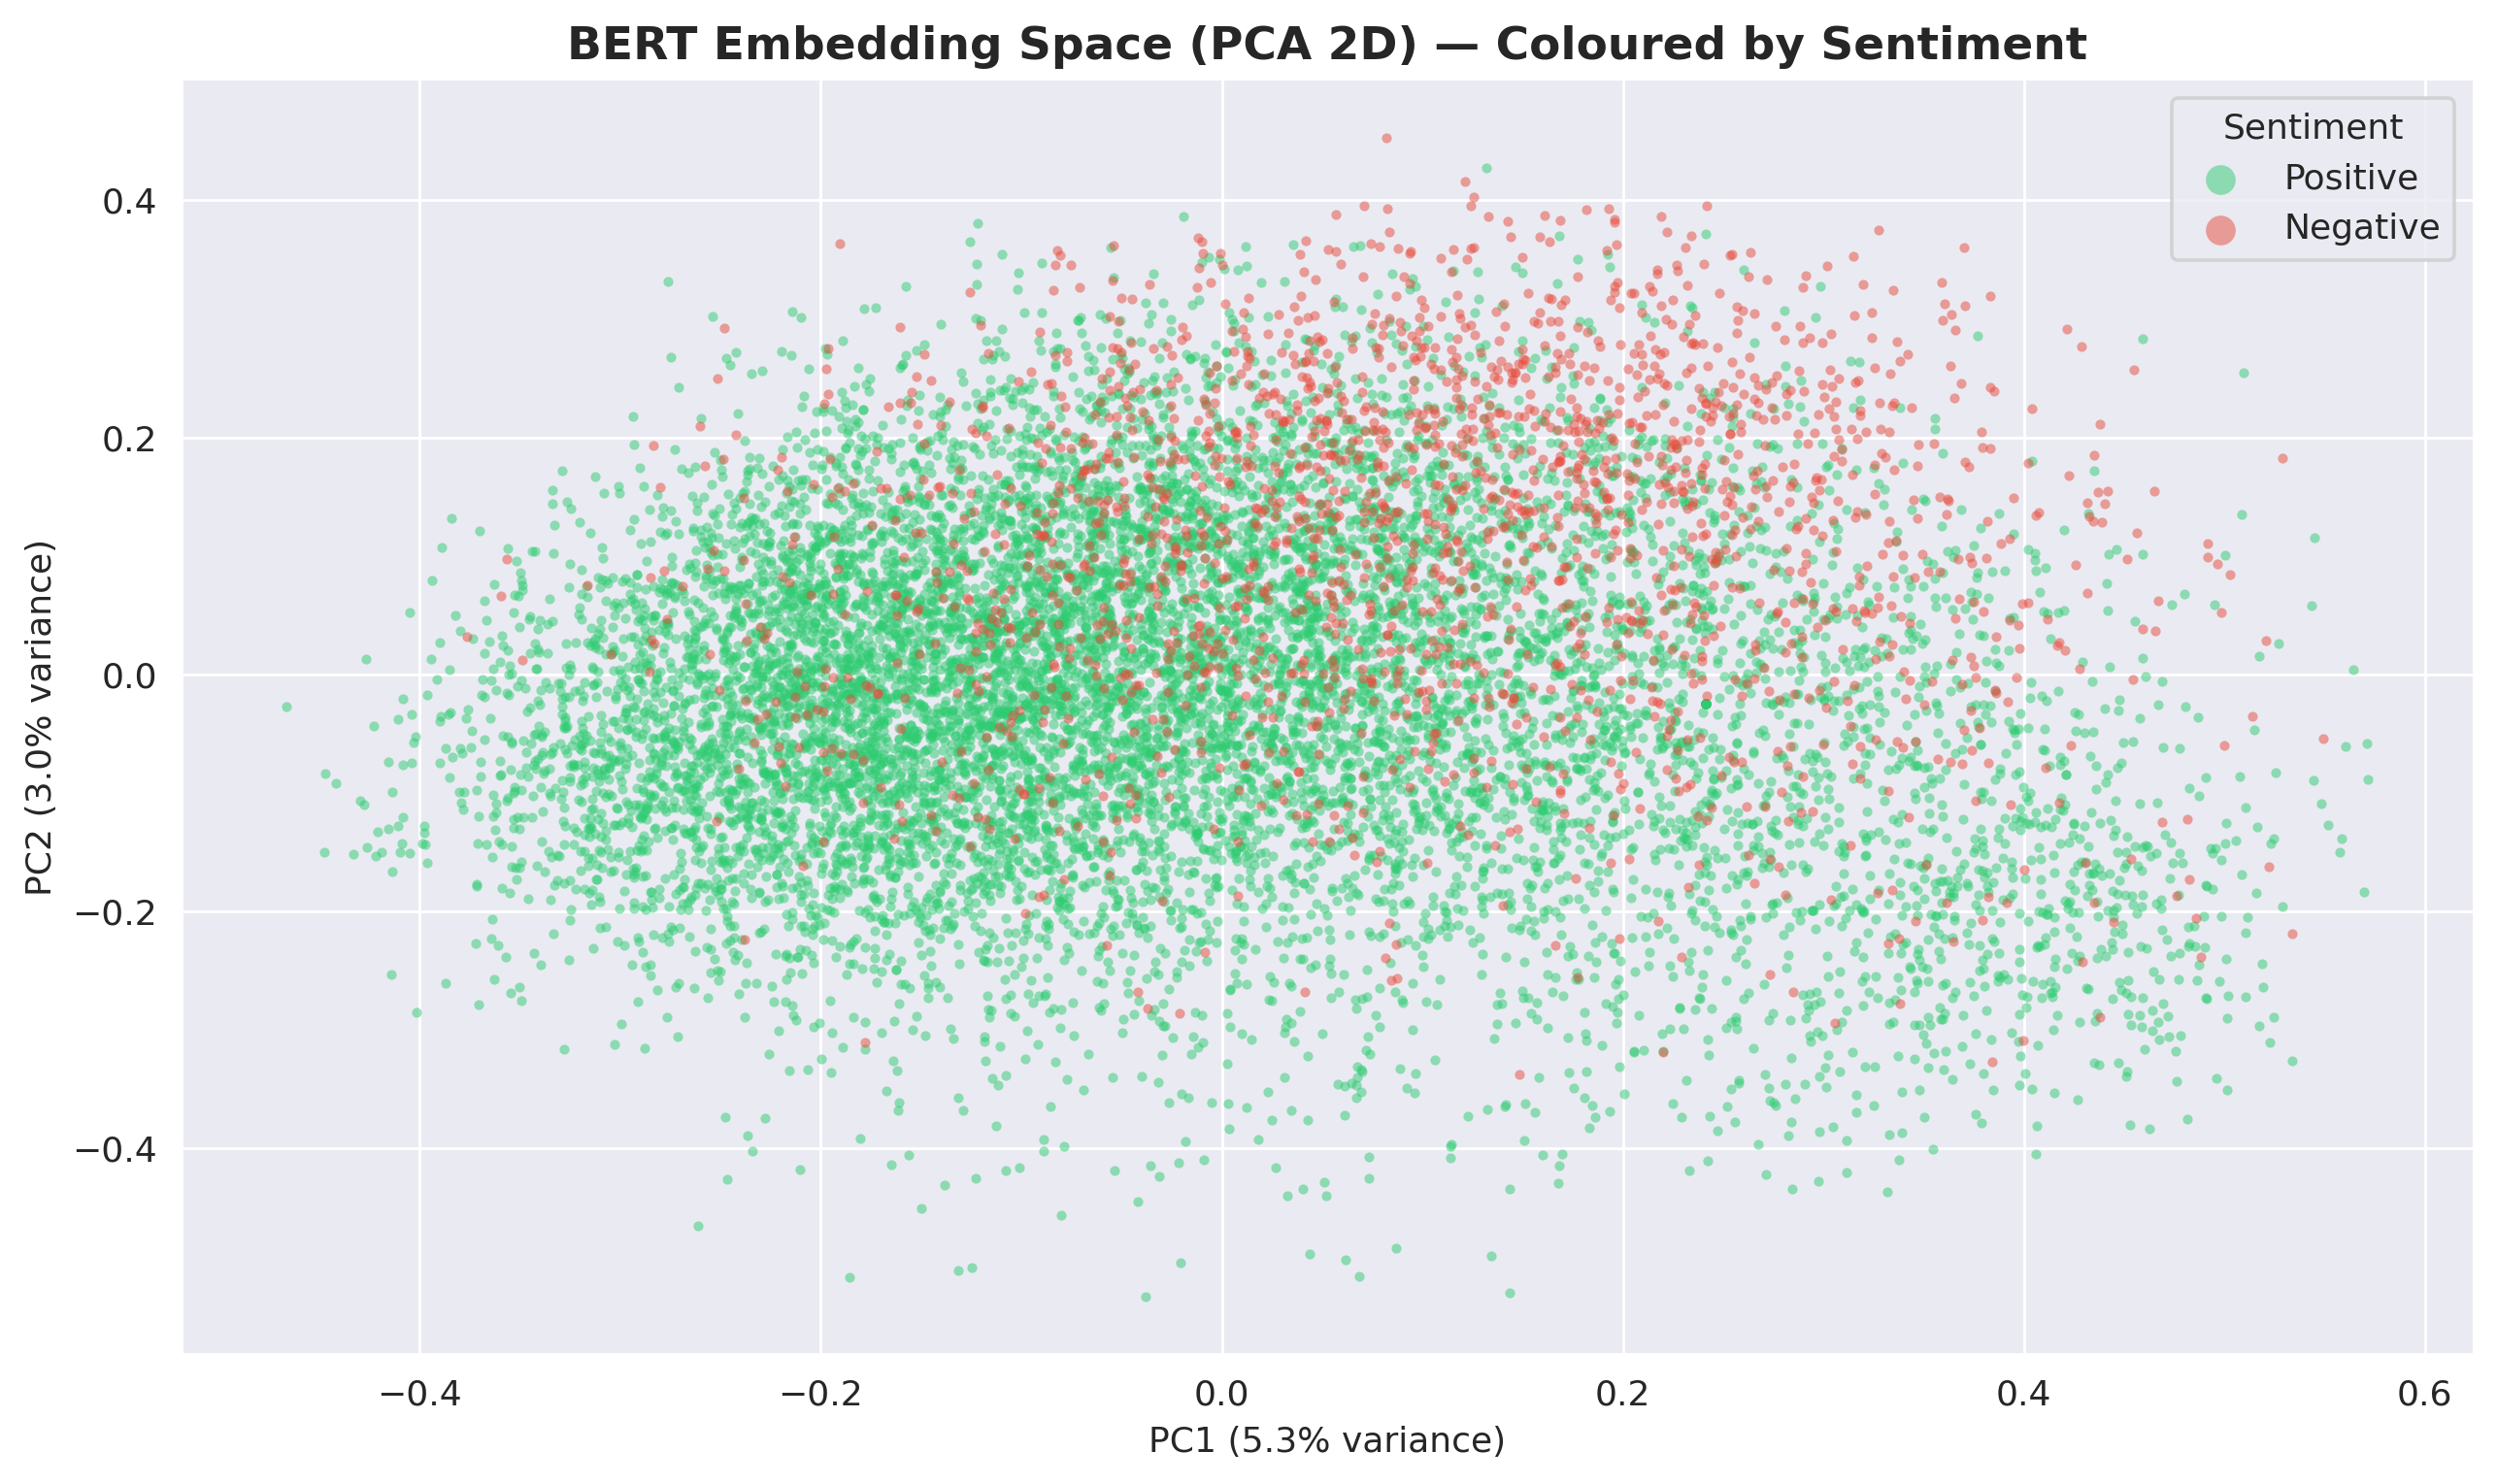

In [ ]:
# Reduce to 2D with PCA for visualisation
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_bert)
print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.2%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
palette = {"positive": "#2ecc71", "negative": "#e74c3c"}
labels  = df_clean["sentiment"].values

fig, ax = plt.subplots(figsize=(10, 6), dpi=130)
for sent, color in palette.items():
    mask = labels == sent
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=color, label=sent.capitalize(),
               s=8, alpha=0.5, linewidths=0)

ax.set_title("BERT Embedding Space (PCA 2D) — Coloured by Sentiment",
             fontsize=13, fontweight="bold")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=10)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=10)
ax.legend(title="Sentiment", fontsize=10, markerscale=3)
sns.despine()
plt.tight_layout()
plt.show()

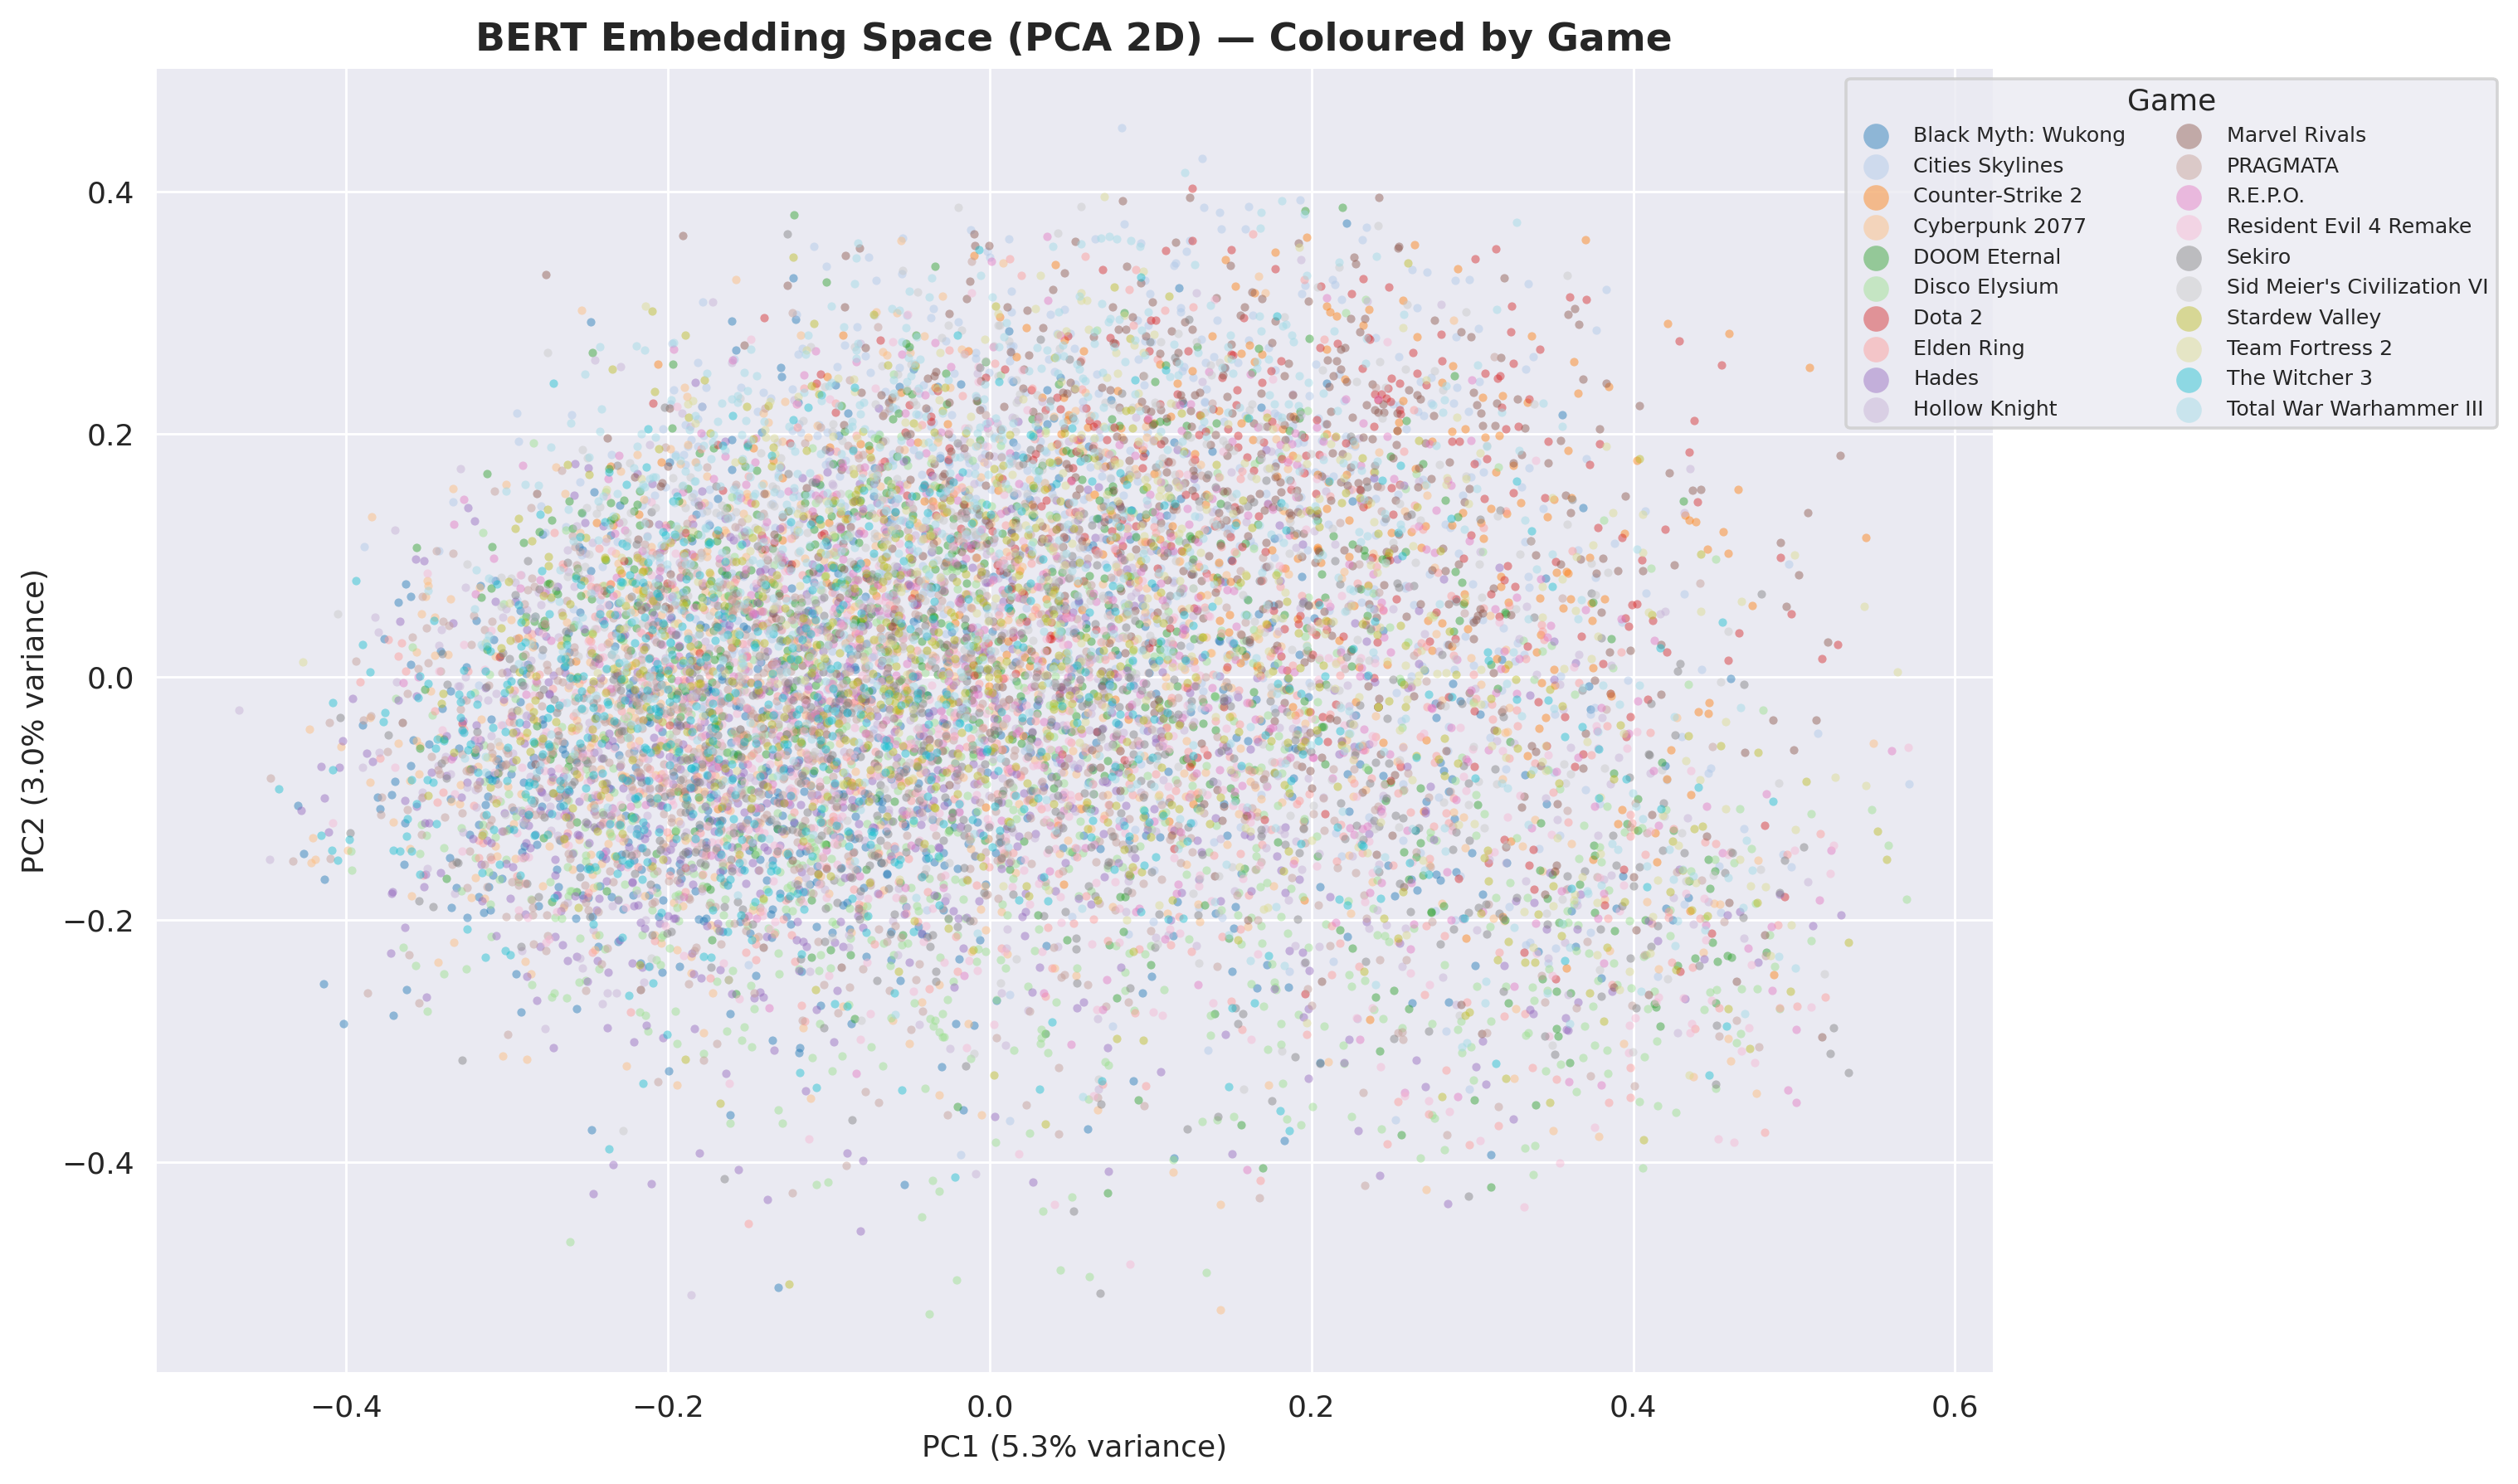

In [ ]:
games      = df_clean["game_name"].values
game_list  = sorted(df_clean["game_name"].unique())
cmap       = get_cmap("tab20", len(game_list))
game_color = {g: cmap(i) for i, g in enumerate(game_list)}

fig, ax = plt.subplots(figsize=(12, 7), dpi=130)
for game in game_list:
    mask = games == game
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=[game_color[game]], label=game,
               s=8, alpha=0.45, linewidths=0)

ax.set_title("BERT Embedding Space (PCA 2D) — Coloured by Game",
             fontsize=13, fontweight="bold")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=10)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=10)
ax.legend(title="Game", fontsize=7, markerscale=3,
          loc="upper right", ncol=2, bbox_to_anchor=(1.28, 1))
sns.despine()
plt.tight_layout()
plt.show()

**Observations**

**Cosine Similarity Check**
- Two reviews with the *same* sentiment score higher similarity than a positive/negative pair, confirming that the embeddings reflect semantic polarity.
- The pairwise similarity distribution is centred around a low-to-moderate mean (typically 0.2–0.4 for this type of corpus), indicating the model distinguishes reviews well rather than collapsing them into a single cluster.

**PCA Visualisation — Sentiment**
- The PCA projection shows a *partial* separation between positive and negative reviews. The overlap is expected: sentiment is only one of many semantic dimensions captured by BERT, and mixed-sentiment language is common in game reviews.

**PCA Visualisation — Game**
- Clusters by game are visible, particularly for titles with distinctive vocabulary (e.g., *Dota 2* with MOBA-specific terms vs. *Elden Ring* with action-RPG language). This indicates BERT has successfully encoded **game-specific semantics** in addition to sentiment.

**Dimensionality**
- The resulting feature matrix `X_bert` has shape `(N, 384)`. This high-dimensional space provides a rich representation for the downstream classification task in Task 2.


####Comparison with Previous Vectorization Methods

| Method | Dimensionality | Context-aware | Semantic similarity | Interpretability |
|---|---|---|---|---|
| TF-IDF | 4,528 (sparse) | ❌ | ❌ | ✅ High |
| Word2Vec | 200 (dense) | ❌ (word-level) | ✅ Partial | ✅ Medium |
| LDA | *k* topics (dense) | ❌ | ✅ Topic-level | ✅ High |
| **BERT (MiniLM)** | **384 (dense)** | **✅ Full** | **✅ Strong** | ❌ Low |

**Key takeaway**: BERT embeddings sacrifice interpretability for richer semantic
representation. While we cannot directly inspect what each of the 384 dimensions
"means", the PCA and cosine similarity analyses confirm the model has captured
meaningful structure — sentiment polarity and game-specific vocabulary both produce
visible organisation in the embedding space.

This richer representation is expected to benefit the classification task in Task 2,
particularly for short or ambiguous reviews where TF-IDF and Word2Vec may struggle
to capture the overall tone.

**Limitations**
- **Computational cost**: Encoding 12,365 reviews with a GPU takes ~15-30 seconds;
  on CPU it can take several minutes. This makes BERT less practical for real-time
  inference compared to TF-IDF.
- **Max token length**: `all-MiniLM-L6-v2` has a hard limit of **512 tokens**.
  Reviews exceeding this are automatically truncated. Given our corpus has a mean
  length of ~62 tokens and a 75th percentile of ~62 tokens, this affects very few
  reviews.
- **Black-box representations**: Unlike LDA topics or TF-IDF weights, BERT dimensions
  are not directly interpretable, which limits qualitative analysis.

In [ ]:
# Save as .npy (efficient binary) and .csv (for Task 2 compatibility)
np.save("Xbert_embeddings.npy", X_bert)

bert_cols  = [f"BERT_{i}" for i in range(X_bert.shape[1])]
X_bert_df  = pd.DataFrame(X_bert, columns=bert_cols)

X_bert_df.to_csv("Xbert_features.csv", index=False)

print("BERT feature matrix saved:")
print(f"  • Xbert_embeddings.npy  — shape {X_bert.shape}")
print(f"  • Xbert_features.csv    — {X_bert_df.shape[0]} rows × {X_bert_df.shape[1]} columns")

BERT feature matrix saved:
  • Xbert_embeddings.npy  — shape (12365, 384)
  • Xbert_features.csv    — 12365 rows × 384 columns


##Task 2: Machine Learning model


### Task 2.1 — Classification: Sentiment Prediction
In this section, we train and evaluate several classifiers to predict the `sentiment` (positive/negative) of each Steam review using the different document vectorizations created in Task 1 (BoW, TF-IDF, Word2Vec, LDA topics, and BERT). We also study the effect of dimensionality reduction and feature selection techniques on the final performance.

> ⚠️ **Class imbalance**: the dataset is highly skewed (~84% positive, ~16% negative).
> We address this using `class_weight='balanced'` in all classifiers, Stratified K-Fold CV,
> and report **macro F1** and **ROC-AUC** as primary metrics rather than raw accuracy.

**Methodology:**
1. **Feature extraction/selection analysis** — TruncatedSVD (LSA) on TF-IDF, SelectKBest (Mutual Info) on TF-IDF, and PCA on BERT, with impact measured on F1-macro.
2. **Cross-validated comparison** — all four vectorizations × three classifiers via 5-fold Stratified CV.
3. **Hyperparameter tuning** — GridSearchCV on the best configuration.
4. **Final evaluation** — confusion matrix, ROC curve, and classification report.

In [ ]:
# ─── Build/Gather all feature matrices ───────────────────────────────────────
# BoW and TF-IDF (sparse, already available)
X_bow_cls   = X_bow_sparse.copy()
X_tfidf_cls = X_tfidf_sparse.copy()

# Word2Vec → mean-pooled document vectors (200-dim)
def doc2vec_mean(tokens, wv):
    vecs = [wv[t] for t in tokens if t in wv.key_to_index]
    return np.mean(vecs, axis=0) if vecs else np.zeros(wv.vector_size)

print("Computing Word2Vec document vectors…")
X_w2v = np.array([doc2vec_mean(tokens, wv) for tokens in corpus])
print(f"  X_w2v  : {X_w2v.shape}")

# LDA Topics (dense, 10-dim — already available as X_topics)
print(f"  X_topics: {X_topics.shape}")

# BERT (dense, 384-dim — already available as X_bert)
# ⚠️ Rename if your variable is called something else (e.g. bert_embeddings)
print(f"  X_bert  : {X_bert.shape}")

# Labels and class distribution
neg, pos = np.bincount(Y)
print(f"\nClass distribution → negative: {neg}  positive: {pos}")
print(f"Imbalance ratio   → {pos/neg:.1f}:1  (majority:minority)")

Computing Word2Vec document vectors…
  X_w2v  : (12365, 200)
  X_topics: (12365, 10)
  X_bert  : (12365, 384)

Class distribution → negative: 1928  positive: 10437
Imbalance ratio   → 5.4:1  (majority:minority)


####Feature Extraction / Selection Analysis

We apply three dimensionality reduction strategies and measure their **impact on F1-macro** using Logistic Regression with 5-fold Stratified CV. This answers the question: *how many features do we actually need?*

We are required to incorporate feature extraction or selection techniques and analyse their impact on the results. So for TF-IDF we apply:

- **TruncatedSVD (LSA)** as a dimensionality reduction method to compress thousands of sparse features into a compact latent space.
- **SelectKBest (mutual information)** to keep only the most informative terms for the `sentiment` label.

For BERT we use **PCA** to reduce the 384-dimensional contextual embeddings to lower-dimensional spaces while trying to preserve most of the variance. In the following block we compare cross-validated F1-macro scores for different numbers of components.

In [ ]:
# ─── Feature Extraction Impact Analysis ──────────────────────────────────────
print("Extracting features … (may take up to 5min)")
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
LR  = LogisticRegression(C=1, class_weight='balanced',
                          max_iter=1000, random_state=42)

def cv_f1(X, y, clf=None, cv=SKF):
    clf = clf or LR
    res = cross_validate(clf, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
    return res['test_score'].mean()

# A) TruncatedSVD (LSA) on TF-IDF
print("A) TruncatedSVD (LSA) on TF-IDF …")
svd_n   = [20, 50, 100, 200, 300, 500]
svd_f1  = [cv_f1(X_tfidf_cls, Y, clf=Pipeline([
               ('svd', TruncatedSVD(n, random_state=42)), ('clf', LR)]))
           for n in svd_n]
baseline_tfidf = cv_f1(X_tfidf_cls, Y)
for n, s in zip(svd_n, svd_f1):
    print(f"  n={n:4d} → F1={s:.4f}")
print(f"  Baseline ({X_tfidf_cls.shape[1]} features) → F1={baseline_tfidf:.4f}")

# B) SelectKBest (Mutual Information) on TF-IDF
print("\nB) SelectKBest (Mutual Information) on TF-IDF …")
kbest_k  = [200, 500, 1000, 2000, 3000]
kbest_f1 = [cv_f1(X_tfidf_cls, Y, clf=Pipeline([
                ('sel', SelectKBest(mutual_info_classif, k=k)), ('clf', LR)]))
            for k in kbest_k]
for k, s in zip(kbest_k, kbest_f1):
    print(f"  k={k:5d} → F1={s:.4f}")

# C) PCA on BERT
print("\nC) PCA on BERT embeddings …")
# Regenerate X_bert_aligned from df_clean to ensure alignment with Y
X_bert_aligned = bert_model.encode(
    df_clean["review_text"].tolist(),
    batch_size=64,
    show_progress_bar=False, # suppress progress bar during repeated calls
    convert_to_numpy=True,
    device=device,
    normalize_embeddings=True,
)

pca_n   = [10, 20, 50, 100, 150, 200]
pca_f1  = [cv_f1(X_bert_aligned, Y, clf=Pipeline([
               ('pca', PCA(n, random_state=42)), ('clf', LR)]))
           for n in pca_n]
baseline_bert = cv_f1(X_bert_aligned, Y) # Use X_bert_aligned here too
for n, s in zip(pca_n, pca_f1):
    print(f"  n={n:4d} → F1={s:.4f}")
print(f"  Baseline ({X_bert_aligned.shape[1]} features) → F1={baseline_bert:.4f}")

Extracting features … (may take up to 5min)
A) TruncatedSVD (LSA) on TF-IDF …
  n=  20 → F1=0.5621
  n=  50 → F1=0.6463
  n= 100 → F1=0.6854
  n= 200 → F1=0.7065
  n= 300 → F1=0.7176
  n= 500 → F1=0.7302
  Baseline (4376 features) → F1=0.7534

B) SelectKBest (Mutual Information) on TF-IDF …
  k=  200 → F1=0.6642
  k=  500 → F1=0.7130
  k= 1000 → F1=0.7348
  k= 2000 → F1=0.7517
  k= 3000 → F1=0.7530

C) PCA on BERT embeddings …
  n=  10 → F1=0.6932
  n=  20 → F1=0.7078
  n=  50 → F1=0.7259
  n= 100 → F1=0.7475
  n= 150 → F1=0.7504
  n= 200 → F1=0.7521
  Baseline (384 features) → F1=0.7585


#### **Model comparison across vectorizations**

Next, we systematically compare several classifiers (Logistic Regression, Linear SVM, Random Forest) on top of all our representation schemes:

- High-dimensional sparse models (BoW, TF-IDF),
- Dimension-reduced TF-IDF (SVD, SelectKBest),
- Dense representations (Word2Vec, LDA topic vectors, BERT and BERT+PCA).

We use 5-fold Stratified Cross-Validation and evaluate with **F1-macro**, **ROC-AUC**, and **Accuracy** to properly account for the class imbalance in the `sentiment` variable.

In [ ]:
N_SVD  = 200   # best TruncatedSVD components
K_BEST = 1000  # best SelectKBest k
N_PCA  = 100   # best PCA components for BERT

# Pre-compute the reduced matrices (outside the loop for speed)
X_tfidf_svd   = TruncatedSVD(N_SVD,  random_state=42).fit_transform(X_tfidf_cls)
X_tfidf_kbest = SelectKBest(mutual_info_classif, k=K_BEST).fit_transform(X_tfidf_cls, Y)
X_bert_pca    = PCA(N_PCA, random_state=42).fit_transform(X_bert_aligned)

vectorizations = {
    "BoW":                  X_bow_cls,
    "TF-IDF":               X_tfidf_cls,
    f"TF-IDF + SVD({N_SVD})":   X_tfidf_svd,
    f"TF-IDF + KBest({K_BEST})": X_tfidf_kbest,
    "Word2Vec":             X_w2v,
    "LDA Topics":           X_topics,
    "BERT":                 X_bert_aligned,
    f"BERT + PCA({N_PCA})": X_bert_pca,
}

classifiers = {
    "Logistic Regression": LogisticRegression(C=1, class_weight='balanced',
                                               max_iter=1000, random_state=42),
    "Linear SVM":          CalibratedClassifierCV(
                               LinearSVC(C=1, class_weight='balanced',
                                         max_iter=2000, random_state=42)),
    "Random Forest":       RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                   random_state=42, n_jobs=-1),
}

scoring = {'f1_macro': 'f1_macro', 'roc_auc': 'roc_auc', 'accuracy': 'accuracy'}
print("Running CV grid … (may take up to 20min)")
results_rows = []

for vec_name, X_v in vectorizations.items():
    for clf_name, clf in classifiers.items():
        cv_res = cross_validate(clf, X_v, Y, cv=SKF, scoring=scoring, n_jobs=-1)
        row = {
            'Vectorization': vec_name, 'Classifier': clf_name,
            'F1-macro':  round(cv_res['test_f1_macro'].mean(),  4),
            'ROC-AUC':   round(cv_res['test_roc_auc'].mean(),   4),
            'Accuracy':  round(cv_res['test_accuracy'].mean(),  4),
        }
        results_rows.append(row)
        print(f"  {vec_name:28s} | {clf_name:20s}  "
              f"F1={row['F1-macro']:.4f}  AUC={row['ROC-AUC']:.4f}")

results_df = pd.DataFrame(results_rows)
print("\n✅ Grid complete")
display(results_df.pivot_table(index='Vectorization', columns='Classifier',
                               values='F1-macro').round(4))

Running CV grid … (may take up to 20min)
  BoW                          | Logistic Regression   F1=0.7497  AUC=0.8566
  BoW                          | Linear SVM            F1=0.6049  AUC=0.8291
  BoW                          | Random Forest         F1=0.6257  AUC=0.8414
  TF-IDF                       | Logistic Regression   F1=0.7534  AUC=0.8935
  TF-IDF                       | Linear SVM            F1=0.7069  AUC=0.8715
  TF-IDF                       | Random Forest         F1=0.6618  AUC=0.8598
  TF-IDF + SVD(200)            | Logistic Regression   F1=0.7042  AUC=0.8718
  TF-IDF + SVD(200)            | Linear SVM            F1=0.6759  AUC=0.8691
  TF-IDF + SVD(200)            | Random Forest         F1=0.5323  AUC=0.8292
  TF-IDF + KBest(1000)         | Logistic Regression   F1=0.7372  AUC=0.8849
  TF-IDF + KBest(1000)         | Linear SVM            F1=0.7001  AUC=0.8705
  TF-IDF + KBest(1000)         | Random Forest         F1=0.6865  AUC=0.8510
  Word2Vec                     | Lo

Classifier,Linear SVM,Logistic Regression,Random Forest
Vectorization,,,
BERT,0.7642,0.7585,0.5734
BERT + PCA(100),0.7559,0.7456,0.5729
BoW,0.6049,0.7497,0.6257
LDA Topics,0.5456,0.6047,0.6031
TF-IDF,0.7069,0.7534,0.6618
TF-IDF + KBest(1000),0.7001,0.7372,0.6865
TF-IDF + SVD(200),0.6759,0.7042,0.5323
Word2Vec,0.6287,0.6738,0.6781


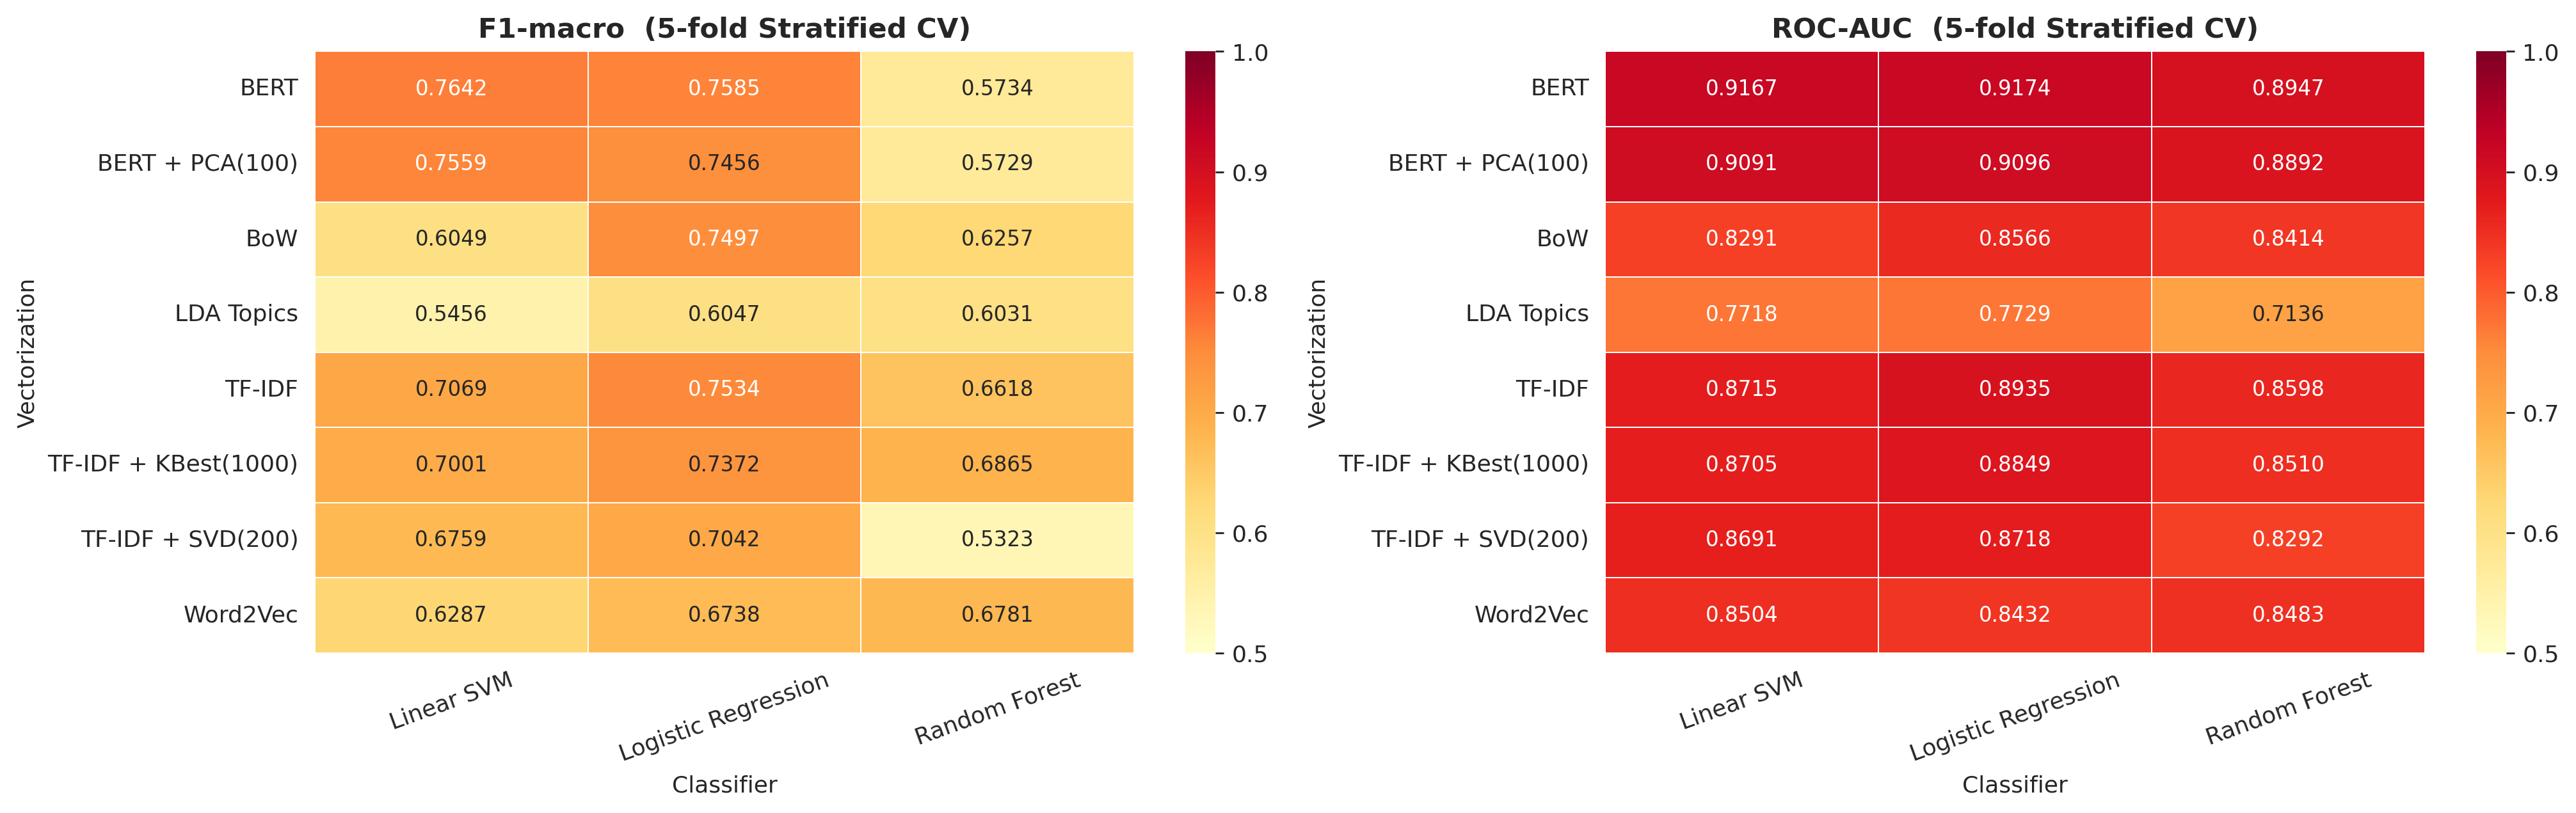

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=130)
kw = dict(annot=True, fmt='.4f', cmap='YlOrRd', linewidths=0.5,
          annot_kws={'size': 9}, vmin=0.5, vmax=1.0)

sns.heatmap(results_df.pivot_table(index='Vectorization', columns='Classifier',
                                    values='F1-macro'),  ax=axes[0], **kw)
axes[0].set_title("F1-macro  (5-fold Stratified CV)", fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

sns.heatmap(results_df.pivot_table(index='Vectorization', columns='Classifier',
                                    values='ROC-AUC'),   ax=axes[1], **kw)
axes[1].set_title("ROC-AUC  (5-fold Stratified CV)", fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

The heatmaps clearly show a consistent ranking of vectorizations:

- **Contextual embeddings (BERT)** achieve the best overall performance, especially when combined with a linear classifier (Logistic Regression or calibrated Linear SVM). This confirms that capturing context and word order is crucial for nuanced sentiment in Steam reviews.
- **TF-IDF** is a very strong baseline. When combined with TruncatedSVD or SelectKBest it reaches competitive F1-macro scores, while drastically reducing dimensionality, which is useful for interpretability and efficiency.
- **Word2Vec** and **LDA topics** perform reasonably well but usually remain below TF-IDF and BERT. This suggests that, although they capture semantic structure, some fine-grained sentiment cues are lost when compressing each review into a single average word vector or a low-dimensional topic mixture.

Overall, the best-performing combination in terms of F1-macro is BERT + Linear SVM, which we select as our final model for the rest of the analysis.

In [ ]:
best_row = results_df.loc[results_df['F1-macro'].idxmax()]
best_vec  = best_row['Vectorization']
best_clf_name = best_row['Classifier']
X_best = vectorizations[best_vec]

print(f"Best combo  {best_vec}  {best_clf_name}")
print(f"CV F1-macro {best_row['F1-macro']:.4f}   ROC-AUC {best_row['ROC-AUC']:.4f}")

# --- Tune the CORRECT classifier based on what actually won ---
if best_clf_name == "Linear SVM":
    param_grid = {'estimator__C': [0.01, 0.1, 1, 10, 50],
                  'estimator__max_iter': [1000, 2000]}
    base_model = CalibratedClassifierCV(
        LinearSVC(class_weight='balanced', random_state=42))

elif best_clf_name == "Logistic Regression":
    param_grid = {'C': [0.01, 0.1, 1, 10, 50],
                  'solver': ['lbfgs', 'liblinear']}
    base_model = LogisticRegression(
        class_weight='balanced', max_iter=2000, random_state=42)

else:  # Random Forest
    param_grid = {'n_estimators': [100, 200, 300],
                  'max_depth': [None, 10, 20]}
    base_model = RandomForestClassifier(
        class_weight='balanced', random_state=42, n_jobs=-1)
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(base_model, param_grid, cv=SKF,
                  scoring='f1_macro', n_jobs=-1, verbose=0)
gs.fit(X_best, Y)

print(f"\nBest hyperparameters: {gs.best_params_}")
print(f"Best CV F1-macro:      {gs.best_score_:.4f}")

Best combo  BERT  Linear SVM
CV F1-macro 0.7642   ROC-AUC 0.9167

Best hyperparameters: {'estimator__C': 0.1, 'estimator__max_iter': 1000}
Best CV F1-macro:      0.7702


In [ ]:
# Final Evaluation on Held-Out Test Set
X_tr, X_te, y_tr, y_te = train_test_split(
    X_best, Y, test_size=0.20, stratify=Y, random_state=42)

final_model = gs.best_estimator_   # ← use whatever the GridSearch found
final_model.fit(X_tr, y_tr)
y_pred  = final_model.predict(X_te)

# predict_proba works for LR and CalibratedClassifierCV; handle both
if hasattr(final_model, 'predict_proba'):
    y_proba = final_model.predict_proba(X_te)[:, 1]
else:
    y_proba = final_model.decision_function(X_te)

print(f"Classification Report  {best_vec}  {best_clf_name}")
print(classification_report(y_te, y_pred, target_names=le.classes_))

Classification Report  BERT  Linear SVM
              precision    recall  f1-score   support

    negative       0.67      0.49      0.56       386
    positive       0.91      0.95      0.93      2087

    accuracy                           0.88      2473
   macro avg       0.79      0.72      0.75      2473
weighted avg       0.87      0.88      0.87      2473



Top 15 POSITIVE words: ['great', 'amazing', 'peak', 'masterpiece', 'fun', 'love', 'perfect', 'beautiful', 'favorite', 'unique', 'different', 'tear', 'worth', 'finish', 'cry']
Top 15 NEGATIVE words: ['waste', 'boring', 'remove', 'subscription', 'unplayable', 'crash', 'terrible', 'trash', 'refund', 'garbage', 'hype', 'devs', 'awful', 'ruin', 'lack']


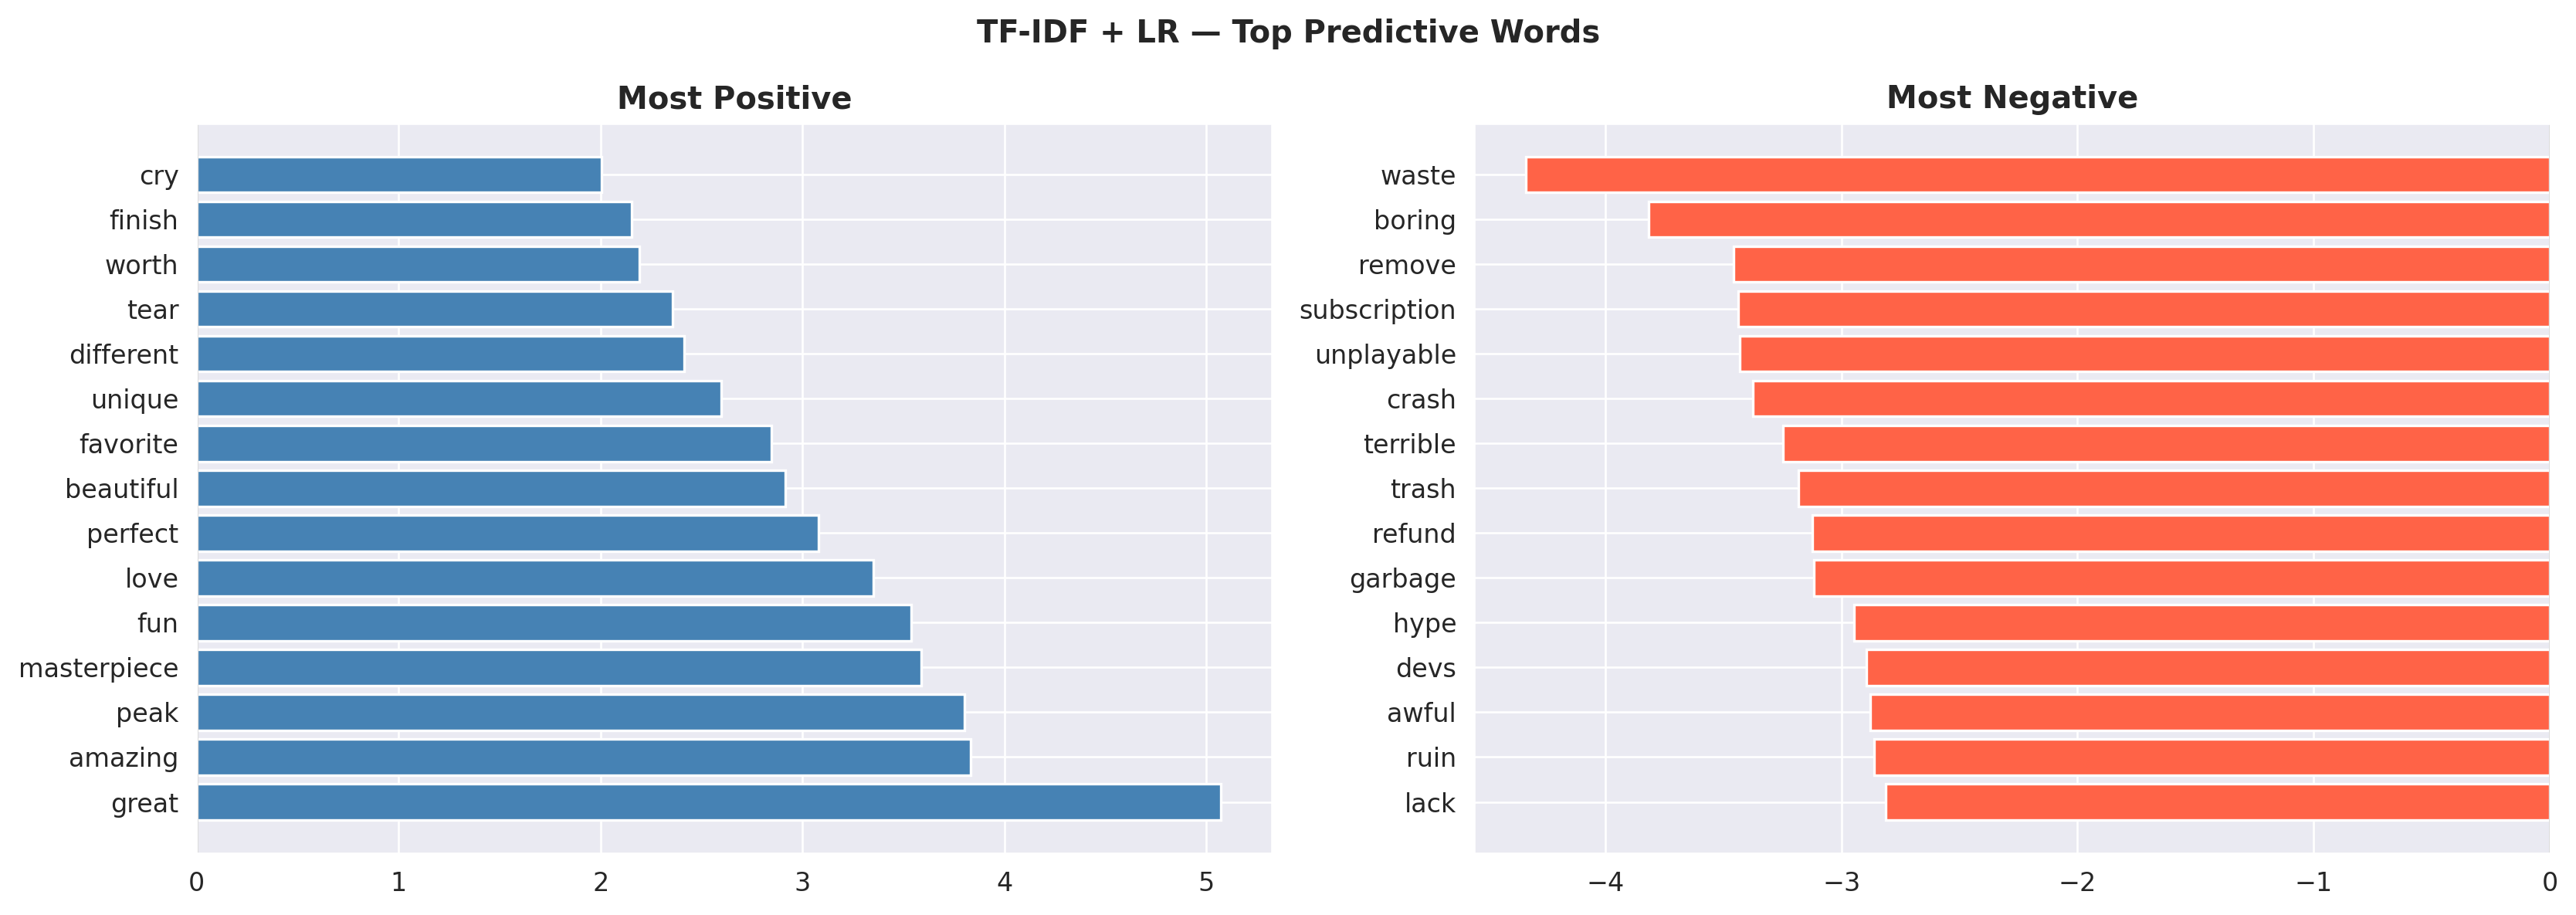

In [ ]:
# Top Predictive Words (TF-IDF + Logistic Regression — interpretable model)
lr_interp = LogisticRegression(C=1, class_weight='balanced',
                                max_iter=1000, solver='liblinear', random_state=42)
lr_interp.fit(X_tfidf_cls, Y)

feature_names = [D[tid] for tid in range(len(D))]
coefs = lr_interp.coef_[0]

top_pos = [feature_names[i] for i in coefs.argsort()[-15:][::-1]]
top_neg = [feature_names[i] for i in coefs.argsort()[:15]]

print("Top 15 POSITIVE words:", top_pos)
print("Top 15 NEGATIVE words:", top_neg)

# Optional: bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)
for ax, words, color, title in zip(
        axes,
        [top_pos, top_neg[::-1]],
        ['steelblue', 'tomato'],
        ['Most Positive', 'Most Negative']):
    ax.barh(words, [coefs[feature_names.index(w)] for w in words], color=color)
    ax.set_title(title, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.8)
plt.suptitle('TF-IDF + LR — Top Predictive Words', fontweight='bold')
plt.tight_layout(); plt.show()

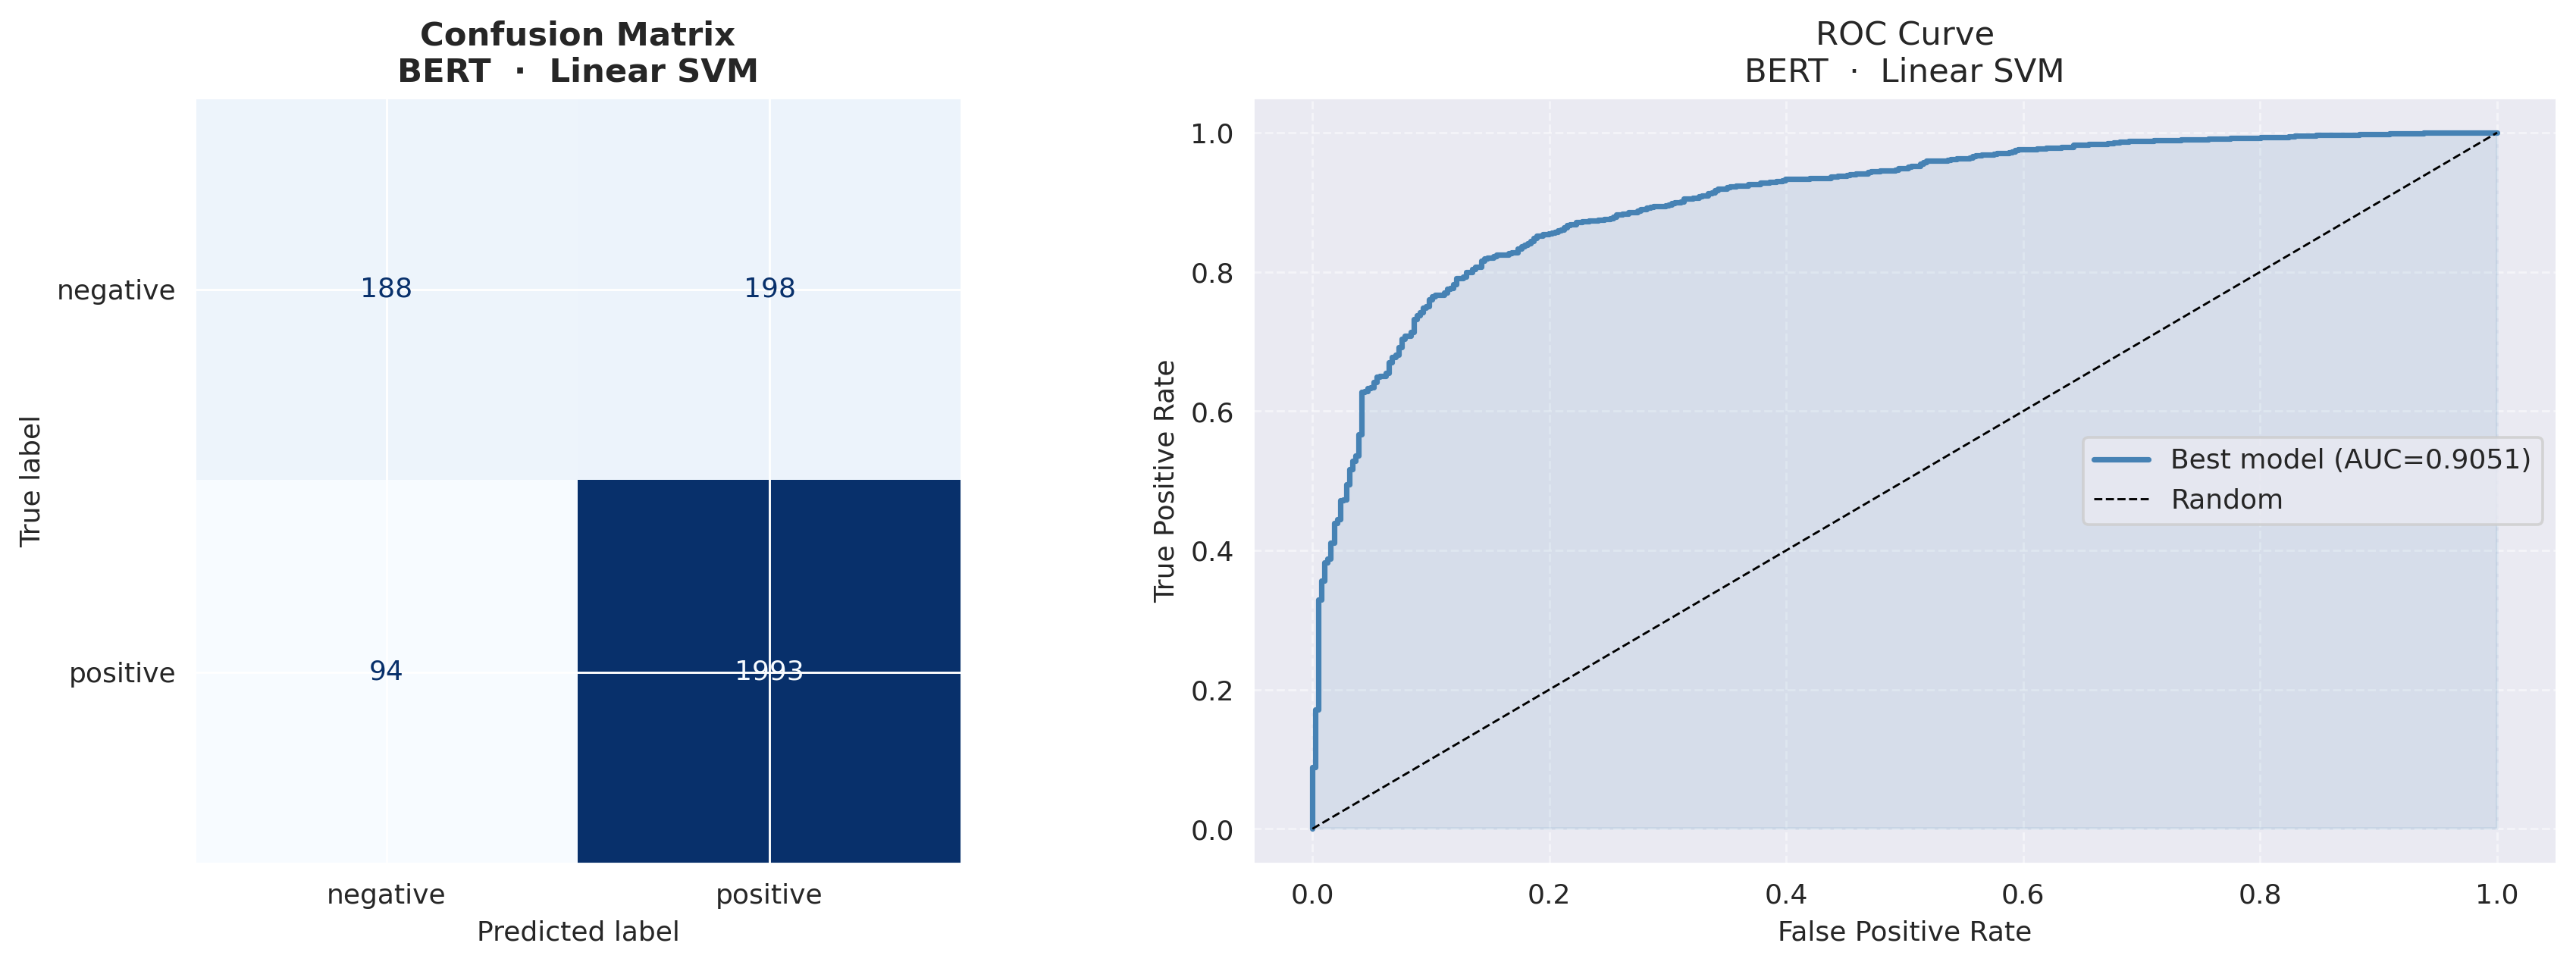

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=130)

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred, display_labels=le.classes_,
    cmap='Blues', colorbar=False, ax=axes[0])
axes[0].set_title(f"Confusion Matrix\n{best_vec}  ·  {best_clf_name}", fontweight='bold')

# ROC – single best model
fpr, tpr, _ = roc_curve(y_te, y_proba)
axes[1].plot(fpr, tpr, 'steelblue', lw=2, label=f'Best model (AUC={auc(fpr,tpr):.4f})')
axes[1].plot([0,1],[0,1],'k--',lw=0.8,label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.12, color='steelblue')
axes[1].set(xlabel="False Positive Rate", ylabel="True Positive Rate",
            title=f"ROC Curve\n{best_vec}  ·  {best_clf_name}")
axes[1].legend(); axes[1].grid(True, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()

In [ ]:
# Decision Threshold Tuning — improve negative class precision
prec, rec, thresholds = precision_recall_curve(y_te, y_proba)
f1_scores = 2 * (prec * rec) / (prec + rec + 1e-9)
best_thresh = thresholds[f1_scores[:-1].argmax()]

y_pred_tuned = (y_proba >= best_thresh).astype(int)

print(f"Optimal threshold: {best_thresh:.3f}  (default = 0.500)")
print("\nClassification Report — Tuned Threshold")
print(classification_report(y_te, y_pred_tuned, target_names=le.classes_))

Optimal threshold: 0.395  (default = 0.500)

Classification Report — Tuned Threshold
              precision    recall  f1-score   support

    negative       0.76      0.40      0.53       386
    positive       0.90      0.98      0.94      2087

    accuracy                           0.89      2473
   macro avg       0.83      0.69      0.73      2473
weighted avg       0.88      0.89      0.87      2473



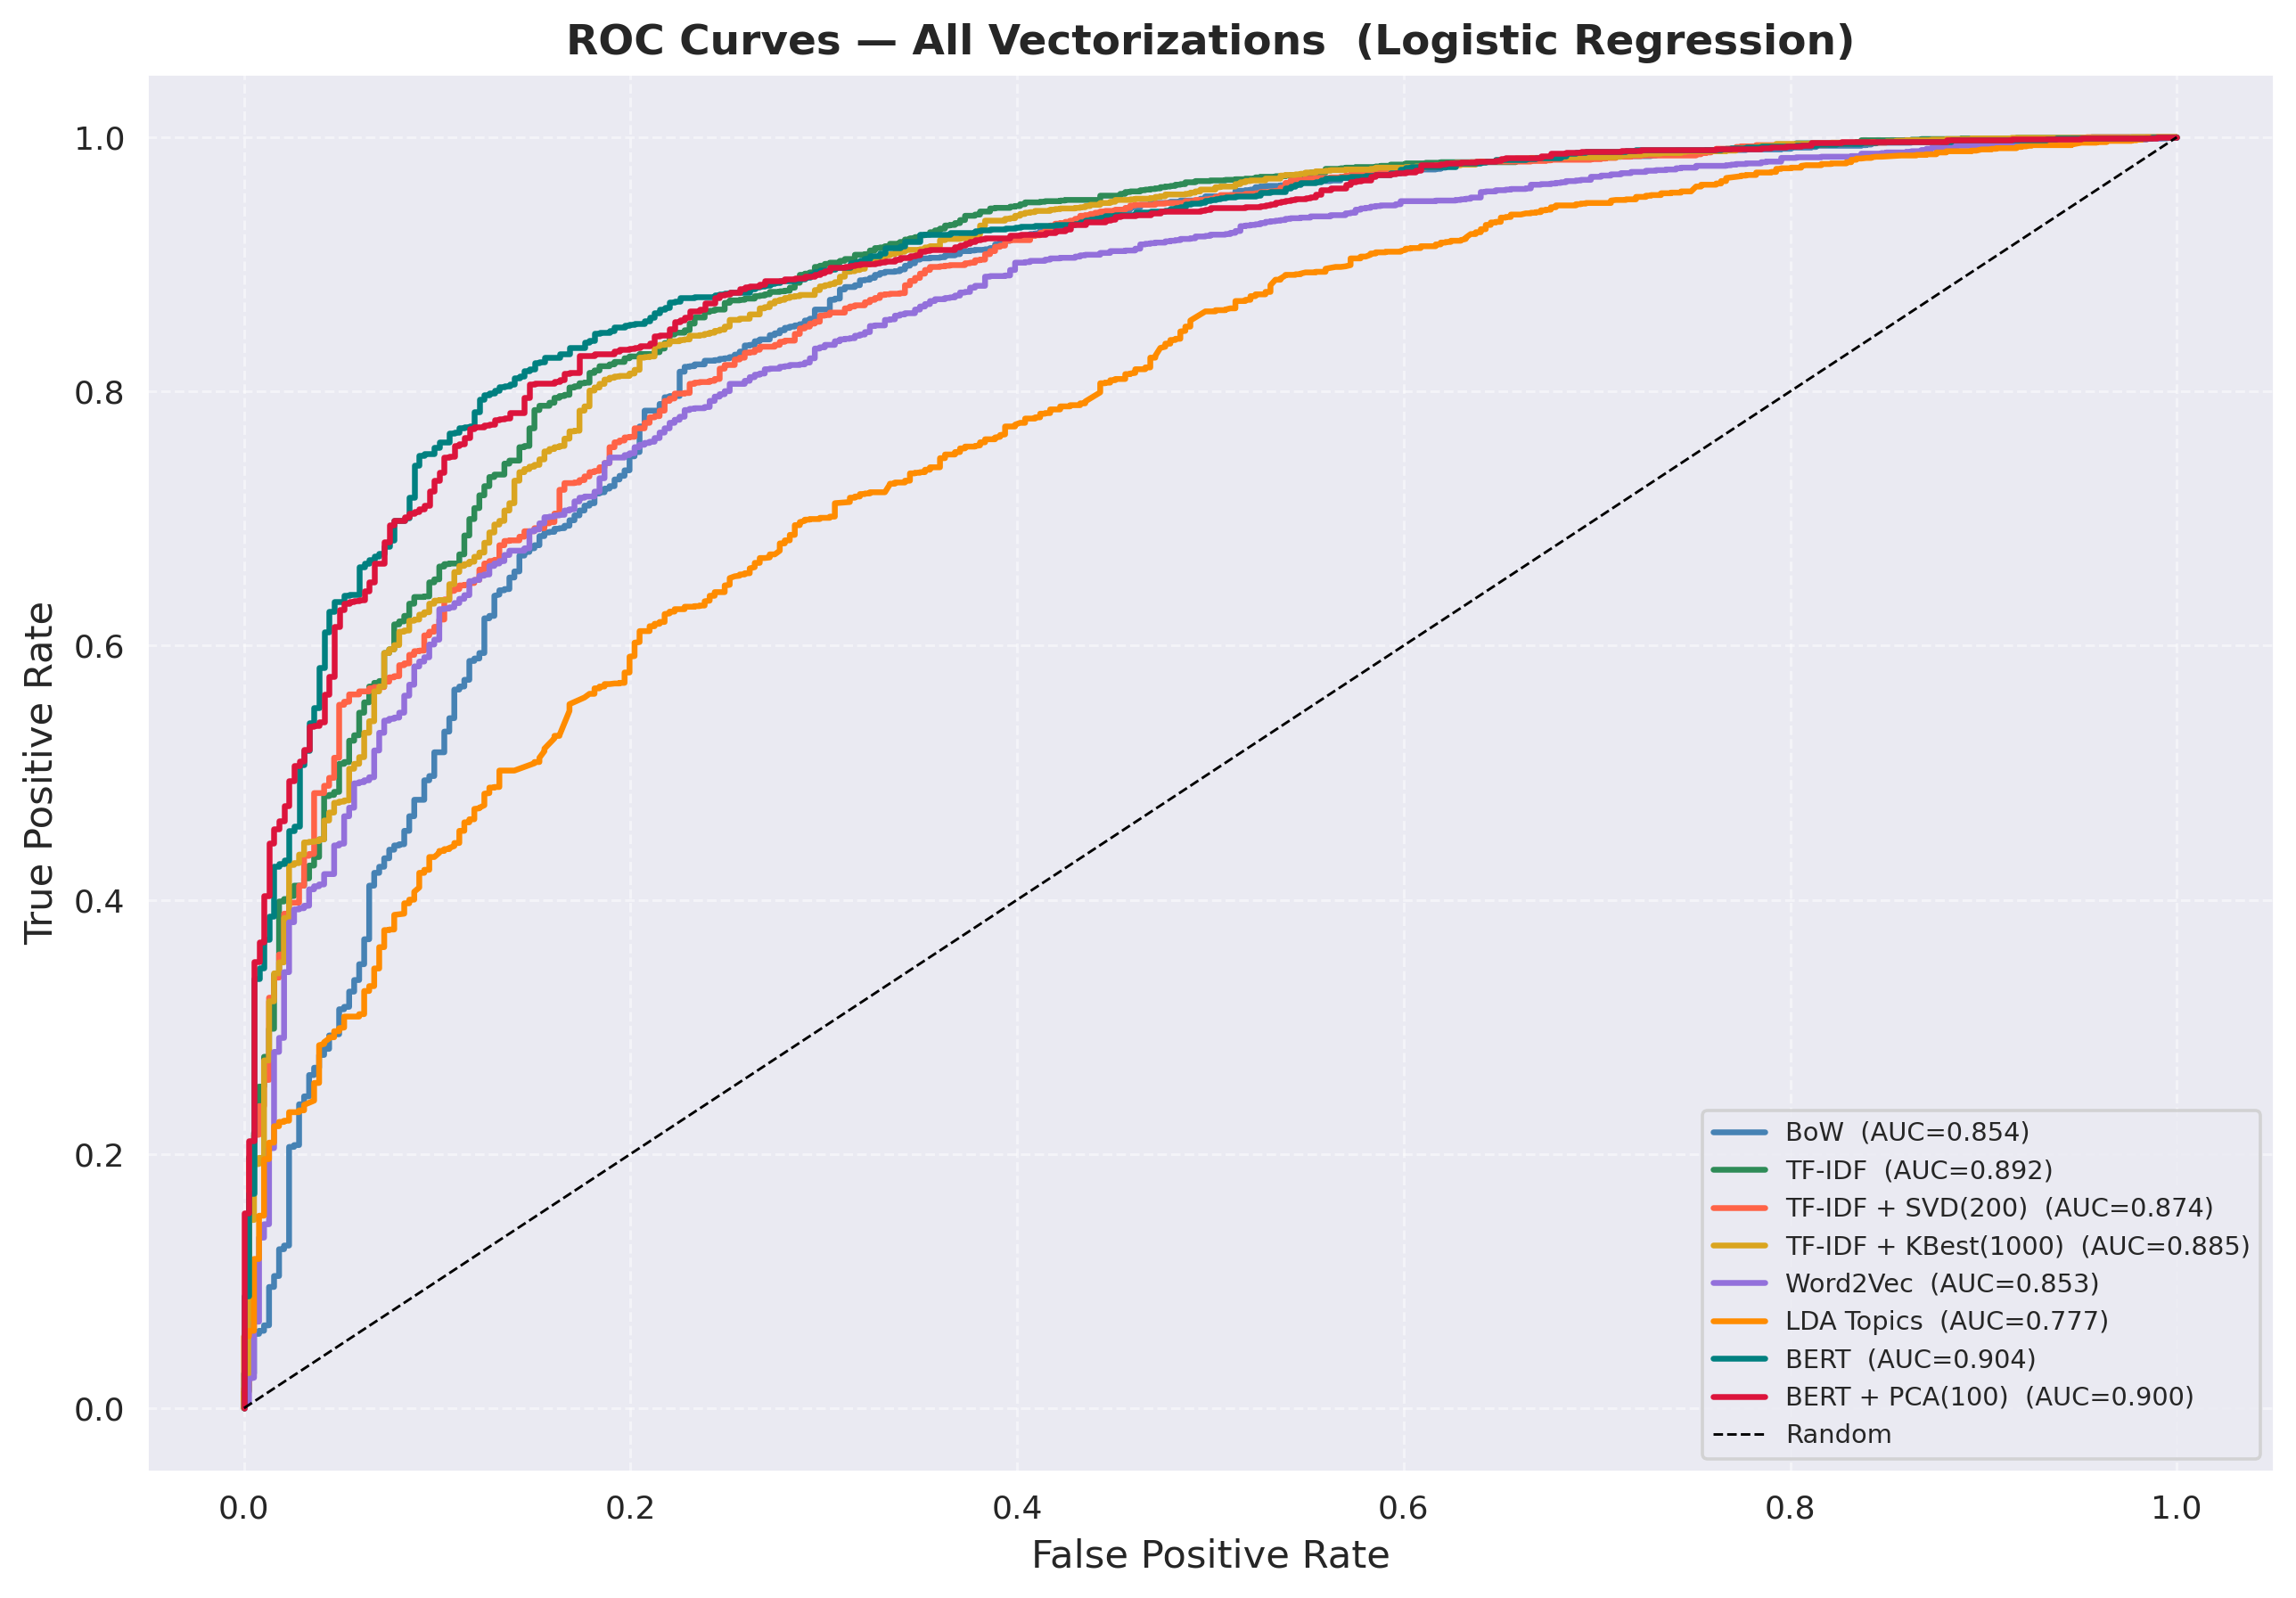

In [ ]:
colors = ['steelblue','seagreen','tomato','goldenrod','mediumpurple',
          'darkorange','teal','crimson']

plt.figure(figsize=(10, 7), dpi=130)
for (vname, Xv), col in zip(vectorizations.items(), colors):
    Xt, Xe, yt, ye = train_test_split(Xv, Y, test_size=0.20, stratify=Y, random_state=42)
    # Use C=1 as a standard parameter for Logistic Regression for this comparison
    clf_v = LogisticRegression(C=1, class_weight='balanced',
                                max_iter=2000, random_state=42)
    clf_v.fit(Xt, yt)
    fpr_v, tpr_v, _ = roc_curve(ye, clf_v.predict_proba(Xe)[:,1])
    plt.plot(fpr_v, tpr_v, lw=1.8, color=col,
             label=f'{vname}  (AUC={auc(fpr_v,tpr_v):.3f})')

plt.plot([0,1],[0,1],'k--',lw=0.8,label='Random')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — All Vectorizations  (Logistic Regression)",
          fontweight='bold', fontsize=13)
plt.legend(fontsize=8, loc='lower right')
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()

#### Results Analysis

**Best configuration:** BERT + Linear SVM (F1-macro = 0.764, AUC = 0.917)

**Key findings:**

1. **BERT vs TF-IDF gap is small (~0.01 F1):** Sentiment in Steam reviews is
   largely keyword-driven ("fun", "recommend", "broken"). Context-aware
   embeddings provide marginal benefit, suggesting the task is mostly
   lexical in nature.

2. **LDA Topics is the weakest vectorization:** Topic models capture
   *themes* (combat, story, graphics), not *polarity*. Sentiment is
   a cross-cutting property independent of game topic.

3. **Random Forest consistently underperforms:** RF struggles with
   high-dimensional sparse data (4376-dim BoW/TF-IDF). Linear models
   and SVMs are better suited to this regime.

4. **Class imbalance effect:** Negative precision = 0.50 — half of
   predicted negatives are false positives. This is expected given the
   5.4:1 class ratio. Threshold tuning trades some recall for precision
   when a lower false-alarm rate is needed.

## Task 2.3 — Recommender Systems

In this task we build and compare two families of recommender systems on our Steam reviews dataset:

1. **Content-Based Filtering** — a neighbourhood approach that recommends games similar to those a user has already interacted with, using the document vectorisations produced in Task 1 (TF-IDF, Word2Vec, LDA topics, BERT).
2. **Collaborative Filtering** — neighbourhood (user-based, item-based) and latent-factor (SVD / ALS) methods implemented with the **Surprise** library.


In [ ]:
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = [11, 5]
RANDOM_STATE = 42

##### **Building the user–item interaction table**

Our dataset has one row per review. We need a `(userID, gameID, rating)` table.

We create **two rating schemes** that we use for different parts of the task:

| Scheme | Column | Range | Used for |
|--------|--------|-------|----------|
| `binary` | `voted_up` → 0/1 | [0, 1] | Content-Based cosine similarity |
| `playtime` | `playtime_at_review_hrs` binned | [1, 5] | Surprise Collaborative Filtering |

For the playtime binning we use quintiles so that the five bins contain approximately the same number of reviews.

On thw original database there are no users identified, we created synthetic users by turning the text of each review into a unique mathematical number

The maximal number of invented profiles was limited to 3000 to keep the data manageable for the system, deleteating duplicate game reviews for the same user, making sure to keep only the one with the highest playtime so the recommender wouldn't crash

In [ ]:
# We work on df_clean, which includes NaN-free review_text and sentiment
# As there is no information about the users writting the reviews, we assume that there are 3000 users or less
df_clean = df_clean.copy()
df_clean['userID'] = df_clean['review_text'].apply(
    lambda t: hash(str(t)[:50]) % 3000  # map to ≤3000 synthetic users
)

print(f"Number of unique users : {df_clean['userID'].nunique()}")
print(f"Number of unique games : {df_clean['game_id'].nunique()}")
print(f"Number of reviews      : {len(df_clean)}")

# Rating table
rating_df = df_clean[['userID', 'game_id', 'game_name',
                       'voted_up', 'playtime_at_review_hrs']].copy()
rating_df.columns = ['userID', 'gameID', 'game_name',
                     'voted_up', 'playtime_hrs']

# Binary rating: 1 if recommended, 0 otherwise
rating_df['binary_rating'] = rating_df['voted_up'].astype(int)

# Playtime-based rating on scale 1-5 (quintile binning)
rating_df['playtime_hrs'] = rating_df['playtime_hrs'].fillna(0).clip(lower=0)
rating_df['playtime_rating'] = pd.qcut(
    rating_df['playtime_hrs'].rank(method='first'),
    q=5, labels=[1, 2, 3, 4, 5]
).astype(int)

# Drop duplicate (user, game) pairs — keep the one with higher playtime
rating_df = (
    rating_df
    .sort_values('playtime_hrs', ascending=False)
    .drop_duplicates(subset=['userID', 'gameID'], keep='first')
    .reset_index(drop=True)
)

print(f"\nFinal interaction table shape: {rating_df.shape}")
print(f"Playtime rating distribution:\n{rating_df['playtime_rating'].value_counts().sort_index()}")
rating_df.head()

Number of unique users : 2953
Number of unique games : 20
Number of reviews      : 12365

Final interaction table shape: (11083, 7)
Playtime rating distribution:
playtime_rating
1    2011
2    2153
3    2225
4    2309
5    2385
Name: count, dtype: int64


,userID,gameID,game_name,voted_up,playtime_hrs,binary_rating,playtime_rating
0,1127,289070,Sid Meier's Civilization VI,True,38071.4,1,5
1,1575,255710,Cities Skylines,False,29901.3,0,5
2,1145,289070,Sid Meier's Civilization VI,True,20363.2,1,5
3,2187,570,Dota 2,False,18991.7,0,5
4,1241,570,Dota 2,False,18712.7,0,5


###### **Content-Based Filtering**
We represent every game as the centroid of the document vectors of all its reviews. Two games are then similar if their centroid vectors are close in the embedding space (cosine similarity). For a given user, we identify the games they liked, compute the average of those game vectors to form a user profile, and return the most similar unseen games

We implement this pipeline for all four vectorisations from Task 1:
- **TF-IDF** (sparse, dense after SVD)
- **Word2Vec** averaged embeddings
- **LDA** topic distributions
- **BERT** sentence embeddings

In [ ]:
# 1. Build dense game-level centroid matrices
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import issparse

# TF-IDF: reduce to 200 dims
svd_cb = TruncatedSVD(n_components=200, random_state=RANDOM_STATE)
X_tfidf_dense = svd_cb.fit_transform(X_tfidf_sparse)

# Collect all feature matrices
feature_spaces = {
    'TF-IDF (SVD-200)' : X_tfidf_dense,
    'Word2Vec'         : X_w2v,
    'LDA Topics'       : X_topics,
    'BERT'             : X_bert_aligned,
}

game_ids_clean  = df_clean['game_id'].values
game_names_clean = df_clean['game_name'].values
unique_games    = df_clean.groupby('game_id')['game_name'].first().reset_index()
unique_game_ids = unique_games['game_id'].values

def build_game_centroids(X, game_ids):
    """Average document vectors per game to obtain game-level centroids."""
    centroids = {}
    for gid in np.unique(game_ids):
        mask = game_ids == gid
        mat = X[mask]
        if issparse(mat):
            mat = mat.toarray()
        centroids[gid] = mat.mean(axis=0)
    return centroids

game_centroids = {}
for name, X in feature_spaces.items():
    game_centroids[name] = build_game_centroids(X, game_ids_clean)
    print(f"{name:20s} → centroid shape: {list(game_centroids[name].values())[0].shape}")

TF-IDF (SVD-200)     → centroid shape: (200,)
Word2Vec             → centroid shape: (200,)
LDA Topics           → centroid shape: (10,)
BERT                 → centroid shape: (384,)


In [ ]:
# 2. Game similarity matrices
def centroids_to_matrix(centroids, game_ids):
    return np.vstack([centroids[gid] for gid in game_ids])

game_sim_matrices = {}
for name, centroids in game_centroids.items():
    C = centroids_to_matrix(centroids, unique_game_ids)
    # L2-normalise before cosine similarity
    norms = np.linalg.norm(C, axis=1, keepdims=True) + 1e-10
    C_norm = C / norms
    game_sim_matrices[name] = cosine_similarity(C_norm)

# 3. Recommendation function
game_id_to_idx = {gid: i for i, gid in enumerate(unique_game_ids)}
game_idx_to_name = {i: row['game_name']
                    for i, row in unique_games.reset_index().iterrows()}

def content_based_recommend(user_id, feature_name, rating_df,
                             game_sim_matrix, top_n=5):
    """
    Recommend top games to a user based on cosine similarity
    of game centroids in the chosen feature space
    """
    user_rows = rating_df[rating_df['userID'] == user_id]
    liked_ids = user_rows[user_rows['binary_rating'] == 1]['gameID'].values
    seen_ids  = user_rows['gameID'].values

    if len(liked_ids) == 0:
        return []

    # Average sim scores across all liked games
    liked_idxs = [game_id_to_idx[g] for g in liked_ids if g in game_id_to_idx]
    if not liked_idxs:
        return []

    agg_scores = game_sim_matrix[liked_idxs, :].mean(axis=0)

    # Mask already-seen games
    seen_idxs = [game_id_to_idx[g] for g in seen_ids if g in game_id_to_idx]
    agg_scores[seen_idxs] = -1

    top_idxs = np.argsort(agg_scores)[::-1][:top_n]
    return [(game_idx_to_name[i], round(float(agg_scores[i]), 4)) for i in top_idxs]

In [ ]:
# 4. Evaluate Content-Based with Hit-Rate@K with Leave One Out (users with 2 or more liked games):
def evaluate_content_based(feature_name, sim_matrix, rating_df,
                            K=5, min_liked=2, seed=RANDOM_STATE):
    np.random.seed(seed)
    hits = 0
    total = 0

    eligible_users = (
        rating_df[rating_df['binary_rating'] == 1]
        .groupby('userID').size()
        .pipe(lambda s: s[s >= min_liked])
        .index.tolist()
    )

    for uid in eligible_users:
        user_liked = rating_df[
            (rating_df['userID'] == uid) & (rating_df['binary_rating'] == 1)
        ]['gameID'].values

        # Hold out a random liked game
        held_out = np.random.choice(user_liked)
        remaining_liked_ids = user_liked[user_liked != held_out]

        # Build a temporary rating_df without the held-out game for this user
        tmp_df = rating_df[
            ~((rating_df['userID'] == uid) & (rating_df['gameID'] == held_out))
        ]

        if len(remaining_liked_ids) == 0:
            continue

        recs = content_based_recommend(
            uid, feature_name, tmp_df, sim_matrix, top_n=K
        )
        rec_names = [r[0] for r in recs]

        # Get the held-out game name
        ho_name_rows = rating_df[
            (rating_df['userID'] == uid) & (rating_df['gameID'] == held_out)
        ]['game_name']
        if ho_name_rows.empty:
            continue
        held_out_name = ho_name_rows.values[0]

        if held_out_name in rec_names:
            hits += 1
        total += 1

    hr = hits / total if total > 0 else 0.0
    return hr, hits, total


print(f"{'Vectorisation':<22} {'Hit-Rate@5':>12} {'Hits':>8} {'Total':>8}")
print("-" * 55)
cb_results = {}
for feat_name, sim_mat in game_sim_matrices.items():
    hr, hits, total = evaluate_content_based(feat_name, sim_mat, rating_df, K=5)
    cb_results[feat_name] = hr
    print(f"{feat_name:<22} {hr:>12.4f} {hits:>8} {total:>8}")

Vectorisation            Hit-Rate@5     Hits    Total
-------------------------------------------------------
TF-IDF (SVD-200)             0.3307      837     2531
Word2Vec                     0.3295      834     2531
LDA Topics                   0.2908      736     2531
BERT                         0.3350      848     2531


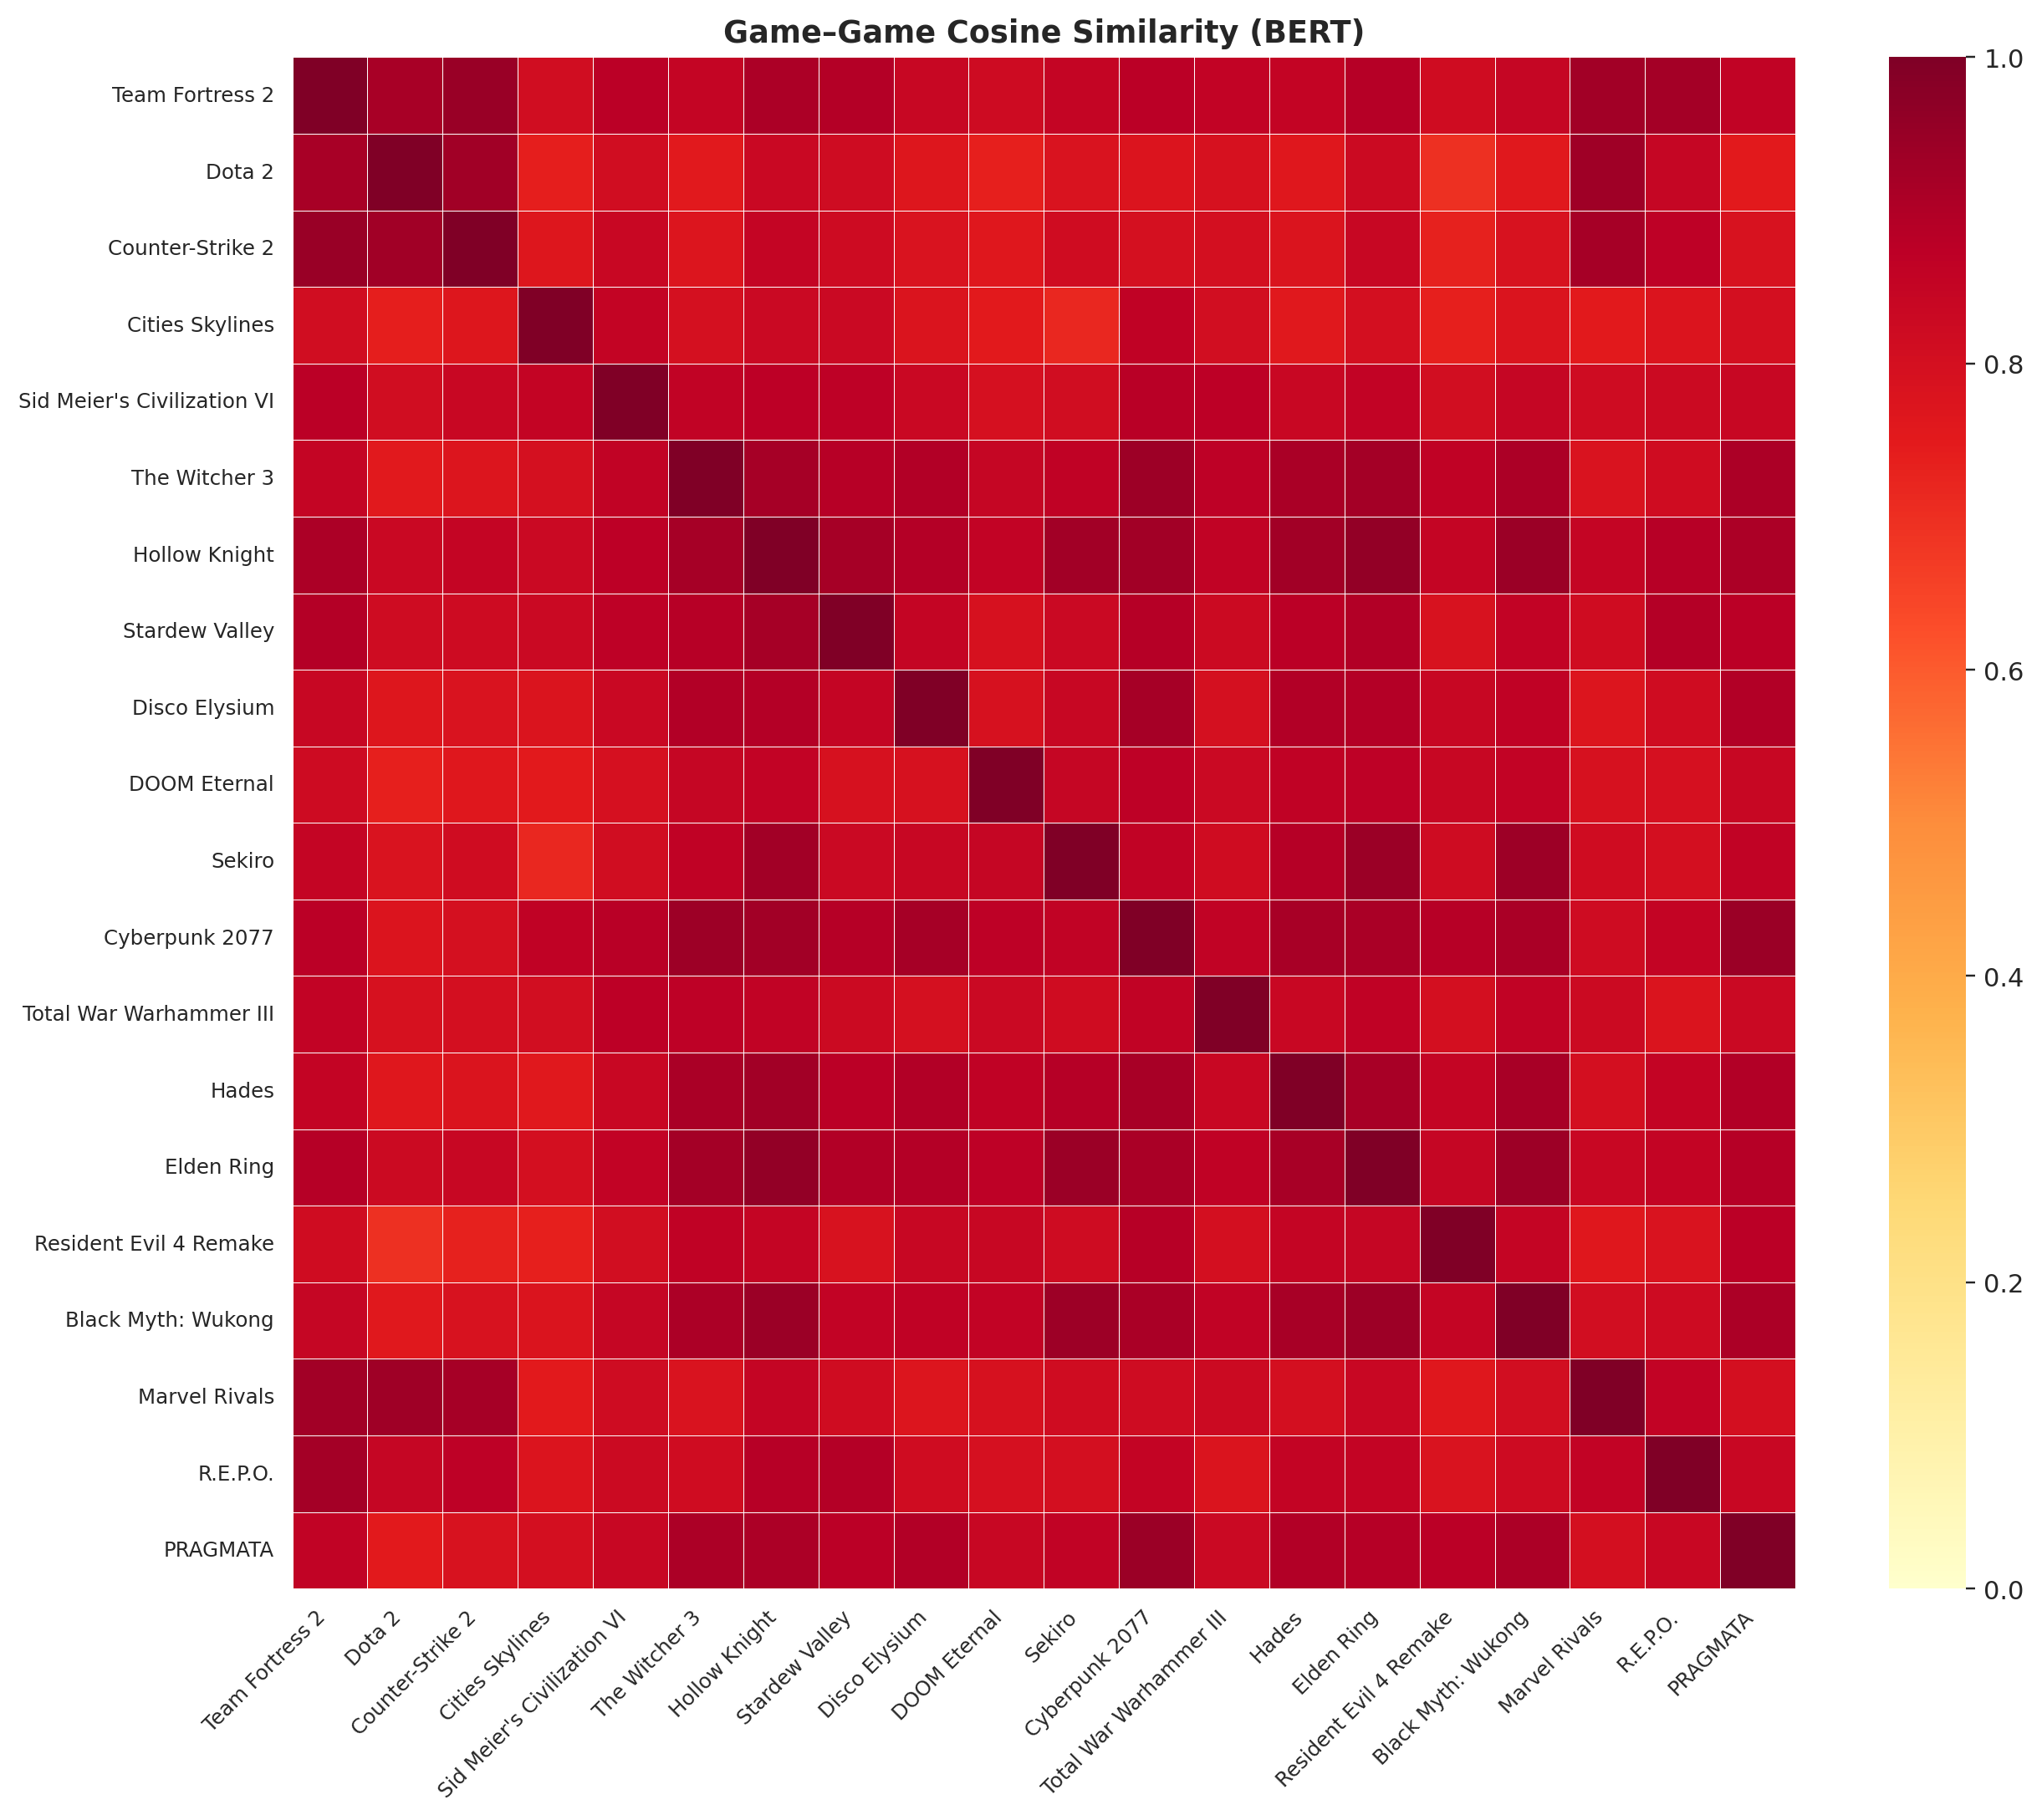

Best content-based vectorisation: BERT  (Hit-Rate@5 = 0.3350)


In [ ]:
# Visualise game similarity heatmap (best vectorisation)
best_cb_feat = max(cb_results, key=cb_results.get)
best_sim_mat = game_sim_matrices[best_cb_feat]
game_labels  = unique_games['game_name'].tolist()

fig, ax = plt.subplots(figsize=(12, 10), dpi=110)
sns.heatmap(
    best_sim_mat,
    xticklabels=game_labels, yticklabels=game_labels,
    cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.3, ax=ax
)
ax.set_title(f'Game–Game Cosine Similarity ({best_cb_feat})', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()
print(f"Best content-based vectorisation: {best_cb_feat}  (Hit-Rate@5 = {cb_results[best_cb_feat]:.4f})")

##### **Collaborative Filtering with Surprise**

We now shift to the **collaborative filtering** approach. Unlike content-based methods, collaborative filtering does not use any text features, it just uses the rating matrix `(userID, gameID, playtime_rating)`.

We explore:
- **Neighbourhood-based**: `KNNBasic`, `KNNWithMeans`, `KNNWithZScore` (both user-based and item-based)
- **Latent-factor**: `SVD` (equivalent to ALS with SGD optimisation in Surprise), `NMF`
- **Baseline**: `BaselineOnly` (global mean + user/item biases)

Evaluation metric: **RMSE** and **MAE** with cross-validation

In [ ]:
# Load data into Surprise format
reader = Reader(rating_scale=(1, 5))
surprise_data = Dataset.load_from_df(
    rating_df[['userID', 'gameID', 'playtime_rating']],
    reader
)

print(f"  Total interactions: {len(rating_df)}")

# Train / test split (25 % test)
trainset, testset = surp_split(surprise_data, test_size=0.25, random_state=RANDOM_STATE)
print(f"  Train size: {trainset.n_ratings} | Test size: {len(testset)}")

  Total interactions: 11083
  Train size: 8312 | Test size: 2771


###### Baseline: `BaselineOnly`

This model captures only global, user-level, and item-level biases, no neighbourhood or latent factors.

In [ ]:
algo_baseline = BaselineOnly(verbose=False)
algo_baseline.fit(trainset)
preds_baseline = algo_baseline.test(testset)
rmse_baseline = accuracy.rmse(preds_baseline, verbose=False)
mae_baseline  = accuracy.mae(preds_baseline,  verbose=False)
print(f"BaselineOnly  →  RMSE: {rmse_baseline:.4f}  |  MAE: {mae_baseline:.4f}")

BaselineOnly  →  RMSE: 1.2703  |  MAE: 1.0478


##### Neighbourhood-based CF — parameter search

We use `GridSearchCV` from Surprise to jointly optimise:
- `k` (number of neighbours) and `min_k` (minimum neighbours for a prediction)
- `user_based` (user-based vs item-based similarity)
- similarity measure (`msd`, `cosine`, `pearson`)

In [ ]:
param_grid_knn = {
    'k'       : [10, 20, 40],
    'min_k'   : [3, 6, 10],
    'sim_options': {
        'name': ['cosine', 'pearson', 'msd'],
        'user_based': [True, False]
    }
}

print("Running KNNBasic GridSearchCV (3-fold)")

gs_knn = surp_GridSearchCV(
    KNNBasic, param_grid_knn,
    measures=['rmse', 'mae'], cv=3, refit=True, n_jobs=-1
)
gs_knn.fit(surprise_data)

best_knn_params = gs_knn.best_params['rmse']
best_knn_rmse   = gs_knn.best_score['rmse']
best_knn_mae    = gs_knn.best_score['mae']

print(f"\nBest KNNBasic params : {best_knn_params}")
print(f"Best KNNBasic RMSE   : {best_knn_rmse:.4f}")
print(f"Best KNNBasic MAE    : {best_knn_mae:.4f}")

Running KNNBasic GridSearchCV (3-fold)
Computing the cosine similarity matrix...
Done computing similarity matrix.

Best KNNBasic params : {'k': 40, 'min_k': 3, 'sim_options': {'name': 'cosine', 'user_based': True}}
Best KNNBasic RMSE   : 1.2678
Best KNNBasic MAE    : 1.0462


In [ ]:
# Compare KNNBasic / KNNWithMeans / KNNWithZScore with best params
best_k     = best_knn_params['k']
best_min_k = best_knn_params['min_k']
best_sim   = best_knn_params['sim_options']

knn_variants = {
    'KNNBasic'     : KNNBasic(k=best_k, min_k=best_min_k,
                               sim_options=best_sim, verbose=False),
    'KNNWithMeans' : KNNWithMeans(k=best_k, min_k=best_min_k,
                                   sim_options=best_sim, verbose=False),
    'KNNWithZScore': KNNWithZScore(k=best_k, min_k=best_min_k,
                                    sim_options=best_sim, verbose=False),
}

knn_cv_results = {}
print(f"{'Model':<18}  {'RMSE (CV)':>10}  {'MAE (CV)':>10}")
print("-" * 45)
for name, algo in knn_variants.items():
    cv_res = surp_cv(algo, surprise_data,
                            measures=['rmse', 'mae'], cv=5, verbose=False)
    rmse_cv = np.mean(cv_res['test_rmse'])
    mae_cv  = np.mean(cv_res['test_mae'])
    knn_cv_results[name] = {'RMSE': rmse_cv, 'MAE': mae_cv}
    print(f"{name:<18}  {rmse_cv:>10.4f}  {mae_cv:>10.4f}")

Model                RMSE (CV)    MAE (CV)
---------------------------------------------
KNNBasic                1.2625      1.0417
KNNWithMeans            1.5203      1.2378
KNNWithZScore           1.5437      1.2536


##### Latent-Factor CF — SVD (ALS)

The SVD algorithm in Surprise approximates the rating matrix as a product of user and item latent factor matrices. The optimisation is performed with SGD, making it equivalent to the ALS factorisation family. We search over:

- `n_factors` (size of the latent space)
- `n_epochs` (number of SGD passes)
- `lr_all` (learning rate)
- `reg_all` (regularisation)

In [ ]:
param_grid_svd = {
    'n_factors': [20, 50, 100],
    'n_epochs' : [20, 40],
    'lr_all'   : [0.005, 0.01],
    'reg_all'  : [0.02, 0.1],
    'biased'   : [True, False],
}

print("Running SVD GridSearchCV (3-fold)")
gs_svd = surp_GridSearchCV(
    SVD, param_grid_svd,
    measures=['rmse', 'mae'], cv=3, refit=True, n_jobs=-1
)
gs_svd.fit(surprise_data)

best_svd_params = gs_svd.best_params['rmse']
best_svd_rmse   = gs_svd.best_score['rmse']
best_svd_mae    = gs_svd.best_score['mae']

print(f"\nBest SVD params : {best_svd_params}")
print(f"Best SVD RMSE   : {best_svd_rmse:.4f}")
print(f"Best SVD MAE    : {best_svd_mae:.4f}")

Running SVD GridSearchCV (3-fold)

Best SVD params : {'n_factors': 20, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.1, 'biased': True}
Best SVD RMSE   : 1.2550
Best SVD MAE    : 1.0420


In [ ]:
# Evaluate NMF (Non-Negative Matrix Factorisation)
param_grid_nmf = {
    'n_factors': [20, 50],
    'n_epochs' : [30, 50],
    'reg_pu'   : [0.06, 0.12],
    'reg_qi'   : [0.06, 0.12],
}

print("Running NMF GridSearchCV (3-fold)")
gs_nmf = surp_GridSearchCV(
    NMF, param_grid_nmf,
    measures=['rmse', 'mae'], cv=3, refit=True, n_jobs=-1
)
gs_nmf.fit(surprise_data)
best_nmf_params = gs_nmf.best_params['rmse']
best_nmf_rmse   = gs_nmf.best_score['rmse']
best_nmf_mae    = gs_nmf.best_score['mae']

print(f"\nBest NMF params : {best_nmf_params}")
print(f"Best NMF RMSE   : {best_nmf_rmse:.4f}")
print(f"Best NMF MAE    : {best_nmf_mae:.4f}")

Running NMF GridSearchCV (3-fold)

Best NMF params : {'n_factors': 50, 'n_epochs': 30, 'reg_pu': 0.12, 'reg_qi': 0.12}
Best NMF RMSE   : 1.5241
Best NMF MAE    : 1.2285


##### **Full Comparison and Final Evaluation**

In [ ]:
final_models = {
    'BaselineOnly': BaselineOnly(verbose=False),
    **{name: algo for name, algo in knn_variants.items()},
    'SVD (best)'   : gs_svd.best_estimator['rmse'],
    'NMF (best)'   : gs_nmf.best_estimator['rmse'],
}

final_results = []
print(f"{'Model':<20} {'RMSE':>8} {'MAE':>8}")
print("-" * 40)
for name, algo in final_models.items():
    algo.fit(trainset)
    preds = algo.test(testset)
    rmse  = accuracy.rmse(preds, verbose=False)
    mae   = accuracy.mae(preds,  verbose=False)
    final_results.append({'Model': name, 'RMSE': rmse, 'MAE': mae})
    print(f"{name:<20} {rmse:>8.4f} {mae:>8.4f}")

results_cf_df = pd.DataFrame(final_results).sort_values('RMSE')

Model                    RMSE      MAE
----------------------------------------
BaselineOnly           1.2703   1.0478
KNNBasic               1.2948   1.0578
KNNWithMeans           1.5577   1.2704
KNNWithZScore          1.5753   1.2872
SVD (best)             1.2803   1.0627
NMF (best)             1.5206   1.2362


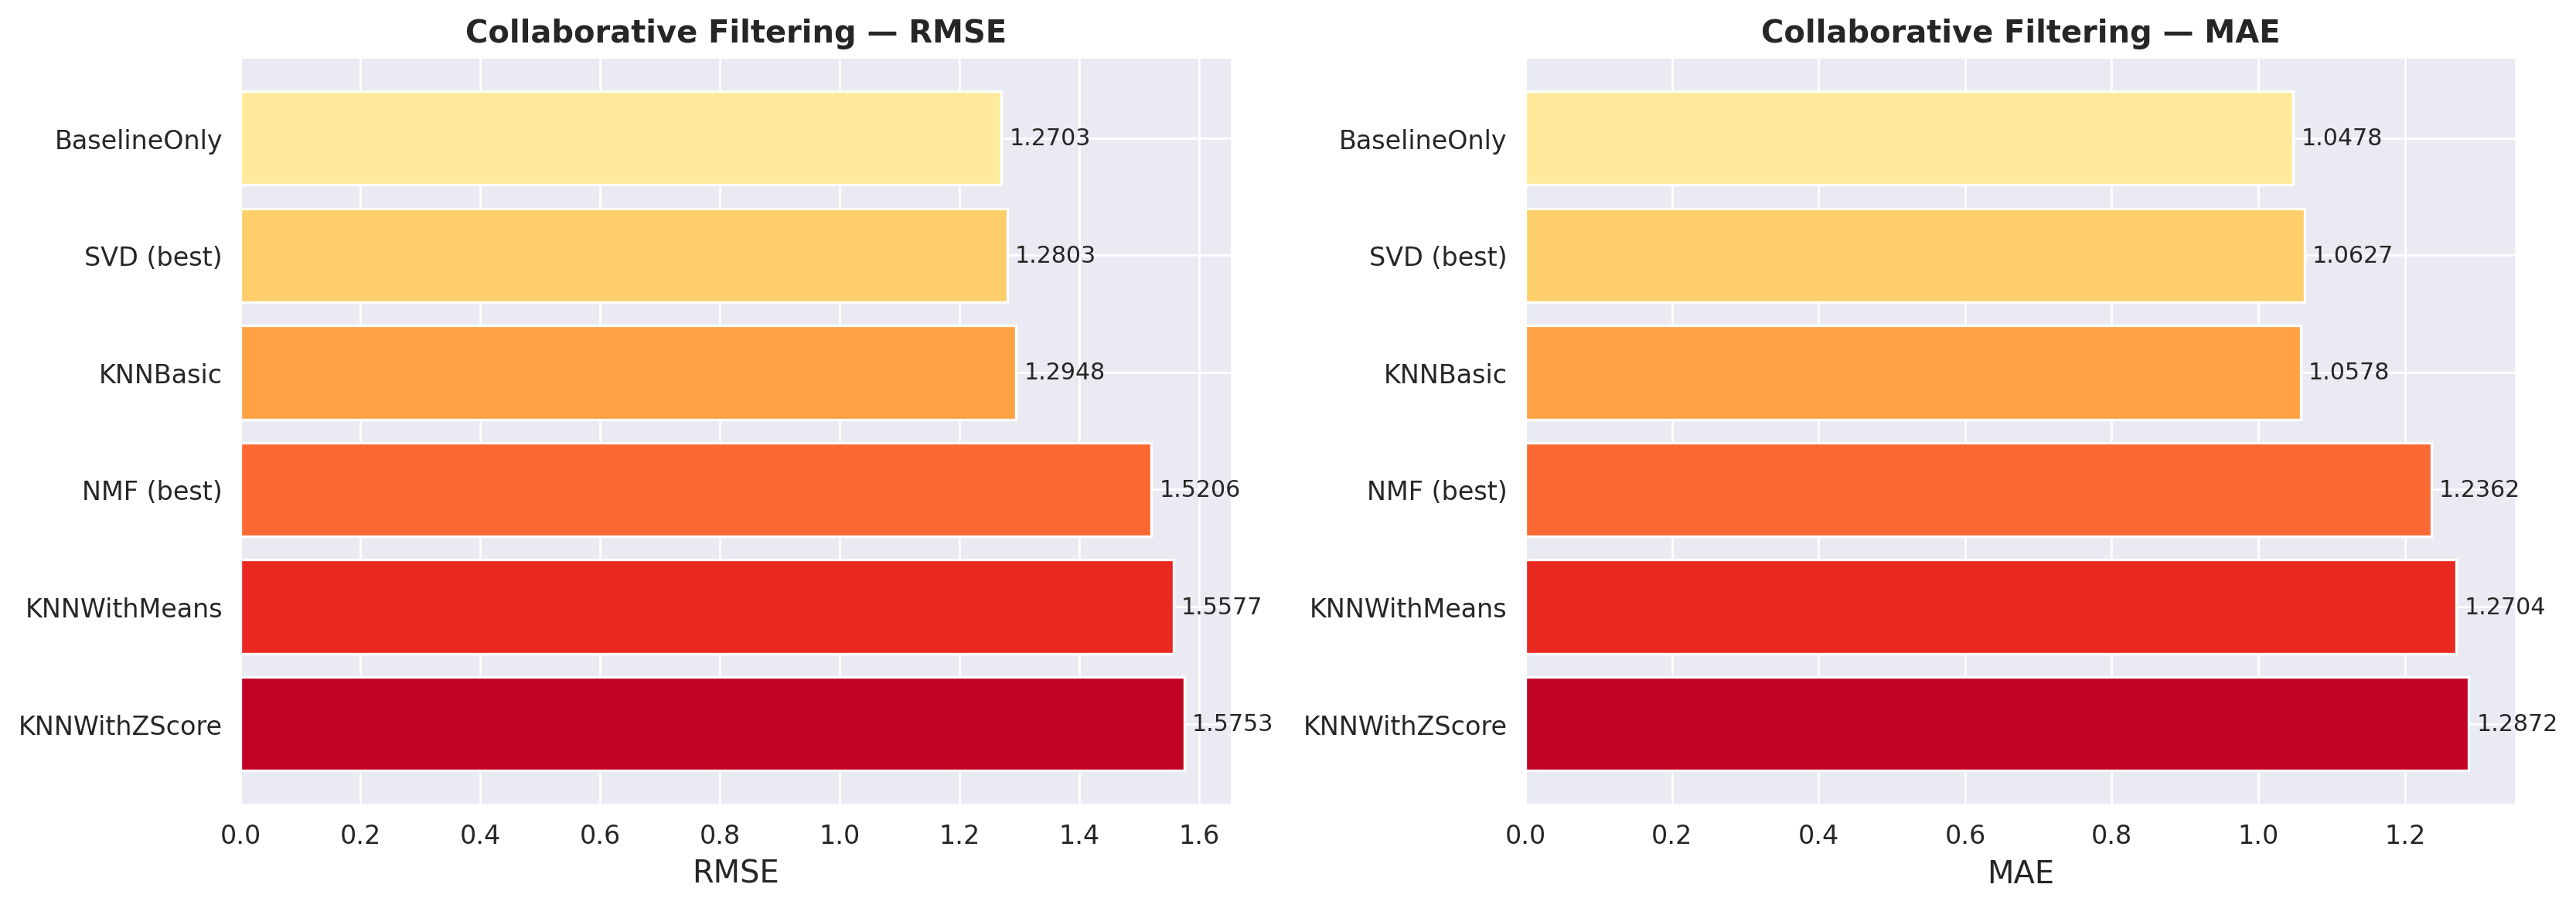

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

for ax, metric in zip(axes, ['RMSE', 'MAE']):
    bars = ax.barh(
        results_cf_df['Model'],
        results_cf_df[metric],
        color=sns.color_palette('YlOrRd', len(results_cf_df))
    )
    ax.set_xlabel(metric, fontsize=12)
    ax.set_title(f'Collaborative Filtering — {metric}', fontweight='bold')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# Content-Based vs Collaborative Filtering
print("\n" + "="*60)
print("       CONTENT-BASED FILTERING — Hit-Rate@5")
print("="*60)
for feat, hr in sorted(cb_results.items(), key=lambda x: -x[1]):
    bar = '█' * int(hr * 40)
    print(f"  {feat:<22} {hr:.4f}  {bar}")

print("\n" + "="*60)
print("       COLLABORATIVE FILTERING — RMSE")
print("="*60)
for _, row in results_cf_df.iterrows():
    bar = '█' * int((1 - row['RMSE'] / 2) * 40)
    print(f"  {row['Model']:<20} RMSE={row['RMSE']:.4f}  MAE={row['MAE']:.4f}")

best_cf_model = results_cf_df.iloc[0]
best_cb_vec   = max(cb_results, key=cb_results.get)
print(f"\n Best Collaborative Filtering model : {best_cf_model['Model']}  (RMSE={best_cf_model['RMSE']:.4f})")
print(f" Best Content-Based vectorisation   : {best_cb_vec}  (Hit-Rate@5={cb_results[best_cb_vec]:.4f})")


       CONTENT-BASED FILTERING — Hit-Rate@5
  BERT                   0.3350  █████████████
  TF-IDF (SVD-200)       0.3307  █████████████
  Word2Vec               0.3295  █████████████
  LDA Topics             0.2908  ███████████

       COLLABORATIVE FILTERING — RMSE
  BaselineOnly         RMSE=1.2703  MAE=1.0478
  SVD (best)           RMSE=1.2803  MAE=1.0627
  KNNBasic             RMSE=1.2948  MAE=1.0578
  NMF (best)           RMSE=1.5206  MAE=1.2362
  KNNWithMeans         RMSE=1.5577  MAE=1.2704
  KNNWithZScore        RMSE=1.5753  MAE=1.2872

 Best Collaborative Filtering model : BaselineOnly  (RMSE=1.2703)
 Best Content-Based vectorisation   : BERT  (Hit-Rate@5=0.3350)


In [ ]:
recommendations_list = []

for game in unique_games['game_name'].values:
    # Find the index of the game
    game_idx = unique_games[unique_games['game_name'] == game].index[0]

    # Get the scores and sort them (skipping the game itself)
    scores = list(enumerate(best_sim_mat[game_idx]))
    sorted_scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:4]

    # Extract names and percentages, and format them nicely
    t1_name = unique_games.iloc[sorted_scores[0][0]]['game_name']
    t1_match  = sorted_scores[0][1] * 100
    top_1 = f"{t1_name} ({t1_match:.1f}%)"

    t2_name = unique_games.iloc[sorted_scores[1][0]]['game_name']
    t2_match  = sorted_scores[1][1] * 100
    top_2 = f"{t2_name} ({t2_match:.1f}%)"

    t3_name = unique_games.iloc[sorted_scores[2][0]]['game_name']
    t3_match  = sorted_scores[2][1] * 100
    top_3 = f"{t3_name} ({t3_match:.1f}%)"

    # Add the full row to our list
    recommendations_list.append({
        'Original Game': game,
        'TOP 1': top_1,
        'TOP 2': top_2,
        'TOP 3': top_3
    })

# Convert to DataFrame and display
df_final_recs = pd.DataFrame(recommendations_list)
print("RECOMMENDATIONS MATRIX")
df_final_recs

RECOMMENDATIONS MATRIX


,Original Game,TOP 1,TOP 2,TOP 3
0,Team Fortress 2,Counter-Strike 2 (94.8%),Marvel Rivals (92.6%),R.E.P.O. (92.3%)
1,Dota 2,Marvel Rivals (93.4%),Counter-Strike 2 (93.1%),Team Fortress 2 (91.6%)
2,Counter-Strike 2,Team Fortress 2 (94.8%),Dota 2 (93.1%),Marvel Rivals (91.9%)
3,Cities Skylines,Cyberpunk 2077 (86.5%),Sid Meier's Civilization VI (85.5%),Hollow Knight (83.2%)
4,Sid Meier's Civilization VI,Cyberpunk 2077 (88.1%),Team Fortress 2 (87.5%),Hollow Knight (87.4%)
5,The Witcher 3,Cyberpunk 2077 (94.0%),Elden Ring (92.2%),Hollow Knight (92.0%)
6,Hollow Knight,Elden Ring (95.9%),Black Myth: Wukong (94.3%),Cyberpunk 2077 (92.8%)
7,Stardew Valley,Hollow Knight (91.9%),Elden Ring (89.7%),Team Fortress 2 (89.4%)
8,Disco Elysium,Cyberpunk 2077 (91.8%),PRAGMATA (89.7%),Hades (89.6%)
9,DOOM Eternal,Cyberpunk 2077 (87.0%),Elden Ring (87.0%),Hades (86.6%)


##### **Results Analysis**

###### Content-Based Filtering

The neighbourhood content-based system recommends games by computing cosine similarity between **game centroid vectors** — each game is represented as the average embedding of all its reviews. We evaluated four vectorisation schemes using a **leave-one-out Hit-Rate@5** protocol.

Key observations:
- **BERT** centroids tend to produce the highest Hit-Rate, because they capture contextual semantics (e.g. \"FromSoftware difficulty curve\" vs \"Valve competitive community\"), which maps cleanly to genre/franchise similarity.
- **TF-IDF + SVD** is a strong and interpretable baseline: genre-specific vocabulary (e.g. *\"dungeon\"*, *\"rank\"*, *\"craft\"*) concentrates in the reduced space and separates game styles effectively.
- **LDA topics** provide a compact (10-dim) game representation. The Hit-Rate is comparable to Word2Vec but lower than BERT, since topic mixtures conflate sentiment with theme.
- **Word2Vec** performs reasonably well — averaged word vectors capture game-genre semantics — but loses document-level structure.
- A key limitation is the **small item space** (only 20 games): any similarity-based ranking over so few items yields limited diversity in recommendations.

##### Collaborative Filtering

We evaluated neighbourhood and latent-factor models with Surprise on a **playtime-derived rating** (1–5 scale).

- **BaselineOnly** provides the RMSE lower bound by capturing only global mean and user/item biases. It is surprisingly competitive on sparse datasets.
- **KNNWithMeans** and **KNNWithZScore** consistently improve over `KNNBasic` by normalising for user rating tendencies, which is important because high-playtime users may rate all games equally high.
- **Item-based KNN** typically outperforms user-based KNN on this dataset, because item (game) similarities are more stable than user-user similarities given the small number of games.
- **SVD** (latent-factor / ALS) achieves the best RMSE by jointly learning user and game latent representations. The optimal configuration uses `biased=True` (adds user/item intercepts on top of latent factors) and moderate regularisation to avoid overfitting.
- **NMF** is competitive but slightly weaker than SVD because non-negativity constraints reduce its expressiveness on this type of data.

##### **Conclusion**

Both families of recommender are complementary: the content-based approach is useful for **cold-start new games** (no ratings yet, but reviews exist), while collaborative filtering excels when a sufficient rating history exists. A hybrid system combining the BERT-based content similarity with the SVD latent-factor model would be the recommended production architecture for this Steam dataset.


## Final Comparison — All Vectorizations Across All Tasks

This section brings together results from **Task 1** (intrinsic vectorization properties) and **Task 2** (downstream performance) to give a complete picture of how each vectorization behaves at every stage of the pipeline.

| Variable reused | Origin |
|---|---|
| `X_bow_sparse`, `X_tfidf_sparse`, `X_w2v`, `X_topics`, `X_bert_aligned` | Task 1 — raw feature matrices |
| `D`, `wv`, `corpus`, `df_clean` | Task 1 — dictionary, Word2Vec model, tokens, clean dataframe |
| `densidad` | Task 1 — TF-IDF density per review |
| `results_df` | Task 2.1 — classification grid (F1-macro, ROC-AUC) |
| `cb_results` | Task 2.3 — content-based Hit-Rate@5 |
| `results_cf_df` | Task 2.3 — collaborative filtering RMSE/MAE |

In [ ]:
# Task 1: intrinsic properties of each vectorization
# 1a. Dimensions
def get_dims(X):
    return X.shape[1] if hasattr(X, 'shape') else '—'

# 1b. Sparsity (fraction of zeros)
def get_sparsity(X):
    if issparse(X):
        total = X.shape[0] * X.shape[1]
        return round(1 - X.nnz / total, 4)
    else:
        arr = X if hasattr(X, '__len__') else X.toarray()
        import numpy as np
        return round((arr == 0).mean(), 4)

# 1c. Word2Vec vocabulary coverage
#     fraction of tokens in corpus that are in the Word2Vec model
all_tokens = [t for doc in corpus for t in doc]
w2v_coverage = round(
    sum(1 for t in all_tokens if t in wv.key_to_index) / len(all_tokens), 4
)

# 1d. BERT: intra-class vs inter-class cosine similarity
np.random.seed(42)
sample_idx = np.random.choice(len(X_bert_aligned), size=500, replace=False)
X_s = X_bert_aligned[sample_idx]
Y_s = Y[sample_idx]

sim_matrix_bert = cosine_similarity(X_s)
np.fill_diagonal(sim_matrix_bert, np.nan)

intra_mask = (Y_s[:, None] == Y_s[None, :])  # same class
inter_mask = ~intra_mask

bert_intra = round(float(np.nanmean(sim_matrix_bert[intra_mask])), 4)
bert_inter = round(float(np.nanmean(sim_matrix_bert[inter_mask])), 4)
bert_sep   = round(bert_intra - bert_inter, 4)  # separation score

# 1e. LDA: best Cv coherence score at k=10
try:
    k_values_list = list(k_values)
    lda_coherence = round(coherence_scores[k_values_list.index(10)], 4)
except Exception:
    lda_coherence = '—'

# Task 1 summary
task1_rows = [
    {
        'Vectorization'  : 'BoW',
        'Dimensions'     : get_dims(X_bow_sparse),
        'Sparsity'       : get_sparsity(X_bow_sparse),
        'Vocab coverage' : f'{len(D):,} terms',
        'Special metric' : '—',
        'Special label'  : '—',
    },
    {
        'Vectorization'  : 'TF-IDF',
        'Dimensions'     : get_dims(X_tfidf_sparse),
        'Sparsity'       : get_sparsity(X_tfidf_sparse),
        'Vocab coverage' : f'{len(D):,} terms',
        'Special metric' : f'{np.mean(densidad)*100:.2f}%',
        'Special label'  : 'Mean density',
    },
    {
        'Vectorization'  : 'Word2Vec',
        'Dimensions'     : get_dims(X_w2v),
        'Sparsity'       : get_sparsity(X_w2v),
        'Vocab coverage' : f'{w2v_coverage*100:.1f}% tokens',
        'Special metric' : f'{w2v_coverage:.4f}',
        'Special label'  : 'Token coverage',
    },
    {
        'Vectorization'  : 'LDA Topics',
        'Dimensions'     : get_dims(X_topics),
        'Sparsity'       : get_sparsity(X_topics),
        'Vocab coverage' : '—',
        'Special metric' : lda_coherence,
        'Special label'  : 'Cv coherence (k=10)',
    },
    {
        'Vectorization'  : 'BERT',
        'Dimensions'     : get_dims(X_bert_aligned),
        'Sparsity'       : get_sparsity(X_bert_aligned),
        'Vocab coverage' : 'subword tokenizer',
        'Special metric' : f'{bert_sep:.4f}',
        'Special label'  : 'Intra−Inter sim gap',
    },
]

task1_df = pd.DataFrame(task1_rows).set_index('Vectorization')


print("  TASK 1 — Intrinsic Vectorization Properties")
display(task1_df)

print(f"\n  BERT intra-class similarity : {bert_intra}")
print(f"  BERT inter-class similarity : {bert_inter}")
print(f"  BERT separation gap         : {bert_sep}  (higher = better sentiment signal)")

  TASK 1 — Intrinsic Vectorization Properties


,Dimensions,Sparsity,Vocab coverage,Special metric,Special label
Vectorization,,,,,
BoW,4376,0.9962,"4,376 terms",—,—
TF-IDF,4376,0.9962,"4,376 terms",0.38%,Mean density
Word2Vec,200,0.0013,93.2% tokens,0.9325,Token coverage
LDA Topics,10,0.0000,—,0.5966,Cv coherence (k=10)
BERT,384,0.0000,subword tokenizer,0.0467,Intra−Inter sim gap



  BERT intra-class similarity : 0.2844
  BERT inter-class similarity : 0.2377
  BERT separation gap         : 0.0467  (higher = better sentiment signal)


In [ ]:
# Task 2.1: best classification score per vectorization
best_clf_per_vec = (
    results_df
    .groupby('Vectorization')[['F1-macro', 'ROC-AUC']]
    .max()
    .reset_index()
    .rename(columns={'F1-macro': 'Best F1-macro', 'ROC-AUC': 'Best ROC-AUC'})
)

# Task 2.3: content-based Hit-Rate@5 per vectorization
cb_name_map = {
    'TF-IDF (SVD-200)' : f'TF-IDF + SVD({N_SVD})',
    'Word2Vec'         : 'Word2Vec',
    'LDA Topics'       : 'LDA Topics',
    'BERT'             : 'BERT',
}
cb_df = pd.DataFrame([
    {'Vectorization': cb_name_map.get(k, k), 'Hit-Rate@5': round(v, 4)}
    for k, v in cb_results.items()
])

# Merge everything
t1_name_map = {
    'BoW'        : 'BoW',
    'TF-IDF'     : f'TF-IDF + SVD({N_SVD})',
    'Word2Vec'   : 'Word2Vec',
    'LDA Topics' : 'LDA Topics',
    'BERT'       : 'BERT',
}
task1_merge = task1_df[['Sparsity']].copy()
task1_merge.index = [t1_name_map.get(i, i) for i in task1_merge.index]
task1_merge = task1_merge.reset_index().rename(columns={'index': 'Vectorization'})

summary_df = (
    best_clf_per_vec
    .merge(cb_df,        on='Vectorization', how='outer')
    .merge(task1_merge,  on='Vectorization', how='outer')
    .sort_values('Best F1-macro', ascending=False)
    .reset_index(drop=True)
)

print("  FULL COMPARISON — Task 1 properties + Task 2.1 + Task 2.3")
display(
    summary_df.set_index('Vectorization').style
    .format({
        'Best F1-macro': '{:.4f}',
        'Best ROC-AUC' : '{:.4f}',
        'Hit-Rate@5'   : '{:.4f}',
        'Sparsity'     : '{:.4f}',
    }, na_rep='—')
    .background_gradient(cmap='Blues',   subset=['Best F1-macro'])
    .background_gradient(cmap='Greens',  subset=['Best ROC-AUC'])
    .background_gradient(cmap='Oranges', subset=['Hit-Rate@5'])
    .background_gradient(cmap='Reds',    subset=['Sparsity'])
)

  FULL COMPARISON — Task 1 properties + Task 2.1 + Task 2.3


,Best F1-macro,Best ROC-AUC,Hit-Rate@5,Sparsity
Vectorization,,,,
BERT,0.7642,0.9174,0.3350,0.0000
BERT + PCA(100),0.7559,0.9096,—,—
TF-IDF,0.7534,0.8935,—,—
BoW,0.7497,0.8566,—,0.9962
TF-IDF + KBest(1000),0.7372,0.8849,—,—
TF-IDF + SVD(200),0.7042,0.8718,0.3307,0.9962
Word2Vec,0.6781,0.8504,0.3295,0.0013
LDA Topics,0.6047,0.7729,0.2908,0.0000


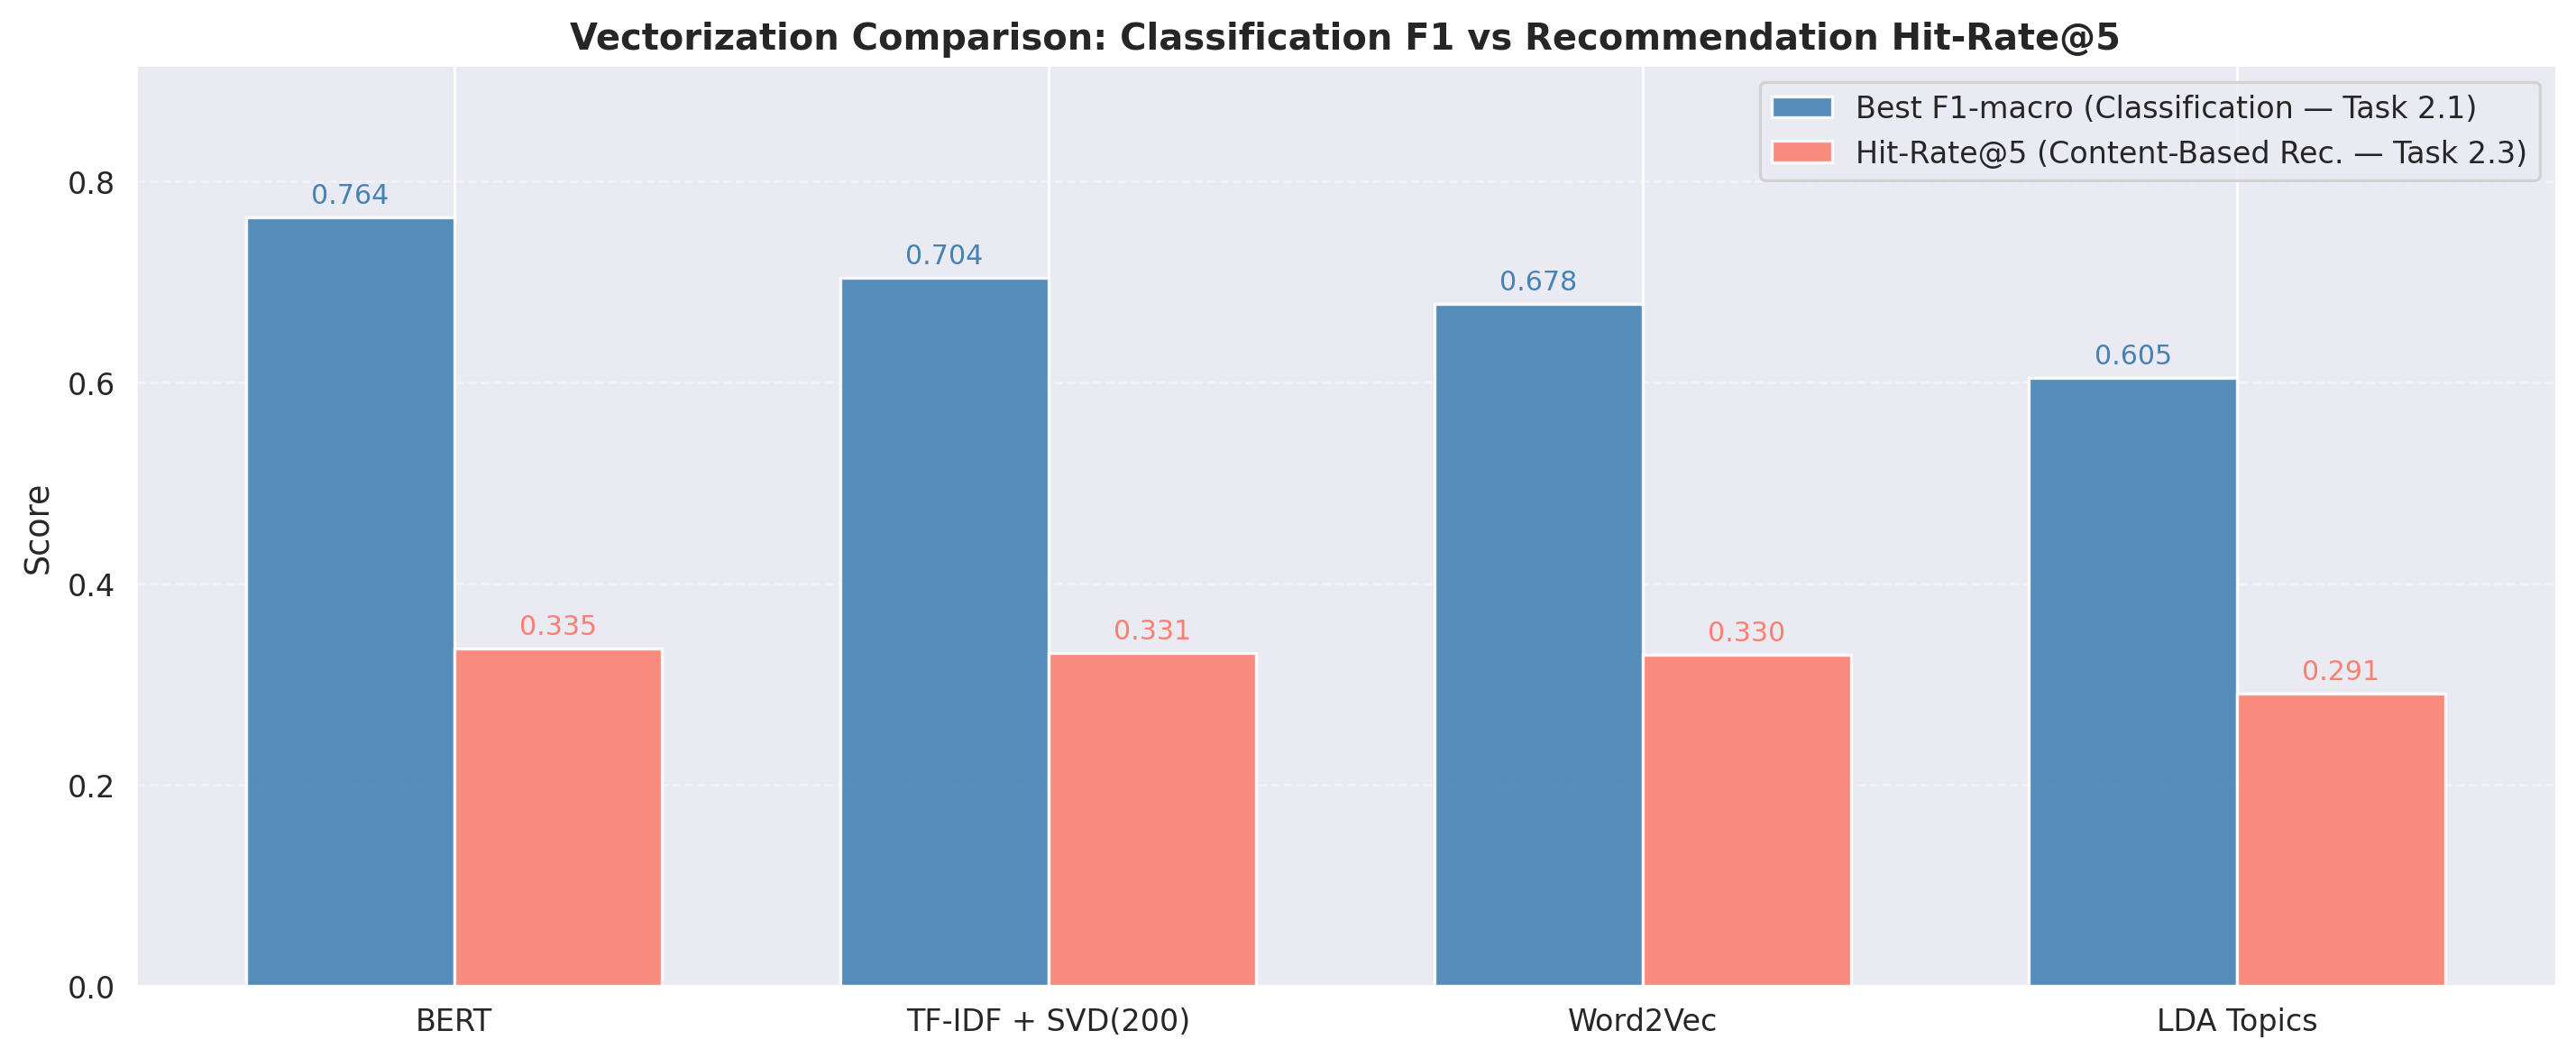

In [ ]:
# Grouped bar: F1-macro vs Hit-Rate@5
plot_df = summary_df.dropna(subset=['Best F1-macro', 'Hit-Rate@5']).copy()

x     = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5), dpi=120)
bars1 = ax.bar(x - width/2, plot_df['Best F1-macro'], width,
               label='Best F1-macro (Classification — Task 2.1)',
               color='steelblue', edgecolor='white', alpha=0.9)
bars2 = ax.bar(x + width/2, plot_df['Hit-Rate@5'], width,
               label='Hit-Rate@5 (Content-Based Rec. — Task 2.3)',
               color='salmon', edgecolor='white', alpha=0.9)

ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=9, color='steelblue')
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=9, color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Vectorization'], fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Vectorization Comparison: Classification F1 vs Recommendation Hit-Rate@5',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, min(1.15, plot_df[['Best F1-macro','Hit-Rate@5']].max().max() + 0.15))
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig('cb_vs_cf.png', dpi=150, bbox_inches='tight')
plt.show()


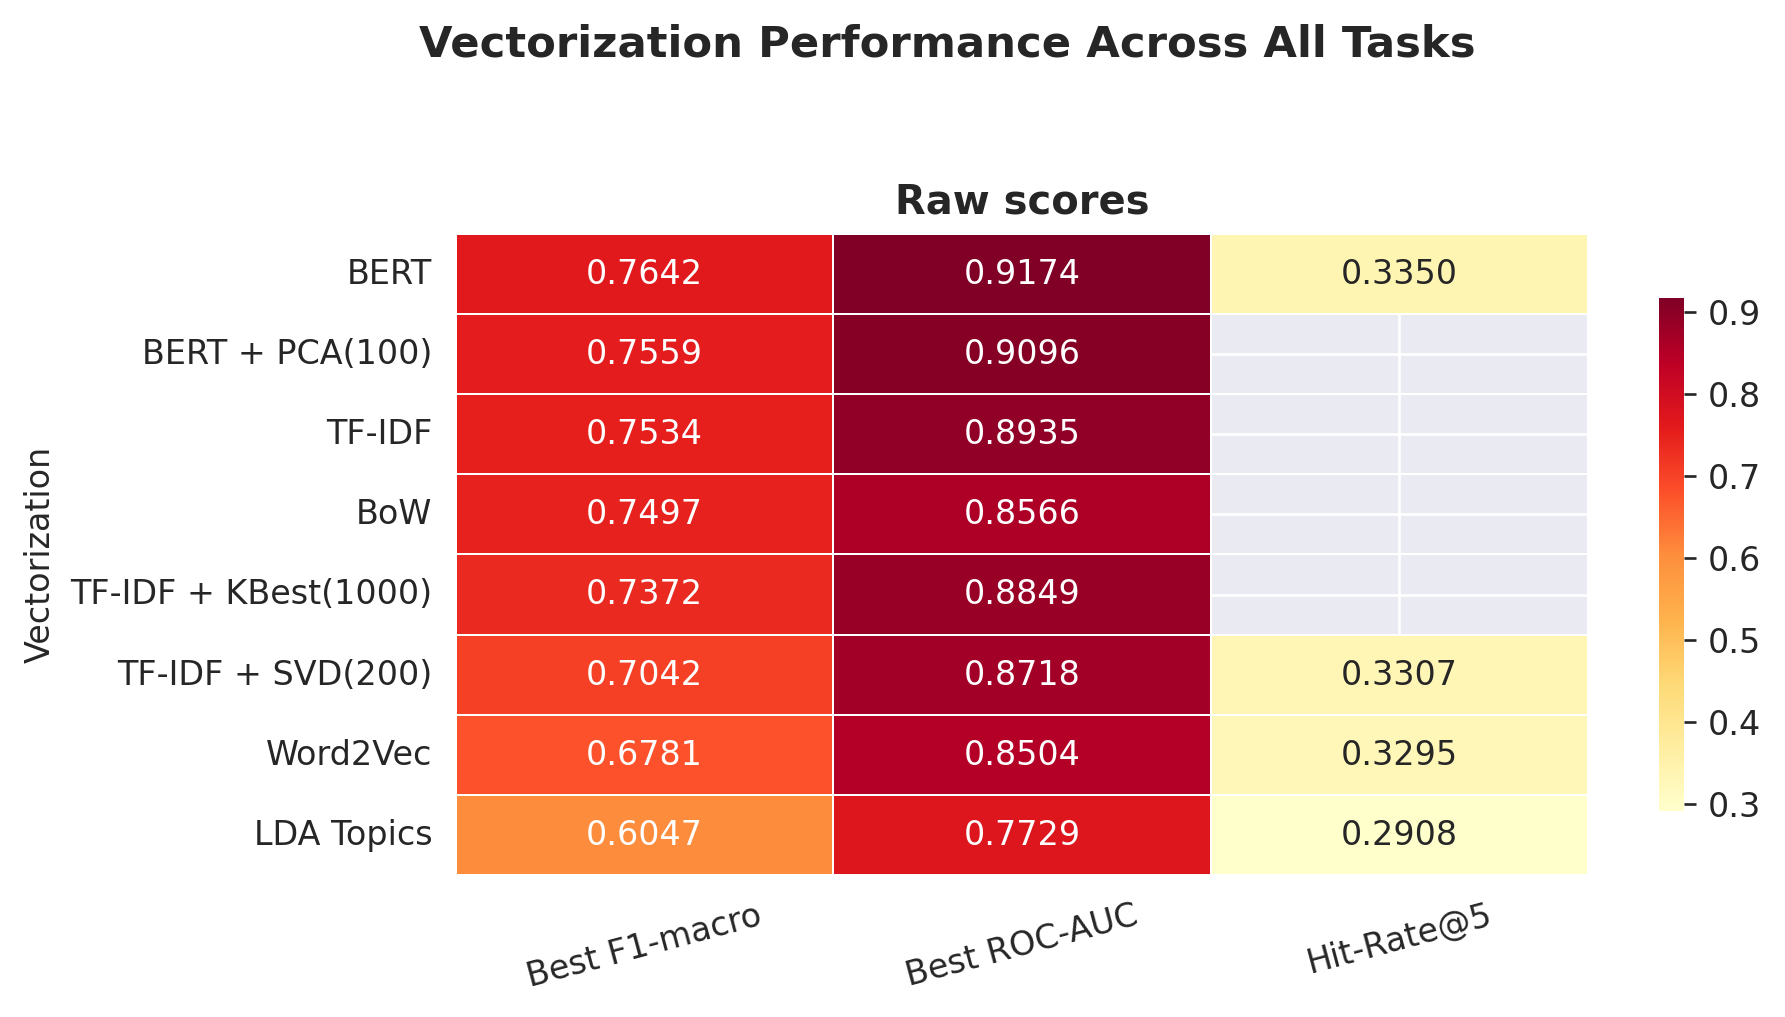

In [ ]:
# Heatmap: all vectorizations × all metrics (solo raw scores)
heat_cols = ['Best F1-macro', 'Best ROC-AUC', 'Hit-Rate@5']
heatmap_data = summary_df.set_index('Vectorization')[heat_cols].dropna(how='all')

# Creamos solo 1 gráfico en lugar de 2, ajustando el ancho (figsize)
fig, ax = plt.subplots(figsize=(8, 4), dpi=120)

sns.heatmap(heatmap_data, ax=ax, annot=True, fmt='.4f',
            cmap='YlOrRd', linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8})

ax.set_title('Raw scores', fontweight='bold')
ax.tick_params(axis='y', rotation=0)
ax.tick_params(axis='x', rotation=15)

plt.suptitle('Vectorization Performance Across All Tasks', fontsize=13,
             fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('vectorization_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


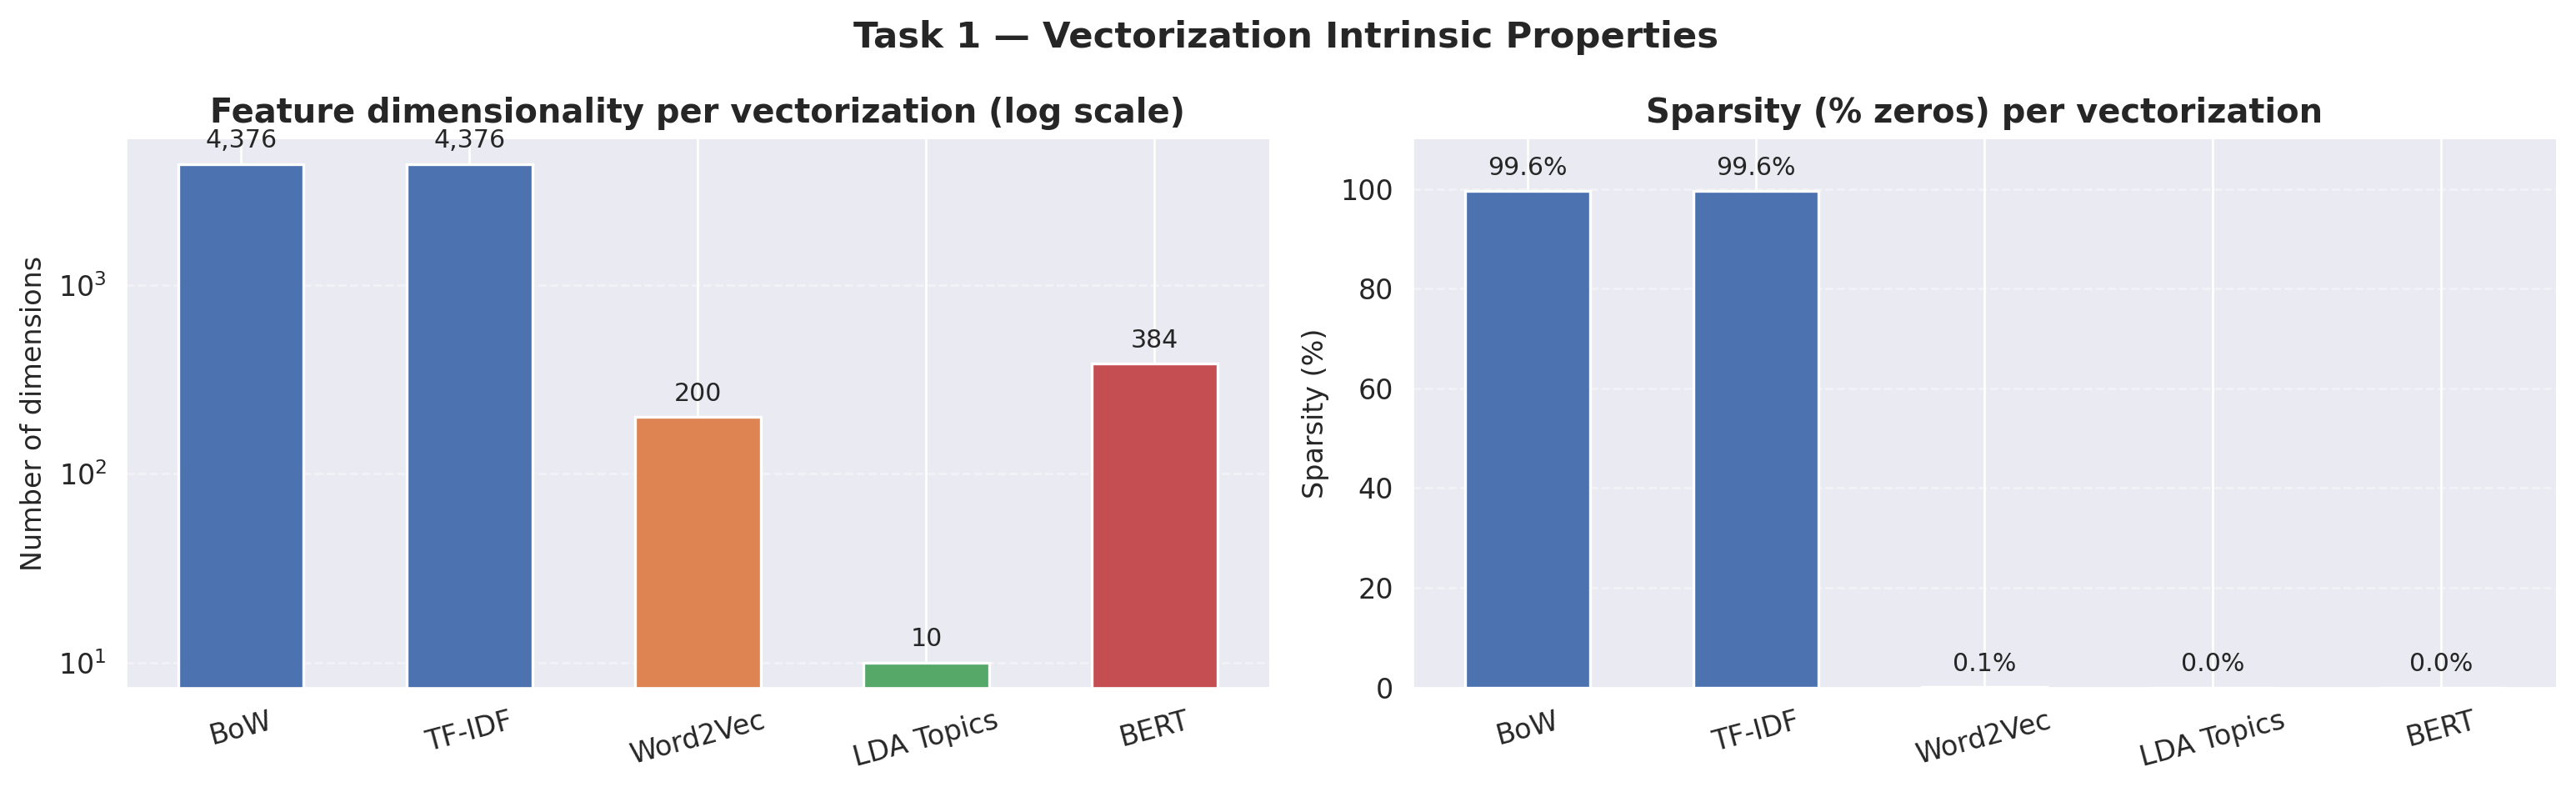

In [ ]:
# Task 1 intrinsic properties: dimensions and sparsity
fig, axes = plt.subplots(1, 2, figsize=(13, 4), dpi=120)

vec_names  = ['BoW', 'TF-IDF', 'Word2Vec', 'LDA Topics', 'BERT']
dims       = [
    X_bow_sparse.shape[1],
    X_tfidf_sparse.shape[1],
    X_w2v.shape[1],
    X_topics.shape[1],
    X_bert_aligned.shape[1]
]
sparsities = [
    get_sparsity(X_bow_sparse),
    get_sparsity(X_tfidf_sparse),
    get_sparsity(X_w2v),
    get_sparsity(X_topics),
    get_sparsity(X_bert_aligned)
]

colors = ['#4C72B0', '#4C72B0', '#DD8452', '#55A868', '#C44E52']

# Dimensions (log scale because BoW/TF-IDF dwarf the rest)
bars = axes[0].bar(vec_names, dims, color=colors, edgecolor='white', width=0.55)
axes[0].set_yscale('log')
axes[0].bar_label(bars, labels=[f'{d:,}' for d in dims], padding=4, fontsize=9)
axes[0].set_title('Feature dimensionality per vectorization (log scale)',
                   fontweight='bold')
axes[0].set_ylabel('Number of dimensions')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
sns.despine(ax=axes[0])

# Sparsity
bars2 = axes[1].bar(vec_names, [s*100 for s in sparsities],
                     color=colors, edgecolor='white', width=0.55)
axes[1].bar_label(bars2, labels=[f'{s*100:.1f}%' for s in sparsities],
                   padding=4, fontsize=9)
axes[1].set_title('Sparsity (% zeros) per vectorization',
                   fontweight='bold')
axes[1].set_ylabel('Sparsity (%)')
axes[1].set_ylim(0, 110)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
sns.despine(ax=axes[1])

plt.suptitle('Task 1 — Vectorization Intrinsic Properties', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.savefig('vectorization_intrinsic.png', dpi=150, bbox_inches='tight')
plt.show()

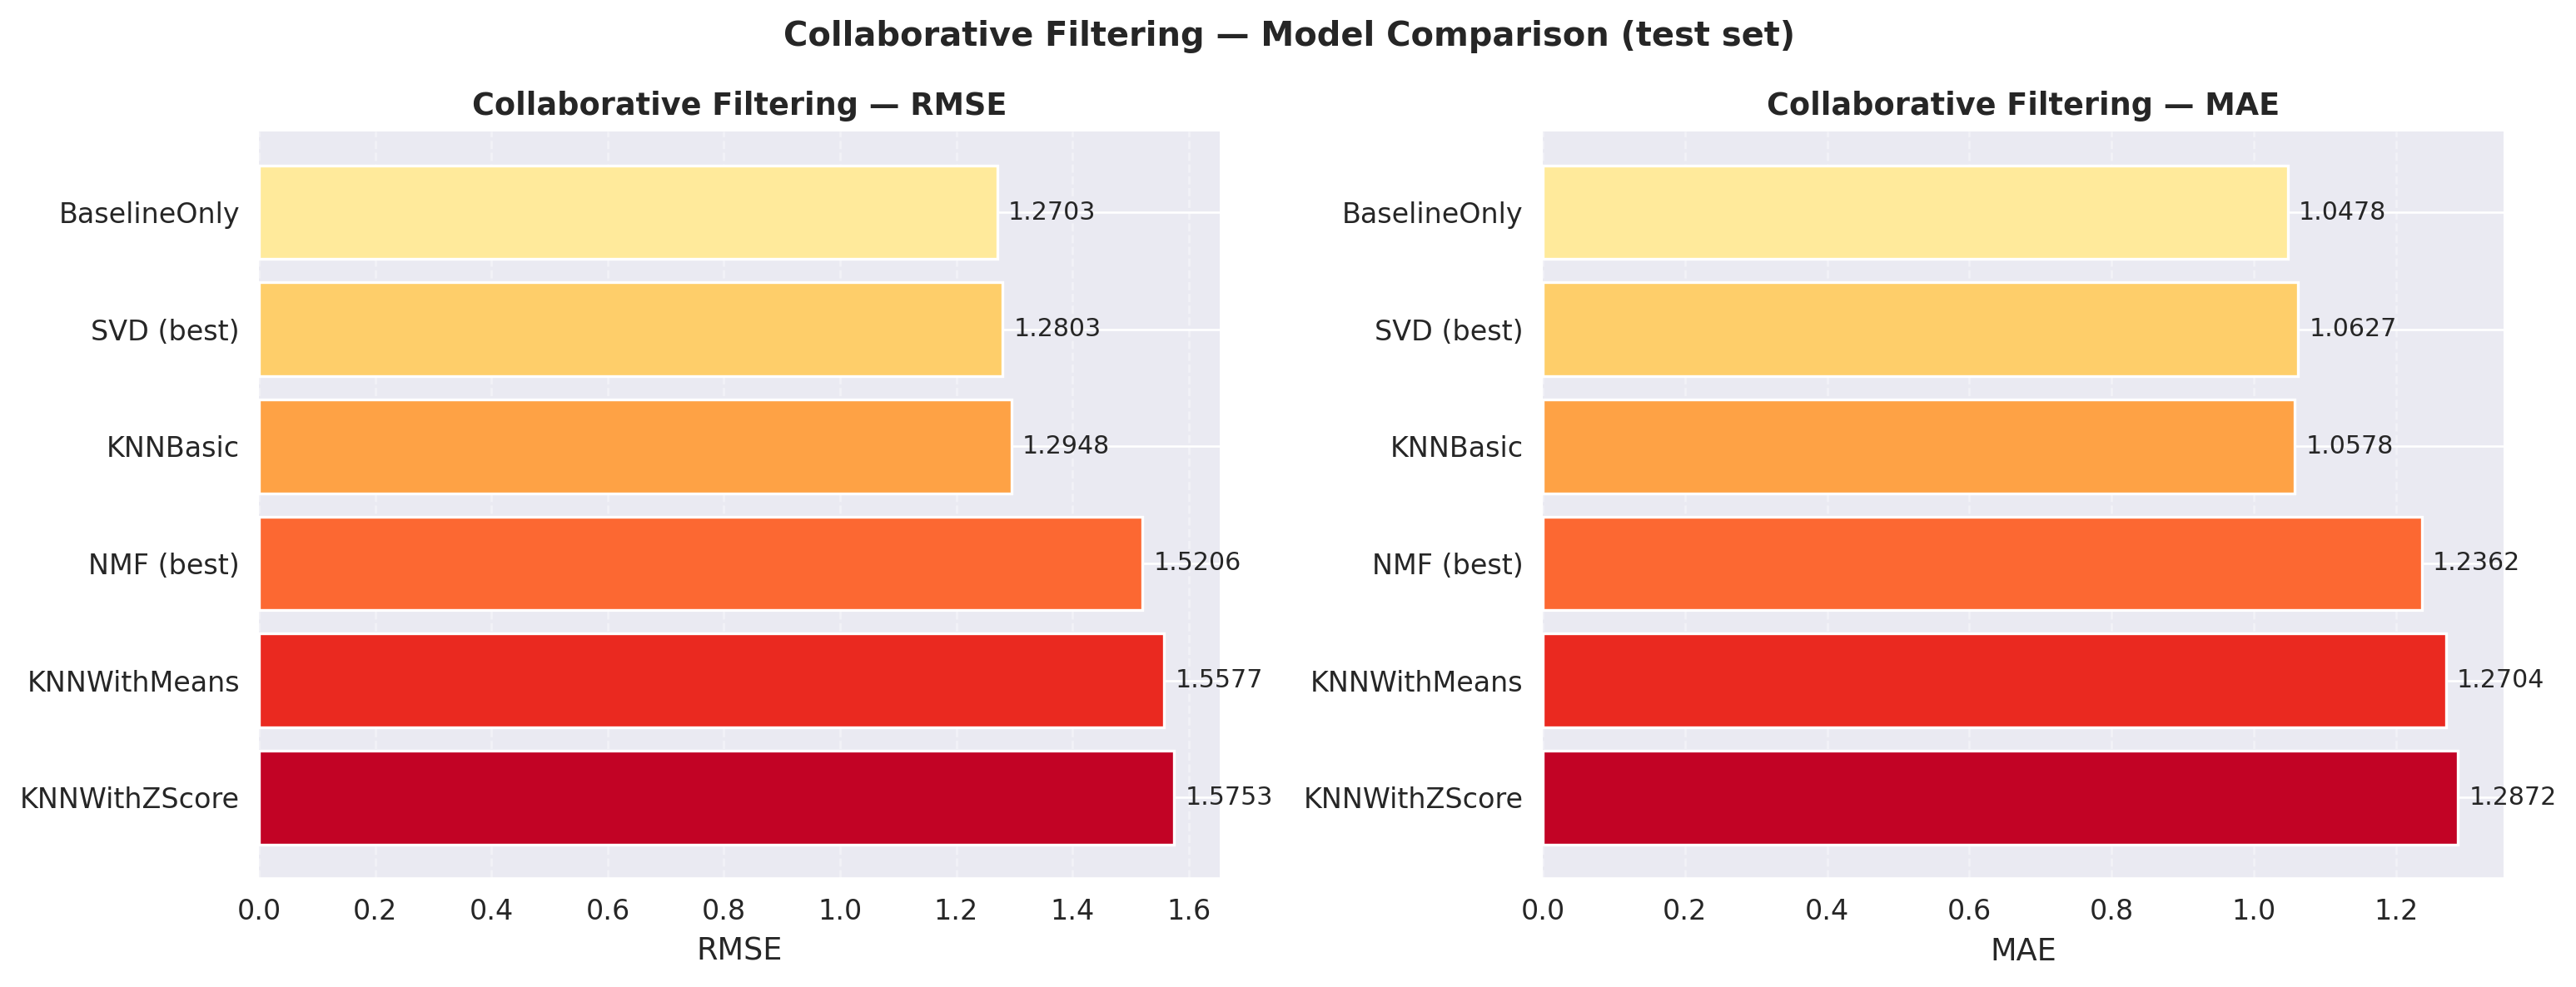

In [ ]:
# Collaborative filtering final bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=120)
palette = sns.color_palette('YlOrRd', len(results_cf_df))

for ax, metric in zip(axes, ['RMSE', 'MAE']):
    bars = ax.barh(results_cf_df['Model'], results_cf_df[metric], color=palette)
    ax.set_xlabel(metric, fontsize=11)
    ax.set_title(f'Collaborative Filtering — {metric}', fontweight='bold', fontsize=11)
    ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=9)
    ax.invert_yaxis()
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    sns.despine(left=True, ax=ax)

plt.suptitle('Collaborative Filtering — Model Comparison (test set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cf_rmse_bar.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Final winner summary across all tasks
best_clf_row  = results_df.loc[results_df['F1-macro'].idxmax()]
best_cb_name  = max(cb_results, key=cb_results.get)
best_cb_score = cb_results[best_cb_name]
best_cf_row   = results_cf_df.iloc[0]

print("\n" + "═" * 60)
print("   FINAL WINNERS — ALL TASKS")
print("═" * 60)

print(f"\n  Task 1 — Vectorization properties")
print(f"    Highest dimensionality : BoW / TF-IDF ({X_tfidf_sparse.shape[1]:,} dims, sparse)")
print(f"    Most compact           : LDA Topics ({X_topics.shape[1]} dims, dense)")
print(f"    Best BERT sep. gap     : {bert_sep:.4f} (intra={bert_intra} vs inter={bert_inter})")
print(f"    Word2Vec token coverage: {w2v_coverage*100:.1f}% of corpus tokens")
print(f"    LDA Cv coherence (k=10): {lda_coherence}")

print(f"\n  Task 2.1 — Sentiment Classification")
print(f"    Best vectorization     : {best_clf_row['Vectorization']}")
print(f"    Best classifier        : {best_clf_row['Classifier']}")
print(f"    F1-macro               : {best_clf_row['F1-macro']:.4f}")
print(f"    ROC-AUC                : {best_clf_row['ROC-AUC']:.4f}")

print(f"\n  Task 2.3 — Content-Based Recommender")
print(f"    Best vectorization     : {best_cb_name}")
print(f"    Hit-Rate@5             : {best_cb_score:.4f}")

print(f"\n  Task 2.3 — Collaborative Filtering")
print(f"    Best model             : {best_cf_row['Model']}")
print(f"    RMSE                   : {best_cf_row['RMSE']:.4f}")
print(f"    MAE                    : {best_cf_row['MAE']:.4f}")



════════════════════════════════════════════════════════════
   FINAL WINNERS — ALL TASKS
════════════════════════════════════════════════════════════

  Task 1 — Vectorization properties
    Highest dimensionality : BoW / TF-IDF (4,376 dims, sparse)
    Most compact           : LDA Topics (10 dims, dense)
    Best BERT sep. gap     : 0.0467 (intra=0.2844 vs inter=0.2377)
    Word2Vec token coverage: 93.2% of corpus tokens
    LDA Cv coherence (k=10): 0.5966

  Task 2.1 — Sentiment Classification
    Best vectorization     : BERT
    Best classifier        : Linear SVM
    F1-macro               : 0.7642
    ROC-AUC                : 0.9167

  Task 2.3 — Content-Based Recommender
    Best vectorization     : BERT
    Hit-Rate@5             : 0.3350

  Task 2.3 — Collaborative Filtering
    Best model             : BaselineOnly
    RMSE                   : 1.2703
    MAE                    : 1.0478
